# 12 — SDXL Bounded Partial Evaluation

**Origin:** Existing Previous Version of Notebook 25, rebuilt from scratch  
**Refactor status:** Finished         
**Validation status:** Finished           
**Completion gate passed:** Yes  
**Output root:** `outputs/12_sdxl_feasibility_or_restoration/`  
**Depends on:** Notebooks 01, 08, 09, 10, and 11

## Purpose

Produce a technically validated, reusable, and explicitly partial SDXL restoration branch under strict runtime and hardware guardrails.

The predeclared design contains:

- ten cases nested within five paintings;
- four canonical missing-region cases;
- six synthetic-degradation cases;
- one generic prompt and seed 2026;
- 768 × 768 inference with 30 denoising steps;
- one isolated persistent worker that loads the pinned SDXL pipeline once;
- a 7,200-second global budget;
- a 900-second per-case watchdog;
- no automatic retries, CPU fallback, reduced resolution, or reduced step count;
- immediate persistence and checkpointing of every completed restoration.

Only technically validated completed candidates may enter downstream metric computation. Timeout, CUDA out-of-memory, model unavailability, and budget omissions are runtime or infrastructure evidence—not restoration-quality failures.

The painting is the independent unit (`n=5`). The two cases per painting are nested observations and must not be interpreted as ten independent paintings.

In [1]:
from pathlib import Path
import json
import platform
import sys

import accelerate
import diffusers
import matplotlib
import numpy as np
import pandas as pd
import PIL
import safetensors
import torch
import transformers
import yaml
from IPython.display import display
from PIL import Image


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    resolve_repo_path,
    to_repo_relative,
)

from restoration_eval.restoration_sdxl import (
    SDXL_CONFIG_SCHEMA_VERSION,
    SDXL_HELPER_NAME,
    SDXL_HELPER_VERSION,
    configuration_fingerprint,
    load_sdxl_config,
)

from restoration_eval.schemas import (
    CASE_REGISTRY_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    SDXL_PARTIAL_CANDIDATES_SCHEMA,
    get_schema,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook identity and owned output directories
# ---------------------------------------------------------------------------

NOTEBOOK_STEM = "12_sdxl_feasibility_or_restoration"
SUPPORTED_PYTHON_MINORS = {(3, 11), (3, 12)}
RUN_STARTED_AT_UTC = utc_now_iso()

NOTEBOOK_OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "data",
        "images",
        "metrics",
        "reports",
        "manifests",
        "validation",
        "work",
    ),
    PROJECT_ROOT,
)

print("Notebook 12 repository bootstrap complete.")
print("Project root:", PROJECT_ROOT)
print("Notebook output root:", NOTEBOOK_OUTPUT_ROOT)
print("Helper version:", SDXL_HELPER_VERSION)
print("Run started at UTC:", RUN_STARTED_AT_UTC)

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Notebook 12 repository bootstrap complete.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\12_sdxl_feasibility_or_restoration
Helper version: 3.0.0
Run started at UTC: 2026-08-26T20:50:30.233981Z


In [2]:
# ---------------------------------------------------------------------------
# Approved configuration and governing paths
# ---------------------------------------------------------------------------

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiments"
    / "sdxl.yaml"
)

HELPER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "restoration_sdxl.py"
)

WORKER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "restoration_sdxl_worker.py"
)

SCHEMAS_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "schemas.py"
)

CONTRACT_DOCUMENT_PATH = (
    PROJECT_ROOT
    / "docs"
    / "notebook_12_partial_evaluation_contract.md"
)

NOTEBOOK_ROADMAP_PATH = (
    PROJECT_ROOT
    / "docs"
    / "final_notebook_roadmap.md"
)

IMPLEMENTATION_GUIDELINES_PATH = (
    PROJECT_ROOT
    / "docs"
    / "refactoring_implementation_guidelines.md"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "12_sdxl_feasibility_or_restoration.ipynb"
)


# ---------------------------------------------------------------------------
# Frozen SDXL v2 configuration
# ---------------------------------------------------------------------------

sdxl_config = load_sdxl_config(CONFIG_PATH)

if sdxl_config["output"]["notebook_stem"] != NOTEBOOK_STEM:
    raise ValueError(
        "Configured Notebook 12 stem disagrees with the notebook identity."
    )

CONFIGURATION_FINGERPRINT = configuration_fingerprint(
    sdxl_config
)


# ---------------------------------------------------------------------------
# Normalized input paths
# ---------------------------------------------------------------------------

configured_inputs = sdxl_config["inputs"]

INPUTS = {
    "project_inventory": resolve_repo_path(
        configured_inputs["inventory_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "inventory_run": resolve_repo_path(
        configured_inputs["inventory_run_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "project_paths_registry": resolve_repo_path(
        configured_inputs["project_paths_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "artworks": resolve_repo_path(
        configured_inputs["artworks_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "case_registry": resolve_repo_path(
        configured_inputs["case_registry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "model_eligibility": resolve_repo_path(
        configured_inputs["model_eligibility_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "schema_registry": resolve_repo_path(
        configured_inputs["schema_registry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "upstream_run_manifest": resolve_repo_path(
        configured_inputs["upstream_run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "upstream_artifacts": resolve_repo_path(
        configured_inputs["upstream_artifacts_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "evaluation_contract_config": resolve_repo_path(
        configured_inputs["evaluation_contract_config_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "stable_diffusion_config": resolve_repo_path(
        configured_inputs["stable_diffusion_config_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "synthetic_degradation_config": resolve_repo_path(
        configured_inputs["synthetic_degradation_config_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "telea_restorations": resolve_repo_path(
        configured_inputs["telea_restorations_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "telea_run_manifest": resolve_repo_path(
        configured_inputs["telea_run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "lama_restorations": resolve_repo_path(
        configured_inputs["lama_restorations_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "lama_run_manifest": resolve_repo_path(
        configured_inputs["lama_run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "stable_diffusion_candidates": resolve_repo_path(
        configured_inputs["stable_diffusion_candidates_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "stable_diffusion_run_manifest": resolve_repo_path(
        configured_inputs["stable_diffusion_run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
}


# ---------------------------------------------------------------------------
# Canonical output paths
# ---------------------------------------------------------------------------

OUTPUTS = {
    "candidates": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["candidates_path"]
    ),
    "restored_directory": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["restored_directory"]
    ),
    "runtime_summary": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["runtime_summary_path"]
    ),
    "partial_evaluation_report": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["partial_evaluation_report_path"]
    ),
    "run_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["run_manifest_path"]
    ),
    "artifacts": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["artifacts_path"]
    ),
    "validation": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["validation_path"]
    ),
}

WORK_PATHS = {
    "work_directory": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["work_directory"]
    ),
    "checkpoint": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["checkpoint_path"]
    ),
    "progress": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["progress_path"]
    ),
    "worker_job": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["worker_job_path"]
    ),
    "worker_result": (
        NOTEBOOK_OUTPUT_ROOT
        / sdxl_config["output"]["worker_result_path"]
    ),
}


# ---------------------------------------------------------------------------
# Load global discovery contracts
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    INPUTS["project_inventory"],
    low_memory=False,
)

with INPUTS["inventory_run"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    inventory_run = json.load(handle)

project_paths_registry = load_project_paths_registry(
    PROJECT_ROOT
)

registry_artifacts = {
    record["artifact_key"]: record
    for record in project_paths_registry["artifacts"]
}

upstream_manifest_paths = {
    "notebook_08": INPUTS["upstream_run_manifest"],
    "notebook_09": INPUTS["telea_run_manifest"],
    "notebook_10": INPUTS["lama_run_manifest"],
    "notebook_11": INPUTS["stable_diffusion_run_manifest"],
}

upstream_manifests = {}

for producer, manifest_path in upstream_manifest_paths.items():
    with manifest_path.open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        upstream_manifests[producer] = json.load(handle)

print("Notebook 12 configuration and path contracts loaded.")
print("Configuration schema:", sdxl_config["config_schema_version"])
print("Configuration fingerprint:", CONFIGURATION_FINGERPRINT)
print("Inventory rows:", len(inventory_df))
print("Registered artifacts:", len(registry_artifacts))
print("Declared input files:", len(INPUTS))

Notebook 12 configuration and path contracts loaded.
Configuration schema: sdxl_config.v2
Configuration fingerprint: 5f4939e6116e9f687e23887eb44fc3d8f3e05f60ebd072d3f2c81e576859e16a
Inventory rows: 11457
Registered artifacts: 70
Declared input files: 18


In [3]:
# ---------------------------------------------------------------------------
# Normalized input contract
# ---------------------------------------------------------------------------

def input_contract_record(
    input_key,
    producer,
    path,
    file_format,
    schema_version,
    required_columns_or_keys,
    expected_cardinality,
    applicability,
):
    return {
        "input_key": input_key,
        "producer": producer,
        "relative_path": to_repo_relative(
            path,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": file_format,
        "schema_version": schema_version,
        "required_columns_or_keys": required_columns_or_keys,
        "expected_cardinality": expected_cardinality,
        "applicability": applicability,
    }


input_contract_records = [
    input_contract_record(
        "project_inventory",
        "tools/build_project_inventory.py",
        INPUTS["project_inventory"],
        "csv",
        "project_file_inventory.v1",
        (
            "inventory_schema_version, inventory_run_id, "
            "relative_path, file_kind, size_bytes, hash_value"
        ),
        len(inventory_df),
        "repository discovery",
    ),
    input_contract_record(
        "inventory_run",
        "tools/build_project_inventory.py",
        INPUTS["inventory_run"],
        "json",
        "inventory_run.v1",
        (
            "inventory_run_id, status, inventory_sha256, "
            "summary, incremental_reuse"
        ),
        1,
        "repository discovery",
    ),
    input_contract_record(
        "project_paths_registry",
        "validated notebook handoffs",
        INPUTS["project_paths_registry"],
        "json",
        "project_paths.v1",
        "registry_schema_version, artifacts",
        len(project_paths_registry["artifacts"]),
        "artifact discovery",
    ),
    input_contract_record(
        "artworks",
        "Notebook 01",
        INPUTS["artworks"],
        "csv",
        "artworks.v1",
        ", ".join(CASE_REGISTRY_SCHEMA.required_columns[:0])
        or "painting_id, category, dataset_scope, acceptance_status",
        50,
        "painting metadata",
    ),
    input_contract_record(
        "case_registry",
        "Notebook 08",
        INPUTS["case_registry"],
        "csv",
        CASE_REGISTRY_SCHEMA.version,
        ", ".join(CASE_REGISTRY_SCHEMA.required_columns),
        525,
        "eligible restoration cases",
    ),
    input_contract_record(
        "model_eligibility",
        "Notebook 08",
        INPUTS["model_eligibility"],
        "csv",
        MODEL_ELIGIBILITY_SCHEMA.version,
        ", ".join(MODEL_ELIGIBILITY_SCHEMA.required_columns),
        2100,
        "SDXL eligibility",
    ),
    input_contract_record(
        "schema_registry",
        "Notebook 08",
        INPUTS["schema_registry"],
        "json",
        "schema_registry.v1",
        "registry_schema_version, schemas",
        1,
        "schema discovery",
    ),
    input_contract_record(
        "upstream_run_manifest",
        "Notebook 08",
        INPUTS["upstream_run_manifest"],
        "json",
        "run_manifest.v1",
        (
            "manifest_schema_version, run_status, "
            "completion_gate_passed, validation_status"
        ),
        1,
        "experiment contracts",
    ),
    input_contract_record(
        "upstream_artifacts",
        "Notebook 08",
        INPUTS["upstream_artifacts"],
        "csv",
        "artifact_manifest.v1",
        (
            "artifact_key, relative_path, artifact_type, "
            "schema_version, validation_status"
        ),
        "one or more",
        "experiment contracts",
    ),
    input_contract_record(
        "evaluation_contract_config",
        "Repository configuration",
        INPUTS["evaluation_contract_config"],
        "yaml",
        "evaluation_contract_config.v1",
        "dataset, experiments, region policies",
        1,
        "methodological contract",
    ),
    input_contract_record(
        "stable_diffusion_config",
        "Repository configuration",
        INPUTS["stable_diffusion_config"],
        "yaml",
        "stable_diffusion_config.v1",
        "model, prompt policy, execution policy",
        1,
        "cross-model comparability",
    ),
    input_contract_record(
        "synthetic_degradation_config",
        "Repository configuration",
        INPUTS["synthetic_degradation_config"],
        "yaml",
        "synthetic_degradation_config.v1",
        "generator, active threshold, degradation families",
        1,
        "synthetic mask semantics",
    ),
    input_contract_record(
        "telea_restorations",
        "Notebook 09",
        INPUTS["telea_restorations"],
        "csv",
        "restorations.v1",
        (
            "case_id, candidate_id, restored_path, "
            "runtime_seconds, status"
        ),
        410,
        "matched-case comparability",
    ),
    input_contract_record(
        "telea_run_manifest",
        "Notebook 09",
        INPUTS["telea_run_manifest"],
        "json",
        "run_manifest.v1",
        (
            "manifest_schema_version, run_status, "
            "completion_gate_passed, validation_status"
        ),
        1,
        "matched-case comparability",
    ),
    input_contract_record(
        "lama_restorations",
        "Notebook 10",
        INPUTS["lama_restorations"],
        "csv",
        "restorations.v1",
        (
            "case_id, candidate_id, restored_path, "
            "runtime_seconds, status"
        ),
        410,
        "matched-case comparability",
    ),
    input_contract_record(
        "lama_run_manifest",
        "Notebook 10",
        INPUTS["lama_run_manifest"],
        "json",
        "run_manifest.v1",
        (
            "manifest_schema_version, run_status, "
            "completion_gate_passed, validation_status"
        ),
        1,
        "matched-case comparability",
    ),
    input_contract_record(
        "stable_diffusion_candidates",
        "Notebook 11",
        INPUTS["stable_diffusion_candidates"],
        "csv",
        "stable_diffusion_candidates.v1",
        (
            "candidate_id, case_id, prompt_variant_id, "
            "seed, restored_path, status"
        ),
        1330,
        "matched primary-candidate comparability",
    ),
    input_contract_record(
        "stable_diffusion_run_manifest",
        "Notebook 11",
        INPUTS["stable_diffusion_run_manifest"],
        "json",
        "run_manifest.v1",
        (
            "manifest_schema_version, run_status, "
            "completion_gate_passed, validation_status"
        ),
        1,
        "matched primary-candidate comparability",
    ),
]

input_contract_df = pd.DataFrame(
    input_contract_records
)

display(input_contract_df)

print("Normalized Notebook 12 input contract constructed.")
print("Input contract rows:", len(input_contract_df))

,input_key,producer,relative_path,required,format,schema_version,required_columns_or_keys,expected_cardinality,applicability
0,project_inventory,tools/build_project_inventory.py,outputs/inventory/project_file_inventory.csv,True,csv,project_file_inventory.v1,"inventory_schema_version, inventory_run_id, re...",11457,repository discovery
1,inventory_run,tools/build_project_inventory.py,outputs/inventory/inventory_run.json,True,json,inventory_run.v1,"inventory_run_id, status, inventory_sha256, su...",1,repository discovery
2,project_paths_registry,validated notebook handoffs,outputs/inventory/project_paths.json,True,json,project_paths.v1,"registry_schema_version, artifacts",70,artifact discovery
3,artworks,Notebook 01,outputs/01_dataset_verification/data/artworks.csv,True,csv,artworks.v1,"painting_id, category, dataset_scope, acceptan...",50,painting metadata
4,case_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,csv,case_registry.v1,"case_id, dataset_id, dataset_scope, experiment...",525,eligible restoration cases
5,model_eligibility,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,csv,model_eligibility.v1,"case_id, model_id, eligible, eligibility_reaso...",2100,SDXL eligibility
6,schema_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,json,schema_registry.v1,"registry_schema_version, schemas",1,schema discovery
7,upstream_run_manifest,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,json,run_manifest.v1,"manifest_schema_version, run_status, completio...",1,experiment contracts
8,upstream_artifacts,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,csv,artifact_manifest.v1,"artifact_key, relative_path, artifact_type, sc...",one or more,experiment contracts
9,evaluation_contract_config,Repository configuration,config/experiments/evaluation_contract.yaml,True,yaml,evaluation_contract_config.v1,"dataset, experiments, region policies",1,methodological contract


Normalized Notebook 12 input contract constructed.
Input contract rows: 18


In [4]:
# ---------------------------------------------------------------------------
# Dependency and fixed-policy summaries
# ---------------------------------------------------------------------------

DEPENDENCY_VERSIONS = {
    "python": platform.python_version(),
    "torch": str(torch.__version__),
    "cuda_runtime": str(torch.version.cuda or ""),
    "diffusers": str(diffusers.__version__),
    "transformers": str(transformers.__version__),
    "accelerate": str(accelerate.__version__),
    "safetensors": str(safetensors.__version__),
    "numpy": str(np.__version__),
    "pandas": str(pd.__version__),
    "matplotlib": str(matplotlib.__version__),
    "pillow": str(PIL.__version__),
    "pyyaml": str(yaml.__version__),
}

dependency_preflight_df = pd.DataFrame(
    [
        {
            "dependency": "Python",
            "observed_version": DEPENDENCY_VERSIONS["python"],
            "required_version": "3.11 or 3.12",
            "passed": sys.version_info[:2] in SUPPORTED_PYTHON_MINORS,
            "severity": "blocking",
        },
        {
            "dependency": "torch",
            "observed_version": DEPENDENCY_VERSIONS["torch"],
            "required_version": "2.5.1+cu121",
            "passed": DEPENDENCY_VERSIONS["torch"] == "2.5.1+cu121",
            "severity": "blocking",
        },
        {
            "dependency": "CUDA runtime",
            "observed_version": DEPENDENCY_VERSIONS["cuda_runtime"],
            "required_version": "12.1 for the pinned torch build",
            "passed": DEPENDENCY_VERSIONS["cuda_runtime"] == "12.1",
            "severity": "blocking",
        },
        {
            "dependency": "CUDA device",
            "observed_version": (
                torch.cuda.get_device_name(0)
                if torch.cuda.is_available()
                else "unavailable"
            ),
            "required_version": "CUDA-capable device",
            "passed": torch.cuda.is_available(),
            "severity": "warning",
        },
        {
            "dependency": "diffusers",
            "observed_version": DEPENDENCY_VERSIONS["diffusers"],
            "required_version": "0.27.2",
            "passed": DEPENDENCY_VERSIONS["diffusers"] == "0.27.2",
            "severity": "blocking",
        },
        {
            "dependency": "transformers",
            "observed_version": DEPENDENCY_VERSIONS["transformers"],
            "required_version": "installed and importable",
            "passed": bool(DEPENDENCY_VERSIONS["transformers"]),
            "severity": "blocking",
        },
        {
            "dependency": "accelerate",
            "observed_version": DEPENDENCY_VERSIONS["accelerate"],
            "required_version": "installed and importable",
            "passed": bool(DEPENDENCY_VERSIONS["accelerate"]),
            "severity": "blocking",
        },
        {
            "dependency": "safetensors",
            "observed_version": DEPENDENCY_VERSIONS["safetensors"],
            "required_version": "installed and importable",
            "passed": bool(DEPENDENCY_VERSIONS["safetensors"]),
            "severity": "blocking",
        },
    ]
)

model = sdxl_config["model"]
execution = sdxl_config["execution"]
selection = sdxl_config["selection"]
memory = sdxl_config["memory_strategy"]

fixed_policy_df = pd.DataFrame(
    [
        {
            "policy": "Execution mode",
            "value": execution["mode"],
        },
        {
            "policy": "Scheduled cases",
            "value": selection["scheduled_case_count"],
        },
        {
            "policy": "Independent paintings",
            "value": selection["painting_count"],
        },
        {
            "policy": "Canonical / synthetic cases",
            "value": (
                f"{selection['canonical_case_count']} / "
                f"{selection['synthetic_case_count']}"
            ),
        },
        {
            "policy": "Model revision",
            "value": model["model_revision"],
        },
        {
            "policy": "Inference geometry",
            "value": (
                f"{model['inference_width']} × "
                f"{model['inference_height']}"
            ),
        },
        {
            "policy": "Denoising steps",
            "value": model["num_inference_steps"],
        },
        {
            "policy": "Seed",
            "value": model["seed"],
        },
        {
            "policy": "Global budget seconds",
            "value": execution["global_budget_seconds"],
        },
        {
            "policy": "Per-case timeout seconds",
            "value": execution["per_case_timeout_seconds"],
        },
        {
            "policy": "Minimum seconds to start case",
            "value": execution["minimum_seconds_to_start_case"],
        },
        {
            "policy": "Persistent pipeline",
            "value": memory["persistent_pipeline"],
        },
        {
            "policy": "Automatic retries",
            "value": execution["retry_failed_attempts"],
        },
        {
            "policy": "CPU fallback",
            "value": model["allow_cpu_fallback"],
        },
    ]
)

display(dependency_preflight_df)
display(fixed_policy_df)

print("Dependency and frozen-policy summaries constructed.")
print("CUDA available:", torch.cuda.is_available())

,dependency,observed_version,required_version,passed,severity
0,Python,3.12.6,3.11 or 3.12,True,blocking
1,torch,2.5.1+cu121,2.5.1+cu121,True,blocking
2,CUDA runtime,12.1,12.1 for the pinned torch build,True,blocking
3,CUDA device,NVIDIA GeForce RTX 3060 Laptop GPU,CUDA-capable device,True,warning
4,diffusers,0.27.2,0.27.2,True,blocking
5,transformers,4.48.3,installed and importable,True,blocking
6,accelerate,1.14.0,installed and importable,True,blocking
7,safetensors,0.8.0,installed and importable,True,blocking


,policy,value
0,Execution mode,partial_evaluation
1,Scheduled cases,10
2,Independent paintings,5
3,Canonical / synthetic cases,4 / 6
4,Model revision,115134f363124c53c7d878647567d04daf26e41e
5,Inference geometry,768 × 768
6,Denoising steps,30
7,Seed,2026
8,Global budget seconds,7200
9,Per-case timeout seconds,900


Dependency and frozen-policy summaries constructed.
CUDA available: True


In [5]:
# ---------------------------------------------------------------------------
# Batch 1 validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


def add_batch_1_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Environment checks
# ---------------------------------------------------------------------------

for dependency_row in dependency_preflight_df.itertuples(
    index=False
):
    add_batch_1_check(
        check_id=(
            "dependency_"
            + str(dependency_row.dependency)
            .lower()
            .replace(" ", "_")
        ),
        description=(
            f"{dependency_row.dependency} satisfies the "
            "approved Notebook 12 environment."
        ),
        expected=dependency_row.required_version,
        observed=dependency_row.observed_version,
        passed=dependency_row.passed,
        severity=dependency_row.severity,
    )


# ---------------------------------------------------------------------------
# Helper, schema, configuration, and notebook identity
# ---------------------------------------------------------------------------

add_batch_1_check(
    "helper_version",
    "The SDXL helper uses the approved partial-evaluation version.",
    "3.0.0",
    SDXL_HELPER_VERSION,
    SDXL_HELPER_VERSION == "3.0.0",
)

add_batch_1_check(
    "config_schema_version",
    "The SDXL configuration uses the approved v2 schema.",
    "sdxl_config.v2",
    sdxl_config["config_schema_version"],
    (
        sdxl_config["config_schema_version"]
        == SDXL_CONFIG_SCHEMA_VERSION
        == "sdxl_config.v2"
    ),
)

add_batch_1_check(
    "candidate_schema_registered",
    "The normalized SDXL partial-candidate schema is registered.",
    SDXL_PARTIAL_CANDIDATES_SCHEMA.version,
    get_schema("sdxl_partial_candidates").version,
    (
        get_schema("sdxl_partial_candidates")
        is SDXL_PARTIAL_CANDIDATES_SCHEMA
    ),
)

add_batch_1_check(
    "notebook_stem",
    "The configured notebook stem matches Notebook 12.",
    NOTEBOOK_STEM,
    sdxl_config["output"]["notebook_stem"],
    sdxl_config["output"]["notebook_stem"] == NOTEBOOK_STEM,
)

add_batch_1_check(
    "notebook_exists",
    "The manually created Notebook 12 file exists.",
    True,
    NOTEBOOK_PATH.is_file(),
    NOTEBOOK_PATH.is_file(),
)

add_batch_1_check(
    "output_root_owned",
    "The output root is owned exclusively by Notebook 12.",
    f"outputs/{NOTEBOOK_STEM}",
    to_repo_relative(NOTEBOOK_OUTPUT_ROOT, PROJECT_ROOT),
    (
        to_repo_relative(
            NOTEBOOK_OUTPUT_ROOT,
            PROJECT_ROOT,
        )
        == f"outputs/{NOTEBOOK_STEM}"
    ),
)

for label, path in {
    "config": CONFIG_PATH,
    "helper": HELPER_PATH,
    "worker": WORKER_PATH,
    "schemas": SCHEMAS_PATH,
    "contract_document": CONTRACT_DOCUMENT_PATH,
    "notebook_roadmap": NOTEBOOK_ROADMAP_PATH,
    "implementation_guidelines": IMPLEMENTATION_GUIDELINES_PATH,
}.items():
    add_batch_1_check(
        f"governing_file_exists_{label}",
        f"The governing {label} file exists.",
        True,
        path.is_file(),
        path.is_file(),
    )


# ---------------------------------------------------------------------------
# Declared input existence and inventory coverage
# ---------------------------------------------------------------------------

inventory_relative_paths = set(
    inventory_df["relative_path"]
    .dropna()
    .astype(str)
)

inventory_excluded_inputs = {
    "project_inventory",
    "inventory_run",
}

for input_key, input_path in INPUTS.items():
    add_batch_1_check(
        f"input_exists_{input_key}",
        f"Declared input {input_key!r} exists.",
        True,
        input_path.is_file(),
        input_path.is_file(),
    )

    if input_key not in inventory_excluded_inputs:
        relative_path = to_repo_relative(
            input_path,
            PROJECT_ROOT,
        )
        add_batch_1_check(
            f"inventory_covers_{input_key}",
            (
                f"The refreshed inventory contains declared "
                f"input {input_key!r}."
            ),
            True,
            relative_path in inventory_relative_paths,
            relative_path in inventory_relative_paths,
            details=relative_path,
        )


# ---------------------------------------------------------------------------
# Inventory integrity
# ---------------------------------------------------------------------------

add_batch_1_check(
    "inventory_status",
    "The refreshed inventory run completed successfully.",
    "completed",
    inventory_run.get("status"),
    inventory_run.get("status") == "completed",
)

add_batch_1_check(
    "inventory_schema",
    "The inventory uses the approved schema version.",
    "project_file_inventory.v1",
    inventory_run.get("inventory_schema_version"),
    (
        inventory_run.get("inventory_schema_version")
        == "project_file_inventory.v1"
    ),
)

inventory_read_errors = int(
    inventory_run
    .get("summary", {})
    .get("read_error_count", -1)
)

add_batch_1_check(
    "inventory_read_errors",
    "The refreshed inventory has no file-read errors.",
    0,
    inventory_read_errors,
    inventory_read_errors == 0,
)

observed_inventory_sha256 = sha256_file(
    INPUTS["project_inventory"]
)

add_batch_1_check(
    "inventory_checksum",
    "The inventory file matches its run-manifest checksum.",
    inventory_run.get("inventory_sha256"),
    observed_inventory_sha256,
    (
        observed_inventory_sha256
        == inventory_run.get("inventory_sha256")
    ),
)


# ---------------------------------------------------------------------------
# Project-path registry and upstream manifest checks
# ---------------------------------------------------------------------------

required_registry_keys = set(
    configured_inputs["required_registry_keys"]
)

observed_registry_keys = set(
    registry_artifacts
)

missing_registry_keys = sorted(
    required_registry_keys
    - observed_registry_keys
)

add_batch_1_check(
    "required_registry_keys",
    "All required normalized upstream artifacts are registered.",
    sorted(required_registry_keys),
    sorted(required_registry_keys & observed_registry_keys),
    not missing_registry_keys,
    details={
        "missing_registry_keys": missing_registry_keys,
    },
)

registry_expected_paths = {
    "dataset.artworks": INPUTS["artworks"],
    "experiment_contracts.case_registry": INPUTS["case_registry"],
    "experiment_contracts.model_eligibility": INPUTS["model_eligibility"],
    "experiment_contracts.schema_registry": INPUTS["schema_registry"],
    "opencv_telea.restorations": INPUTS["telea_restorations"],
    "lama.restorations": INPUTS["lama_restorations"],
    "stable_diffusion.candidates": INPUTS[
        "stable_diffusion_candidates"
    ],
}

for artifact_key, expected_path in registry_expected_paths.items():
    registered_record = registry_artifacts.get(
        artifact_key,
        {},
    )

    expected_relative_path = to_repo_relative(
        expected_path,
        PROJECT_ROOT,
    )

    observed_relative_path = registered_record.get(
        "relative_path",
        "",
    )

    add_batch_1_check(
        (
            "registry_path_"
            + artifact_key
            .replace(".", "_")
        ),
        (
            f"Registry artifact {artifact_key!r} points to "
            "the configured normalized input."
        ),
        expected_relative_path,
        observed_relative_path,
        observed_relative_path == expected_relative_path,
    )

required_upstream_status = configured_inputs[
    "required_upstream_run_status"
]

for producer, manifest in upstream_manifests.items():
    add_batch_1_check(
        f"upstream_status_{producer}",
        f"{producer} reports a completed run.",
        required_upstream_status,
        manifest.get("run_status"),
        (
            manifest.get("run_status")
            == required_upstream_status
        ),
    )

    add_batch_1_check(
        f"upstream_gate_{producer}",
        f"{producer} passed its completion gate.",
        True,
        manifest.get("completion_gate_passed"),
        bool(manifest.get("completion_gate_passed")),
    )

    add_batch_1_check(
        f"upstream_validation_{producer}",
        f"{producer} reports passed validation.",
        "passed",
        manifest.get("validation_status"),
        manifest.get("validation_status") == "passed",
    )


# ---------------------------------------------------------------------------
# Frozen partial-evaluation policy checks
# ---------------------------------------------------------------------------

add_batch_1_check(
    "scheduled_case_count",
    "The approved partial scope contains exactly ten cases.",
    10,
    selection["scheduled_case_count"],
    selection["scheduled_case_count"] == 10,
)

add_batch_1_check(
    "painting_count",
    "The ten cases are nested within five paintings.",
    5,
    selection["painting_count"],
    selection["painting_count"] == 5,
)

add_batch_1_check(
    "global_budget",
    "The global SDXL budget is frozen at two hours.",
    7200,
    execution["global_budget_seconds"],
    execution["global_budget_seconds"] == 7200,
)

add_batch_1_check(
    "per_case_watchdog",
    "The per-case watchdog is frozen at 900 seconds.",
    900,
    execution["per_case_timeout_seconds"],
    execution["per_case_timeout_seconds"] == 900,
)

add_batch_1_check(
    "persistent_pipeline",
    "The isolated worker reuses one persistent pipeline.",
    True,
    memory["persistent_pipeline"],
    bool(memory["persistent_pipeline"]),
)

add_batch_1_check(
    "automatic_retries",
    "Automatic SDXL retries are prohibited.",
    False,
    execution["retry_failed_attempts"],
    not bool(execution["retry_failed_attempts"]),
)

add_batch_1_check(
    "full_execution_prohibited",
    "This contract does not authorize full SDXL execution.",
    False,
    sdxl_config["scope"]["full_execution_authorized"],
    not bool(
        sdxl_config["scope"]["full_execution_authorized"]
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce Batch 1 result
# ---------------------------------------------------------------------------

batch_1_validation_df = VALIDATION.to_dataframe()
batch_1_summary = VALIDATION.summary()

display(batch_1_validation_df)
display(pd.DataFrame([batch_1_summary]))

VALIDATION.raise_for_blocking()

print("Batch 1 preflight passed.")
print("Validation checks:", batch_1_summary["check_count"])
print(
    "Blocking failures:",
    batch_1_summary["blocking_failure_count"],
)
print(
    "Warning-only CUDA availability failures do not fabricate "
    "restoration-quality evidence."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,dependency_python,Python satisfies the approved Notebook 12 envi...,blocking,3.11 or 3.12,3.12.6,True,
1,batch_1_preflight,dependency_torch,torch satisfies the approved Notebook 12 envir...,blocking,2.5.1+cu121,2.5.1+cu121,True,
2,batch_1_preflight,dependency_cuda_runtime,CUDA runtime satisfies the approved Notebook 1...,blocking,12.1 for the pinned torch build,12.1,True,
3,batch_1_preflight,dependency_cuda_device,CUDA device satisfies the approved Notebook 12...,warning,CUDA-capable device,NVIDIA GeForce RTX 3060 Laptop GPU,True,
4,batch_1_preflight,dependency_diffusers,diffusers satisfies the approved Notebook 12 e...,blocking,0.27.2,0.27.2,True,
...,...,...,...,...,...,...,...,...
81,batch_1_preflight,global_budget,The global SDXL budget is frozen at two hours.,blocking,7200,7200,True,
82,batch_1_preflight,per_case_watchdog,The per-case watchdog is frozen at 900 seconds.,blocking,900,900,True,
83,batch_1_preflight,persistent_pipeline,The isolated worker reuses one persistent pipe...,blocking,True,True,True,
84,batch_1_preflight,automatic_retries,Automatic SDXL retries are prohibited.,blocking,False,False,True,


,check_count,passed_count,failed_count,blocking_failure_count,overall_passed,failed_check_ids
0,86,86,0,0,True,[]


Batch 1 preflight passed.
Validation checks: 86
Blocking failures: 0
Warning-only CUDA availability failures do not fabricate restoration-quality evidence.


## Batch 2 — Exact Scope, Cross-Method Comparability, and Candidate Plan

This batch:

- loads and validates the normalized Notebook 01 and Notebook 08 contracts;
- rebuilds the same 410-case SDXL-eligible worklist used by Notebook 11;
- selects the ten cases declared before restoration and without metric-based selection;
- preserves both the scientific selection rank and diversity-first execution order;
- verifies that every selected case has exactly one comparable completed OpenCV Telea, LaMa, and primary Stable Diffusion result;
- constructs the normalized ten-row SDXL candidate plan;
- assigns threshold 128 to canonical missing-region masks;
- assigns threshold 13 to synthetic degradation effect masks;
- validates painting nesting, case families, prompt policy, seed, output ownership, path lengths, and schema compliance.

The painting is the independent unit (`n=5`). The two selected cases per painting are nested observations.

This batch does not load SDXL, perform inference, calculate restoration metrics, or persist canonical Notebook 12 artifacts.

In [6]:
from restoration_eval.restoration_sdxl import (
    build_partial_candidate_plan,
    build_sdxl_eligible_worklist,
    select_partial_evaluation_scope,
    validate_cross_method_comparability,
)

from restoration_eval.schemas import (
    ARTWORKS_SCHEMA,
    RESTORATIONS_SCHEMA,
    STABLE_DIFFUSION_CANDIDATES_SCHEMA,
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Load normalized upstream tables
# ---------------------------------------------------------------------------

artworks_df = pd.read_csv(
    INPUTS["artworks"]
)

case_registry_df = pd.read_csv(
    INPUTS["case_registry"]
)

model_eligibility_df = pd.read_csv(
    INPUTS["model_eligibility"]
)

telea_restorations_df = pd.read_csv(
    INPUTS["telea_restorations"]
)

lama_restorations_df = pd.read_csv(
    INPUTS["lama_restorations"]
)

stable_diffusion_candidates_df = pd.read_csv(
    INPUTS["stable_diffusion_candidates"]
)


# ---------------------------------------------------------------------------
# Validate upstream schemas
# ---------------------------------------------------------------------------

upstream_schema_results = {
    "artworks": validate_dataframe(
        artworks_df,
        ARTWORKS_SCHEMA,
        allow_extra_columns=True,
    ),
    "case_registry": validate_dataframe(
        case_registry_df,
        CASE_REGISTRY_SCHEMA,
        allow_extra_columns=True,
    ),
    "model_eligibility": validate_dataframe(
        model_eligibility_df,
        MODEL_ELIGIBILITY_SCHEMA,
        allow_extra_columns=True,
    ),
    "telea_restorations": validate_dataframe(
        telea_restorations_df,
        RESTORATIONS_SCHEMA,
        allow_extra_columns=True,
    ),
    "lama_restorations": validate_dataframe(
        lama_restorations_df,
        RESTORATIONS_SCHEMA,
        allow_extra_columns=True,
    ),
    "stable_diffusion_candidates": validate_dataframe(
        stable_diffusion_candidates_df,
        STABLE_DIFFUSION_CANDIDATES_SCHEMA,
        allow_extra_columns=True,
    ),
}

upstream_schema_validation_df = pd.DataFrame(
    [
        {
            "input_key": input_key,
            **result.to_dict(),
        }
        for input_key, result
        in upstream_schema_results.items()
    ]
)

display(
    upstream_schema_validation_df[
        [
            "input_key",
            "schema_name",
            "schema_version",
            "row_count",
            "column_count",
            "duplicate_primary_key_rows",
            "passed",
        ]
    ]
)


# ---------------------------------------------------------------------------
# Rebuild the normalized eligible-case worklist
# ---------------------------------------------------------------------------

sdxl_eligible_worklist_df = build_sdxl_eligible_worklist(
    case_registry_df,
    model_eligibility_df,
    artworks_df,
    sdxl_config,
)

print("Normalized Notebook 12 inputs loaded.")
print("Artwork rows:", len(artworks_df))
print("Case-registry rows:", len(case_registry_df))
print("Model-eligibility rows:", len(model_eligibility_df))
print("SDXL-eligible worklist rows:", len(sdxl_eligible_worklist_df))
print(
    "Eligible zero-control rows:",
    int(sdxl_eligible_worklist_df["is_zero_control"].sum()),
)

,input_key,schema_name,schema_version,row_count,column_count,duplicate_primary_key_rows,passed
0,artworks,artworks,artworks.v1,50,36,0,True
1,case_registry,case_registry,case_registry.v1,525,14,0,True
2,model_eligibility,model_eligibility,model_eligibility.v1,2100,7,0,True
3,telea_restorations,restorations,restorations.v1,410,30,0,True
4,lama_restorations,restorations,restorations.v1,410,40,0,True
5,stable_diffusion_candidates,stable_diffusion_candidates,stable_diffusion_candidates.v1,1330,57,0,True


Normalized Notebook 12 inputs loaded.
Artwork rows: 50
Case-registry rows: 525
Model-eligibility rows: 2100
SDXL-eligible worklist rows: 410
Eligible zero-control rows: 50


In [7]:
# ---------------------------------------------------------------------------
# Predeclared ten-case partial scope
# ---------------------------------------------------------------------------

selected_scope_df = select_partial_evaluation_scope(
    sdxl_eligible_worklist_df,
    sdxl_config,
)


# ---------------------------------------------------------------------------
# Exact completed-case coverage in existing restoration branches
# ---------------------------------------------------------------------------

cross_method_comparability_df = (
    validate_cross_method_comparability(
        selected_scope_df,
        telea_restorations_df,
        lama_restorations_df,
        stable_diffusion_candidates_df,
    )
)

cross_method_comparability_matrix_df = (
    cross_method_comparability_df.pivot(
        index="case_id",
        columns="method_id",
        values="matching_completed_rows",
    )
    .reset_index()
    .rename_axis(columns=None)
)


# ---------------------------------------------------------------------------
# Normalized SDXL candidate plan
# ---------------------------------------------------------------------------

sdxl_candidate_plan_df = build_partial_candidate_plan(
    selected_scope_df,
    sdxl_config,
)

candidate_plan_schema_result = validate_dataframe(
    sdxl_candidate_plan_df,
    SDXL_PARTIAL_CANDIDATES_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Compact human-review tables
# ---------------------------------------------------------------------------

scope_review_columns = [
    "selection_rank",
    "execution_order",
    "case_id",
    "painting_id",
    "category",
    "experiment_id",
    "damage_or_degradation_type",
    "target_damage_fraction",
    "realized_damage_fraction",
]

candidate_review_columns = [
    "execution_order",
    "case_id",
    "candidate_id",
    "prompt_variant_id",
    "seed",
    "mask_threshold",
    "inference_width",
    "inference_height",
    "num_inference_steps",
    "status",
]

display(
    selected_scope_df[
        scope_review_columns
    ].sort_values(
        "execution_order",
        kind="stable",
    )
)

display(
    cross_method_comparability_matrix_df
)

display(
    sdxl_candidate_plan_df[
        candidate_review_columns
    ].sort_values(
        "execution_order",
        kind="stable",
    )
)

print("Predeclared SDXL partial scope constructed.")
print("Selected cases:", len(selected_scope_df))
print(
    "Independent paintings:",
    selected_scope_df["painting_id"].nunique(),
)
print(
    "Cross-method audit rows:",
    len(cross_method_comparability_df),
)
print(
    "Normalized SDXL candidate rows:",
    len(sdxl_candidate_plan_df),
)

,selection_rank,execution_order,case_id,painting_id,category,experiment_id,damage_or_degradation_type,target_damage_fraction,realized_damage_fraction
0,2,1,canonical__p039__loss_large,p039,abstraction_surrealism,canonical_missing_region,binary_missing_region,0.125,0.113127
1,3,2,canonical__p018__mixed_damage,p018,landscape_natural,canonical_missing_region,binary_missing_region,0.115,0.093632
2,9,3,synthetic_degradation__p043__partial_transpare...,p043,high_texture_brushwork,synthetic_degradation,partial_transparency,NaN,0.412871
3,10,4,synthetic_degradation__p026__water_stain_dirt_...,p026,architecture_structured,synthetic_degradation,water_stain_dirt,NaN,0.328206
4,5,5,synthetic_degradation__p001__water_stain__severe,p001,portrait_figure,synthetic_degradation,water_stain,NaN,0.597747
5,7,6,synthetic_degradation__p018__dirt_dust__severe,p018,landscape_natural,synthetic_degradation,dirt_dust,NaN,0.057864
6,1,7,canonical__p001__loss_large,p001,portrait_figure,canonical_missing_region,binary_missing_region,0.125,0.139030
7,4,8,canonical__p043__mixed_damage,p043,high_texture_brushwork,canonical_missing_region,binary_missing_region,0.115,0.088493
8,6,9,synthetic_degradation__p039__water_stain__severe,p039,abstraction_surrealism,synthetic_degradation,water_stain,NaN,0.425786
9,8,10,synthetic_degradation__p026__dirt_dust__severe,p026,architecture_structured,synthetic_degradation,dirt_dust,NaN,0.056570


,case_id,lama,opencv_telea,stable_diffusion_primary
0,canonical__p001__loss_large,1,1,1
1,canonical__p018__mixed_damage,1,1,1
2,canonical__p039__loss_large,1,1,1
3,canonical__p043__mixed_damage,1,1,1
4,synthetic_degradation__p001__water_stain__severe,1,1,1
5,synthetic_degradation__p018__dirt_dust__severe,1,1,1
6,synthetic_degradation__p026__dirt_dust__severe,1,1,1
7,synthetic_degradation__p026__water_stain_dirt_...,1,1,1
8,synthetic_degradation__p039__water_stain__severe,1,1,1
9,synthetic_degradation__p043__partial_transpare...,1,1,1


,execution_order,case_id,candidate_id,prompt_variant_id,seed,mask_threshold,inference_width,inference_height,num_inference_steps,status
0,1,canonical__p039__loss_large,sdxl__37161b5099c0__p00_generic__seed2026,p00_generic,2026,128,768,768,30,planned
1,2,canonical__p018__mixed_damage,sdxl__5d3f1bc4bed2__p00_generic__seed2026,p00_generic,2026,128,768,768,30,planned
2,3,synthetic_degradation__p043__partial_transpare...,sdxl__e9843f8c0249__p00_generic__seed2026,p00_generic,2026,13,768,768,30,planned
3,4,synthetic_degradation__p026__water_stain_dirt_...,sdxl__6e4fdb167b5a__p00_generic__seed2026,p00_generic,2026,13,768,768,30,planned
4,5,synthetic_degradation__p001__water_stain__severe,sdxl__ab9ddf049dd2__p00_generic__seed2026,p00_generic,2026,13,768,768,30,planned
5,6,synthetic_degradation__p018__dirt_dust__severe,sdxl__c2cd75943649__p00_generic__seed2026,p00_generic,2026,13,768,768,30,planned
6,7,canonical__p001__loss_large,sdxl__a502c0783c0a__p00_generic__seed2026,p00_generic,2026,128,768,768,30,planned
7,8,canonical__p043__mixed_damage,sdxl__d6119e004ea0__p00_generic__seed2026,p00_generic,2026,128,768,768,30,planned
8,9,synthetic_degradation__p039__water_stain__severe,sdxl__006233c39ebd__p00_generic__seed2026,p00_generic,2026,13,768,768,30,planned
9,10,synthetic_degradation__p026__dirt_dust__severe,sdxl__0f568d39f3af__p00_generic__seed2026,p00_generic,2026,13,768,768,30,planned


Predeclared SDXL partial scope constructed.
Selected cases: 10
Independent paintings: 5
Cross-method audit rows: 30
Normalized SDXL candidate rows: 10


In [8]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------

def add_batch_2_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_2_scope_and_candidate_plan",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Upstream schema checks
# ---------------------------------------------------------------------------

for input_key, schema_result in upstream_schema_results.items():
    add_batch_2_check(
        check_id=f"schema_{input_key}",
        description=(
            f"Normalized upstream table {input_key!r} "
            "passes its shared schema."
        ),
        expected=True,
        observed=schema_result.passed,
        passed=schema_result.passed,
        details=schema_result.to_dict(),
    )


# ---------------------------------------------------------------------------
# Eligible worklist contract
# ---------------------------------------------------------------------------

add_batch_2_check(
    "eligible_worklist_rows",
    "The SDXL-eligible primary worklist contains 410 cases.",
    410,
    len(sdxl_eligible_worklist_df),
    len(sdxl_eligible_worklist_df) == 410,
)

eligible_zero_control_count = int(
    sdxl_eligible_worklist_df[
        "is_zero_control"
    ].sum()
)

add_batch_2_check(
    "eligible_zero_control_rows",
    "The eligible worklist retains 50 identity controls.",
    50,
    eligible_zero_control_count,
    eligible_zero_control_count == 50,
)

add_batch_2_check(
    "eligible_case_ids_unique",
    "Every eligible worklist case ID is unique.",
    410,
    sdxl_eligible_worklist_df["case_id"].nunique(),
    (
        sdxl_eligible_worklist_df["case_id"].nunique()
        == len(sdxl_eligible_worklist_df)
    ),
)


# ---------------------------------------------------------------------------
# Exact ten-case scope checks
# ---------------------------------------------------------------------------

declared_selection_order = [
    declaration["case_id"]
    for declaration in sorted(
        selection["cases"],
        key=lambda item: item["selection_rank"],
    )
]

observed_selection_order = (
    selected_scope_df
    .sort_values("selection_rank")
    ["case_id"]
    .astype(str)
    .tolist()
)

declared_execution_order = [
    declaration["case_id"]
    for declaration in sorted(
        selection["cases"],
        key=lambda item: item["execution_order"],
    )
]

observed_execution_order = (
    selected_scope_df
    .sort_values("execution_order")
    ["case_id"]
    .astype(str)
    .tolist()
)

add_batch_2_check(
    "selected_case_count",
    "Exactly ten predeclared cases are selected.",
    10,
    len(selected_scope_df),
    len(selected_scope_df) == 10,
)

add_batch_2_check(
    "selection_order",
    "Scientific selection rank matches the frozen contract.",
    declared_selection_order,
    observed_selection_order,
    observed_selection_order == declared_selection_order,
)

add_batch_2_check(
    "execution_order",
    "Diversity-first execution order matches the frozen contract.",
    declared_execution_order,
    observed_execution_order,
    observed_execution_order == declared_execution_order,
)

add_batch_2_check(
    "selected_painting_count",
    "The selected scope spans five independent paintings.",
    5,
    selected_scope_df["painting_id"].nunique(),
    selected_scope_df["painting_id"].nunique() == 5,
)

painting_case_counts = (
    selected_scope_df
    .groupby("painting_id")
    .size()
    .to_dict()
)

expected_painting_case_counts = {
    "p001": 2,
    "p018": 2,
    "p026": 2,
    "p039": 2,
    "p043": 2,
}

add_batch_2_check(
    "cases_nested_per_painting",
    "Each selected painting contributes exactly two nested cases.",
    expected_painting_case_counts,
    painting_case_counts,
    painting_case_counts == expected_painting_case_counts,
)

canonical_scope_mask = (
    selected_scope_df["experiment_id"]
    .astype(str)
    .eq("canonical_missing_region")
)

add_batch_2_check(
    "canonical_case_count",
    "The selected scope contains four canonical cases.",
    4,
    int(canonical_scope_mask.sum()),
    int(canonical_scope_mask.sum()) == 4,
)

add_batch_2_check(
    "synthetic_case_count",
    "The selected scope contains six synthetic cases.",
    6,
    int((~canonical_scope_mask).sum()),
    int((~canonical_scope_mask).sum()) == 6,
)

selected_zero_control_count = int(
    selected_scope_df["is_zero_control"].sum()
)

add_batch_2_check(
    "selected_nonzero_cases",
    "No identity control is included in the partial-evaluation scope.",
    0,
    selected_zero_control_count,
    selected_zero_control_count == 0,
)

add_batch_2_check(
    "selection_prohibits_metric_use",
    "The scope was declared without metric-based selection.",
    True,
    selection["prohibit_metric_selection"],
    bool(selection["prohibit_metric_selection"]),
)


# ---------------------------------------------------------------------------
# Referenced selected-case files
# ---------------------------------------------------------------------------

selected_referenced_paths = sorted(
    set(
        selected_scope_df[
            [
                "input_image_path",
                "clean_image_path",
                "mask_or_effect_path",
            ]
        ]
        .astype(str)
        .to_numpy()
        .ravel()
        .tolist()
    )
)

missing_selected_files = [
    relative_path
    for relative_path in selected_referenced_paths
    if not (PROJECT_ROOT / relative_path).is_file()
]

unindexed_selected_files = [
    relative_path
    for relative_path in selected_referenced_paths
    if relative_path not in inventory_relative_paths
]

add_batch_2_check(
    "selected_files_exist",
    "Every selected input, clean image, and mask exists.",
    0,
    len(missing_selected_files),
    not missing_selected_files,
    details={
        "missing_files": missing_selected_files,
    },
)

add_batch_2_check(
    "selected_files_in_inventory",
    "Every selected input, clean image, and mask is inventoried.",
    0,
    len(unindexed_selected_files),
    not unindexed_selected_files,
    details={
        "unindexed_files": unindexed_selected_files,
    },
)


# ---------------------------------------------------------------------------
# Cross-method comparability checks
# ---------------------------------------------------------------------------

add_batch_2_check(
    "comparability_audit_rows",
    "The comparability audit contains three methods for ten cases.",
    30,
    len(cross_method_comparability_df),
    len(cross_method_comparability_df) == 30,
)

comparability_failures_df = (
    cross_method_comparability_df.loc[
        ~cross_method_comparability_df[
            "coverage_passed"
        ]
    ]
)

add_batch_2_check(
    "cross_method_coverage",
    (
        "Every selected case has exactly one completed Telea, "
        "LaMa, and primary Stable Diffusion result."
    ),
    0,
    len(comparability_failures_df),
    comparability_failures_df.empty,
    details=(
        comparability_failures_df.to_dict("records")
    ),
)

add_batch_2_check(
    "cross_method_match_cardinality",
    "Every successful method-case match has cardinality one.",
    [1],
    sorted(
        cross_method_comparability_df[
            "matching_completed_rows"
        ].unique().tolist()
    ),
    set(
        cross_method_comparability_df[
            "matching_completed_rows"
        ]
    )
    == {1},
)


# ---------------------------------------------------------------------------
# Candidate plan checks
# ---------------------------------------------------------------------------

add_batch_2_check(
    "candidate_plan_schema",
    "The ten-row SDXL plan passes its normalized schema.",
    True,
    candidate_plan_schema_result.passed,
    candidate_plan_schema_result.passed,
    details=candidate_plan_schema_result.to_dict(),
)

add_batch_2_check(
    "candidate_plan_rows",
    "The candidate plan contains one candidate per selected case.",
    10,
    len(sdxl_candidate_plan_df),
    len(sdxl_candidate_plan_df) == 10,
)

add_batch_2_check(
    "candidate_ids_unique",
    "Every planned SDXL candidate ID is unique.",
    10,
    sdxl_candidate_plan_df["candidate_id"].nunique(),
    sdxl_candidate_plan_df["candidate_id"].nunique() == 10,
)

add_batch_2_check(
    "planned_status",
    "Every candidate begins in the explicit planned state.",
    ["planned"],
    sorted(
        sdxl_candidate_plan_df[
            "status"
        ].unique().tolist()
    ),
    set(sdxl_candidate_plan_df["status"]) == {"planned"},
)

add_batch_2_check(
    "generic_prompt_variant",
    "Every candidate uses the comparable generic primary prompt.",
    ["p00_generic"],
    sorted(
        sdxl_candidate_plan_df[
            "prompt_variant_id"
        ].unique().tolist()
    ),
    (
        set(
            sdxl_candidate_plan_df[
                "prompt_variant_id"
            ]
        )
        == {"p00_generic"}
    ),
)

add_batch_2_check(
    "fixed_seed",
    "Every planned candidate uses seed 2026.",
    [2026],
    sorted(
        sdxl_candidate_plan_df[
            "seed"
        ].unique().tolist()
    ),
    set(sdxl_candidate_plan_df["seed"]) == {2026},
)

canonical_candidate_mask = (
    sdxl_candidate_plan_df["experiment_id"]
    .astype(str)
    .eq("canonical_missing_region")
)

canonical_thresholds = sorted(
    sdxl_candidate_plan_df.loc[
        canonical_candidate_mask,
        "mask_threshold",
    ]
    .unique()
    .tolist()
)

synthetic_thresholds = sorted(
    sdxl_candidate_plan_df.loc[
        ~canonical_candidate_mask,
        "mask_threshold",
    ]
    .unique()
    .tolist()
)

add_batch_2_check(
    "canonical_mask_threshold",
    "Canonical masks use threshold 128.",
    [128],
    canonical_thresholds,
    canonical_thresholds == [128],
)

add_batch_2_check(
    "synthetic_mask_threshold",
    "Synthetic effect masks use threshold 13.",
    [13],
    synthetic_thresholds,
    synthetic_thresholds == [13],
)

planned_restored_paths = (
    sdxl_candidate_plan_df[
        "restored_path"
    ]
    .astype(str)
    .tolist()
)

restored_paths_owned = all(
    (PROJECT_ROOT / relative_path)
    .resolve()
    .is_relative_to(
        NOTEBOOK_OUTPUT_ROOT.resolve()
    )
    for relative_path in planned_restored_paths
)

add_batch_2_check(
    "restored_paths_owned",
    "Every planned restoration remains inside the Notebook 12 output root.",
    True,
    restored_paths_owned,
    restored_paths_owned,
)

maximum_relative_path_length = max(
    len(relative_path)
    for relative_path in planned_restored_paths
)

add_batch_2_check(
    "restored_path_lengths",
    "Every planned repository-relative restoration path is at most 240 characters.",
    "<= 240",
    maximum_relative_path_length,
    maximum_relative_path_length <= 240,
)

add_batch_2_check(
    "no_inference_in_batch_2",
    "Batch 2 leaves every candidate pending and performs no inference.",
    ["pending"],
    sorted(
        sdxl_candidate_plan_df[
            "execution_action"
        ].unique().tolist()
    ),
    (
        set(
            sdxl_candidate_plan_df[
                "execution_action"
            ]
        )
        == {"pending"}
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce Batch 2 result
# ---------------------------------------------------------------------------

all_validation_df = VALIDATION.to_dataframe()

batch_2_validation_df = all_validation_df.loc[
    all_validation_df["validation_stage"].eq(
        "batch_2_scope_and_candidate_plan"
    )
].reset_index(drop=True)

batch_2_summary = {
    "check_count": len(batch_2_validation_df),
    "passed_count": int(
        batch_2_validation_df["passed"].sum()
    ),
    "failed_count": int(
        (~batch_2_validation_df["passed"]).sum()
    ),
    "blocking_failure_count": int(
        (
            ~batch_2_validation_df["passed"]
            & batch_2_validation_df[
                "severity"
            ].eq("blocking")
        ).sum()
    ),
}

display(batch_2_validation_df)
display(pd.DataFrame([batch_2_summary]))

VALIDATION.raise_for_blocking()

print("Batch 2 scope and candidate-plan validation passed.")
print("Batch 2 checks:", batch_2_summary["check_count"])
print(
    "Blocking failures:",
    batch_2_summary["blocking_failure_count"],
)
print(
    "No model loading, inference, metrics, or canonical "
    "artifact persistence occurred."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_scope_and_candidate_plan,schema_artworks,Normalized upstream table 'artworks' passes it...,blocking,True,True,True,"{""column_count"": 36, ""duplicate_primary_key_ro..."
1,batch_2_scope_and_candidate_plan,schema_case_registry,Normalized upstream table 'case_registry' pass...,blocking,True,True,True,"{""column_count"": 14, ""duplicate_primary_key_ro..."
2,batch_2_scope_and_candidate_plan,schema_model_eligibility,Normalized upstream table 'model_eligibility' ...,blocking,True,True,True,"{""column_count"": 7, ""duplicate_primary_key_row..."
3,batch_2_scope_and_candidate_plan,schema_telea_restorations,Normalized upstream table 'telea_restorations'...,blocking,True,True,True,"{""column_count"": 30, ""duplicate_primary_key_ro..."
4,batch_2_scope_and_candidate_plan,schema_lama_restorations,Normalized upstream table 'lama_restorations' ...,blocking,True,True,True,"{""column_count"": 40, ""duplicate_primary_key_ro..."
5,batch_2_scope_and_candidate_plan,schema_stable_diffusion_candidates,Normalized upstream table 'stable_diffusion_ca...,blocking,True,True,True,"{""column_count"": 57, ""duplicate_primary_key_ro..."
6,batch_2_scope_and_candidate_plan,eligible_worklist_rows,The SDXL-eligible primary worklist contains 41...,blocking,410,410,True,
7,batch_2_scope_and_candidate_plan,eligible_zero_control_rows,The eligible worklist retains 50 identity cont...,blocking,50,50,True,
8,batch_2_scope_and_candidate_plan,eligible_case_ids_unique,Every eligible worklist case ID is unique.,blocking,410,410,True,
9,batch_2_scope_and_candidate_plan,selected_case_count,Exactly ten predeclared cases are selected.,blocking,10,10,True,


,check_count,passed_count,failed_count,blocking_failure_count
0,34,34,0,0


Batch 2 scope and candidate-plan validation passed.
Batch 2 checks: 34
Blocking failures: 0
No model loading, inference, metrics, or canonical artifact persistence occurred.


## Batch 3 — Checksums, Model Cache, Worker Contract, and Guardrail Dry Runs

This batch:

- computes SHA-256 checksums for every selected input and mask;
- confirms checksum consistency with the matched Telea, LaMa, and primary Stable Diffusion records;
- inspects the pinned local SDXL snapshot without loading the model or accessing the network;
- constructs and inspects the persistent batch-worker job contract;
- atomically writes, reloads, and validates a temporary ten-row checkpoint;
- confirms that checkpoint state is sufficient for deterministic resume;
- tests the global-budget watchdog using a synthetic sleeping process;
- tests the per-case heartbeat watchdog using a synthetic sleeping process;
- removes temporary dry-run files after validation.

The model cache is inspected read-only. No SDXL pipeline is loaded, no GPU inference occurs, and no restoration image or canonical output table is persisted.

In [9]:
import time

from restoration_eval.restoration_sdxl import (
    build_batch_worker_job,
    inspect_local_model_cache,
    materialize_partial_input_checksums,
    run_batch_worker_process,
    write_partial_checkpoint,
)

from restoration_eval.restoration_sdxl_worker import (
    BATCH_WORKER_VERSION,
)


# ---------------------------------------------------------------------------
# Materialize immutable selected-case checksums
# ---------------------------------------------------------------------------

sdxl_candidate_plan_df = (
    materialize_partial_input_checksums(
        sdxl_candidate_plan_df,
        project_root=PROJECT_ROOT,
    )
)

checksummed_plan_schema_result = validate_dataframe(
    sdxl_candidate_plan_df,
    SDXL_PARTIAL_CANDIDATES_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Cross-method checksum agreement
# ---------------------------------------------------------------------------

stable_diffusion_primary_df = (
    stable_diffusion_candidates_df.loc[
        stable_diffusion_candidates_df[
            "prompt_variant_id"
        ]
        .astype(str)
        .eq("p00_generic")
        & pd.to_numeric(
            stable_diffusion_candidates_df["seed"],
            errors="coerce",
        ).eq(2026)
        & stable_diffusion_candidates_df[
            "status"
        ]
        .astype(str)
        .eq("completed")
    ]
)

checksum_source_tables = {
    "opencv_telea": telea_restorations_df,
    "lama": lama_restorations_df,
    "stable_diffusion_primary": (
        stable_diffusion_primary_df
    ),
}

checksum_comparability_records = []

for candidate_row in sdxl_candidate_plan_df.itertuples(
    index=False
):
    for method_id, source_table in (
        checksum_source_tables.items()
    ):
        matched_rows = source_table.loc[
            source_table["case_id"]
            .astype(str)
            .eq(str(candidate_row.case_id))
        ]

        if len(matched_rows) == 1:
            matched_row = matched_rows.iloc[0]

            observed_input_sha256 = str(
                matched_row["input_sha256"]
            )

            observed_mask_sha256 = str(
                matched_row["mask_sha256"]
            )
        else:
            observed_input_sha256 = ""
            observed_mask_sha256 = ""

        checksum_comparability_records.append(
            {
                "case_id": candidate_row.case_id,
                "method_id": method_id,
                "matching_rows": len(matched_rows),
                "input_sha256_matches": (
                    observed_input_sha256
                    == candidate_row.input_sha256
                ),
                "mask_sha256_matches": (
                    observed_mask_sha256
                    == candidate_row.mask_sha256
                ),
            }
        )

checksum_comparability_df = pd.DataFrame(
    checksum_comparability_records
)


# ---------------------------------------------------------------------------
# Read-only pinned model-cache audit
# ---------------------------------------------------------------------------

sdxl_cache_audit = inspect_local_model_cache(
    sdxl_config
)

sdxl_cache_audit_df = pd.DataFrame(
    [sdxl_cache_audit]
)

display(
    sdxl_candidate_plan_df[
        [
            "execution_order",
            "case_id",
            "input_sha256",
            "mask_sha256",
        ]
    ]
)

display(checksum_comparability_df)
display(sdxl_cache_audit_df)

print("Selected-case checksums and cache audit complete.")
print("Checksummed candidates:", len(sdxl_candidate_plan_df))
print(
    "Checksum comparison rows:",
    len(checksum_comparability_df),
)
print(
    "Pinned snapshot exists:",
    sdxl_cache_audit["snapshot_exists"],
)
print(
    "Pinned snapshot files:",
    sdxl_cache_audit["file_count"],
)

,execution_order,case_id,input_sha256,mask_sha256
0,1,canonical__p039__loss_large,6d68f7e8be7320b6f253bc81c48a76dc26f1f8828d3cb7...,897b698a190ab695a2e6a61d6279b496ef110a09b8a46d...
1,2,canonical__p018__mixed_damage,bb2cf0fa259c7fe58a959ad95f140bd37c64ecdf2c9f8c...,d9be90cd5aa17e353c4ade7ade1448ff575c846f7e56f7...
2,3,synthetic_degradation__p043__partial_transpare...,d8a1eb2cf009f015a15827b0959d65f8a4272037bd2e30...,42c84d3b051efb62d3062ae8b6aac0a45152a1e5e81982...
3,4,synthetic_degradation__p026__water_stain_dirt_...,a5944da0d11002ea7b61940667fb006f270b8b752a7762...,7b49c5e7e891ee8b2b2adc8a1fbfb5077ab8f4d8e9f39a...
4,5,synthetic_degradation__p001__water_stain__severe,ee26c28d91a1bbdab25e2d742bda6d582e758b7c06d58e...,3ec7325eb3d8a9db804facaa7b2ef11e57d86616213391...
5,6,synthetic_degradation__p018__dirt_dust__severe,e77b1367fd851e6489575122e28a0c8906d9ff5e718652...,edde6852cd57c75e7bbabc802269a65cc55da56375a016...
6,7,canonical__p001__loss_large,95c2dca591d41cd5d5462a5f8d52e815a9d907698128f1...,7b414ea78512fbdbfe60571c10537a178d005d55111bfe...
7,8,canonical__p043__mixed_damage,d3be5a0ec5945ddbde727b78be45d83506955624bed089...,3beab48d651bebc0daddd545cd69cfaa1889d19d8d09c3...
8,9,synthetic_degradation__p039__water_stain__severe,c1aaed60e63b55102c3dc16d38c96302c8d7b8ddf94033...,56e611e891a9e6419788f9be5440031c482e18c2556e4e...
9,10,synthetic_degradation__p026__dirt_dust__severe,e90073b87fbb9b8343a646d24b9b222874f98358ea0f97...,09e1df1ee3d083fa8060b2e389a70056ed1b85e82c9f19...


,case_id,method_id,matching_rows,input_sha256_matches,mask_sha256_matches
0,canonical__p039__loss_large,opencv_telea,1,True,True
1,canonical__p039__loss_large,lama,1,True,True
2,canonical__p039__loss_large,stable_diffusion_primary,1,True,True
3,canonical__p018__mixed_damage,opencv_telea,1,True,True
4,canonical__p018__mixed_damage,lama,1,True,True
5,canonical__p018__mixed_damage,stable_diffusion_primary,1,True,True
6,synthetic_degradation__p043__partial_transpare...,opencv_telea,1,True,True
7,synthetic_degradation__p043__partial_transpare...,lama,1,True,True
8,synthetic_degradation__p043__partial_transpare...,stable_diffusion_primary,1,True,True
9,synthetic_degradation__p026__water_stain_dirt_...,opencv_telea,1,True,True


,cache_source,hub_root,model_cache_root,snapshot_path,pinned_revision,snapshot_exists,model_index_exists,file_count,size_bytes,local_files_only
0,HUGGINGFACE_HUB_CACHE,E:\HFCache\hub,E:\HFCache\hub\models--diffusers--stable-diffu...,E:\HFCache\hub\models--diffusers--stable-diffu...,115134f363124c53c7d878647567d04daf26e41e,True,True,18,6941218469,True


Selected-case checksums and cache audit complete.
Checksummed candidates: 10
Checksum comparison rows: 30
Pinned snapshot exists: True
Pinned snapshot files: 18


In [10]:
# ---------------------------------------------------------------------------
# Persistent batch-worker contract
# ---------------------------------------------------------------------------

(
    batch_worker_payload,
    batch_worker_job_path,
    batch_worker_result_path,
    batch_checkpoint_path,
    batch_progress_path,
) = build_batch_worker_job(
    sdxl_candidate_plan_df,
    sdxl_config,
    project_root=PROJECT_ROOT,
    notebook_output_root=NOTEBOOK_OUTPUT_ROOT,
)

batch_worker_payload_json = json.dumps(
    batch_worker_payload,
    sort_keys=True,
    ensure_ascii=True,
)

batch_worker_contract_df = pd.DataFrame(
    [
        {
            "contract_field": "job_schema_version",
            "observed": batch_worker_payload[
                "job_schema_version"
            ],
        },
        {
            "contract_field": "worker_version",
            "observed": BATCH_WORKER_VERSION,
        },
        {
            "contract_field": "candidate_count",
            "observed": len(
                batch_worker_payload["candidates"]
            ),
        },
        {
            "contract_field": "persistent_pipeline",
            "observed": batch_worker_payload[
                "memory_strategy"
            ]["persistent_pipeline"],
        },
        {
            "contract_field": "global_budget_seconds",
            "observed": batch_worker_payload[
                "execution"
            ]["global_budget_seconds"],
        },
        {
            "contract_field": "per_case_timeout_seconds",
            "observed": batch_worker_payload[
                "execution"
            ]["per_case_timeout_seconds"],
        },
        {
            "contract_field": "retry_failed_attempts",
            "observed": batch_worker_payload[
                "execution"
            ]["retry_failed_attempts"],
        },
        {
            "contract_field": "model_revision",
            "observed": batch_worker_payload[
                "model"
            ]["model_revision"],
        },
    ]
)


# ---------------------------------------------------------------------------
# Atomic checkpoint and reload dry run
# ---------------------------------------------------------------------------

preflight_checkpoint_path = (
    WORK_PATHS["work_directory"]
    / "preflight_checkpoint.csv"
)

written_preflight_checkpoint_path = (
    write_partial_checkpoint(
        sdxl_candidate_plan_df,
        preflight_checkpoint_path,
    )
)

preflight_checkpoint_df = pd.read_csv(
    written_preflight_checkpoint_path,
    keep_default_na=False,
)

preflight_checkpoint_schema_result = (
    validate_dataframe(
        preflight_checkpoint_df,
        SDXL_PARTIAL_CANDIDATES_SCHEMA,
        allow_extra_columns=False,
    )
)

checkpoint_candidate_order_matches = (
    preflight_checkpoint_df["candidate_id"]
    .astype(str)
    .tolist()
    == sdxl_candidate_plan_df["candidate_id"]
    .astype(str)
    .tolist()
)

checkpoint_state_counts = (
    preflight_checkpoint_df["status"]
    .astype(str)
    .value_counts()
    .to_dict()
)

# Exercise replacement of an existing checkpoint as well.
write_partial_checkpoint(
    preflight_checkpoint_df,
    preflight_checkpoint_path,
)

display(batch_worker_contract_df)

display(
    preflight_checkpoint_df[
        [
            "execution_order",
            "case_id",
            "candidate_id",
            "status",
            "failure_type",
        ]
    ]
)

print("Persistent worker contract constructed.")
print(
    "Serialized job bytes:",
    len(batch_worker_payload_json.encode("utf-8")),
)
print("Checkpoint path:", preflight_checkpoint_path)
print("Checkpoint rows:", len(preflight_checkpoint_df))
print("Checkpoint states:", checkpoint_state_counts)

,contract_field,observed
0,job_schema_version,sdxl_batch_worker_job.v1
1,worker_version,2.0.0
2,candidate_count,10
3,persistent_pipeline,True
4,global_budget_seconds,7200
5,per_case_timeout_seconds,900
6,retry_failed_attempts,False
7,model_revision,115134f363124c53c7d878647567d04daf26e41e


,execution_order,case_id,candidate_id,status,failure_type
0,1,canonical__p039__loss_large,sdxl__37161b5099c0__p00_generic__seed2026,planned,none
1,2,canonical__p018__mixed_damage,sdxl__5d3f1bc4bed2__p00_generic__seed2026,planned,none
2,3,synthetic_degradation__p043__partial_transpare...,sdxl__e9843f8c0249__p00_generic__seed2026,planned,none
3,4,synthetic_degradation__p026__water_stain_dirt_...,sdxl__6e4fdb167b5a__p00_generic__seed2026,planned,none
4,5,synthetic_degradation__p001__water_stain__severe,sdxl__ab9ddf049dd2__p00_generic__seed2026,planned,none
5,6,synthetic_degradation__p018__dirt_dust__severe,sdxl__c2cd75943649__p00_generic__seed2026,planned,none
6,7,canonical__p001__loss_large,sdxl__a502c0783c0a__p00_generic__seed2026,planned,none
7,8,canonical__p043__mixed_damage,sdxl__d6119e004ea0__p00_generic__seed2026,planned,none
8,9,synthetic_degradation__p039__water_stain__severe,sdxl__006233c39ebd__p00_generic__seed2026,planned,none
9,10,synthetic_degradation__p026__dirt_dust__severe,sdxl__0f568d39f3af__p00_generic__seed2026,planned,none


Persistent worker contract constructed.
Serialized job bytes: 36189
Checkpoint path: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\12_sdxl_feasibility_or_restoration\work\partial_execution\preflight_checkpoint.csv
Checkpoint rows: 10
Checkpoint states: {'planned': 10}


In [11]:
# ---------------------------------------------------------------------------
# Synthetic global-budget watchdog dry run
# ---------------------------------------------------------------------------

dry_global_progress_path = (
    WORK_PATHS["work_directory"]
    / "dry_global_progress.json"
)

dry_global_progress_path.unlink(
    missing_ok=True
)

global_watchdog_result = run_batch_worker_process(
    [
        sys.executable,
        "-c",
        "import time; time.sleep(5)",
    ],
    progress_path=dry_global_progress_path,
    global_budget_seconds=0.25,
    per_case_timeout_seconds=5.0,
    poll_seconds=0.05,
    cwd=PROJECT_ROOT,
)

global_watchdog_df = pd.DataFrame(
    [
        {
            "watchdog": "global_budget",
            "return_code": (
                global_watchdog_result.return_code
            ),
            "runtime_seconds": (
                global_watchdog_result.runtime_seconds
            ),
            "termination_reason": (
                global_watchdog_result
                .termination_reason
            ),
            "current_candidate_id": (
                global_watchdog_result
                .current_candidate_id
            ),
            "terminated": (
                global_watchdog_result.terminated
            ),
        }
    ]
)


# ---------------------------------------------------------------------------
# Synthetic per-case heartbeat watchdog dry run
# ---------------------------------------------------------------------------

dry_case_progress_path = (
    WORK_PATHS["work_directory"]
    / "dry_case_progress.json"
)

dry_case_candidate_id = str(
    sdxl_candidate_plan_df.iloc[0][
        "candidate_id"
    ]
)

dry_case_progress_payload = {
    "progress_schema_version": (
        "sdxl_batch_progress.v1"
    ),
    "worker_version": BATCH_WORKER_VERSION,
    "status": "running_case",
    "resolved_count": 0,
    "total_count": 10,
    "current_candidate_id": (
        dry_case_candidate_id
    ),
    "case_started_epoch_seconds": time.time(),
    "latest_checkpoint_path": str(
        preflight_checkpoint_path
    ),
    "updated_at_utc": utc_now_iso(),
    "issue": "",
}

with dry_case_progress_path.open(
    "w",
    encoding="utf-8",
    newline="\n",
) as handle:
    json.dump(
        dry_case_progress_payload,
        handle,
        indent=2,
        ensure_ascii=False,
    )
    handle.write("\n")

case_watchdog_result = run_batch_worker_process(
    [
        sys.executable,
        "-c",
        "import time; time.sleep(5)",
    ],
    progress_path=dry_case_progress_path,
    global_budget_seconds=5.0,
    per_case_timeout_seconds=0.25,
    poll_seconds=0.05,
    cwd=PROJECT_ROOT,
)

case_watchdog_df = pd.DataFrame(
    [
        {
            "watchdog": "per_case_heartbeat",
            "return_code": (
                case_watchdog_result.return_code
            ),
            "runtime_seconds": (
                case_watchdog_result.runtime_seconds
            ),
            "termination_reason": (
                case_watchdog_result
                .termination_reason
            ),
            "current_candidate_id": (
                case_watchdog_result
                .current_candidate_id
            ),
            "terminated": (
                case_watchdog_result.terminated
            ),
        }
    ]
)

watchdog_dry_run_df = pd.concat(
    [
        global_watchdog_df,
        case_watchdog_df,
    ],
    ignore_index=True,
)

display(watchdog_dry_run_df)

print("Synthetic watchdog dry runs complete.")
print(
    "Global termination:",
    global_watchdog_result.termination_reason,
)
print(
    "Per-case termination:",
    case_watchdog_result.termination_reason,
)
print(
    "No SDXL model or GPU inference was invoked."
)

,watchdog,return_code,runtime_seconds,termination_reason,current_candidate_id,terminated
0,global_budget,1,0.271,global_budget_exhausted,,True
1,per_case_heartbeat,1,0.283,runtime_guardrail,sdxl__37161b5099c0__p00_generic__seed2026,True


Synthetic watchdog dry runs complete.
Global termination: global_budget_exhausted
Per-case termination: runtime_guardrail
No SDXL model or GPU inference was invoked.


In [12]:
# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------

def add_batch_3_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_3_worker_and_guardrail_preflight"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Checksum checks
# ---------------------------------------------------------------------------

add_batch_3_check(
    "checksummed_plan_schema",
    "The checksummed candidate plan passes its schema.",
    True,
    checksummed_plan_schema_result.passed,
    checksummed_plan_schema_result.passed,
    details=checksummed_plan_schema_result.to_dict(),
)

input_checksum_lengths = sorted(
    sdxl_candidate_plan_df[
        "input_sha256"
    ]
    .astype(str)
    .str.len()
    .unique()
    .tolist()
)

mask_checksum_lengths = sorted(
    sdxl_candidate_plan_df[
        "mask_sha256"
    ]
    .astype(str)
    .str.len()
    .unique()
    .tolist()
)

add_batch_3_check(
    "input_checksum_lengths",
    "Every selected input has a full SHA-256 checksum.",
    [64],
    input_checksum_lengths,
    input_checksum_lengths == [64],
)

add_batch_3_check(
    "mask_checksum_lengths",
    "Every selected mask has a full SHA-256 checksum.",
    [64],
    mask_checksum_lengths,
    mask_checksum_lengths == [64],
)

checksum_match_failures_df = (
    checksum_comparability_df.loc[
        (
            checksum_comparability_df[
                "matching_rows"
            ].ne(1)
            | ~checksum_comparability_df[
                "input_sha256_matches"
            ]
            | ~checksum_comparability_df[
                "mask_sha256_matches"
            ]
        )
    ]
)

add_batch_3_check(
    "cross_method_checksum_agreement",
    (
        "All selected input and mask checksums agree with "
        "Telea, LaMa, and primary Stable Diffusion."
    ),
    0,
    len(checksum_match_failures_df),
    checksum_match_failures_df.empty,
    details=checksum_match_failures_df.to_dict(
        "records"
    ),
)


# ---------------------------------------------------------------------------
# Pinned cache checks
# ---------------------------------------------------------------------------

add_batch_3_check(
    "pinned_snapshot_exists",
    "The exact pinned SDXL snapshot exists locally.",
    True,
    sdxl_cache_audit["snapshot_exists"],
    bool(sdxl_cache_audit["snapshot_exists"]),
)

add_batch_3_check(
    "model_index_exists",
    "The pinned SDXL snapshot contains model_index.json.",
    True,
    sdxl_cache_audit["model_index_exists"],
    bool(sdxl_cache_audit["model_index_exists"]),
)

add_batch_3_check(
    "model_cache_files",
    "The pinned model snapshot contains cached files.",
    "> 0",
    sdxl_cache_audit["file_count"],
    int(sdxl_cache_audit["file_count"]) > 0,
)

add_batch_3_check(
    "pinned_cache_revision",
    "The inspected snapshot revision matches the configuration.",
    model["model_revision"],
    sdxl_cache_audit["pinned_revision"],
    (
        sdxl_cache_audit["pinned_revision"]
        == model["model_revision"]
    ),
)

add_batch_3_check(
    "local_files_only",
    "SDXL execution prohibits network model downloads.",
    True,
    sdxl_cache_audit["local_files_only"],
    bool(sdxl_cache_audit["local_files_only"]),
)


# ---------------------------------------------------------------------------
# Worker job and checkpoint checks
# ---------------------------------------------------------------------------

add_batch_3_check(
    "worker_job_schema",
    "The worker payload uses the batch-worker v1 contract.",
    "sdxl_batch_worker_job.v1",
    batch_worker_payload["job_schema_version"],
    (
        batch_worker_payload["job_schema_version"]
        == "sdxl_batch_worker_job.v1"
    ),
)

add_batch_3_check(
    "batch_worker_version",
    "The persistent worker uses the approved v2 implementation.",
    "2.0.0",
    BATCH_WORKER_VERSION,
    BATCH_WORKER_VERSION == "2.0.0",
)

add_batch_3_check(
    "worker_candidate_count",
    "The worker payload contains exactly ten candidates.",
    10,
    len(batch_worker_payload["candidates"]),
    len(batch_worker_payload["candidates"]) == 10,
)

add_batch_3_check(
    "worker_execution_order",
    "Worker candidates are serialized in diversity-first order.",
    list(range(1, 11)),
    [
        int(candidate["execution_order"])
        for candidate in batch_worker_payload[
            "candidates"
        ]
    ],
    [
        int(candidate["execution_order"])
        for candidate in batch_worker_payload[
            "candidates"
        ]
    ]
    == list(range(1, 11)),
)

add_batch_3_check(
    "worker_payload_serializable",
    "The complete worker payload is JSON serializable.",
    True,
    bool(batch_worker_payload_json),
    bool(batch_worker_payload_json),
)

add_batch_3_check(
    "checkpoint_exists",
    "The temporary atomic checkpoint was created.",
    True,
    preflight_checkpoint_path.is_file(),
    preflight_checkpoint_path.is_file(),
)

add_batch_3_check(
    "checkpoint_schema",
    "The reloaded checkpoint passes the candidate schema.",
    True,
    preflight_checkpoint_schema_result.passed,
    preflight_checkpoint_schema_result.passed,
    details=(
        preflight_checkpoint_schema_result.to_dict()
    ),
)

add_batch_3_check(
    "checkpoint_rows",
    "The checkpoint retains all ten candidate rows.",
    10,
    len(preflight_checkpoint_df),
    len(preflight_checkpoint_df) == 10,
)

add_batch_3_check(
    "checkpoint_candidate_order",
    "Checkpoint reload preserves candidate identity and order.",
    True,
    checkpoint_candidate_order_matches,
    checkpoint_candidate_order_matches,
)

add_batch_3_check(
    "checkpoint_state",
    "The dry-run checkpoint contains ten planned rows.",
    {"planned": 10},
    checkpoint_state_counts,
    checkpoint_state_counts == {"planned": 10},
)


# ---------------------------------------------------------------------------
# Watchdog checks
# ---------------------------------------------------------------------------

add_batch_3_check(
    "global_watchdog",
    "The parent terminates a worker at the global budget.",
    "global_budget_exhausted",
    global_watchdog_result.termination_reason,
    (
        global_watchdog_result.termination_reason
        == "global_budget_exhausted"
    ),
)

add_batch_3_check(
    "global_watchdog_runtime",
    "The synthetic global watchdog returns promptly.",
    "< 3 seconds",
    global_watchdog_result.runtime_seconds,
    global_watchdog_result.runtime_seconds < 3.0,
)

add_batch_3_check(
    "case_watchdog",
    "The parent terminates an overlong active case.",
    "runtime_guardrail",
    case_watchdog_result.termination_reason,
    (
        case_watchdog_result.termination_reason
        == "runtime_guardrail"
    ),
)

add_batch_3_check(
    "case_watchdog_candidate",
    "The per-case watchdog identifies the active candidate.",
    dry_case_candidate_id,
    case_watchdog_result.current_candidate_id,
    (
        case_watchdog_result.current_candidate_id
        == dry_case_candidate_id
    ),
)

add_batch_3_check(
    "case_watchdog_runtime",
    "The synthetic per-case watchdog returns promptly.",
    "< 3 seconds",
    case_watchdog_result.runtime_seconds,
    case_watchdog_result.runtime_seconds < 3.0,
)


# ---------------------------------------------------------------------------
# Render, enforce, and clean temporary dry-run files
# ---------------------------------------------------------------------------

all_validation_df = VALIDATION.to_dataframe()

batch_3_validation_df = all_validation_df.loc[
    all_validation_df["validation_stage"].eq(
        "batch_3_worker_and_guardrail_preflight"
    )
].reset_index(drop=True)

batch_3_summary = {
    "check_count": len(batch_3_validation_df),
    "passed_count": int(
        batch_3_validation_df["passed"].sum()
    ),
    "failed_count": int(
        (~batch_3_validation_df["passed"]).sum()
    ),
    "blocking_failure_count": int(
        (
            ~batch_3_validation_df["passed"]
            & batch_3_validation_df[
                "severity"
            ].eq("blocking")
        ).sum()
    ),
}

display(batch_3_validation_df)
display(pd.DataFrame([batch_3_summary]))

VALIDATION.raise_for_blocking()

for temporary_path in (
    preflight_checkpoint_path,
    dry_global_progress_path,
    dry_case_progress_path,
):
    temporary_path.unlink(missing_ok=True)

print("Batch 3 worker and guardrail preflight passed.")
print("Batch 3 checks:", batch_3_summary["check_count"])
print(
    "Blocking failures:",
    batch_3_summary["blocking_failure_count"],
)
print("Temporary dry-run files removed.")
print(
    "The SDXL model was not loaded and no inference occurred."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_worker_and_guardrail_preflight,checksummed_plan_schema,The checksummed candidate plan passes its schema.,blocking,True,True,True,"{""column_count"": 72, ""duplicate_primary_key_ro..."
1,batch_3_worker_and_guardrail_preflight,input_checksum_lengths,Every selected input has a full SHA-256 checksum.,blocking,[64],[64],True,
2,batch_3_worker_and_guardrail_preflight,mask_checksum_lengths,Every selected mask has a full SHA-256 checksum.,blocking,[64],[64],True,
3,batch_3_worker_and_guardrail_preflight,cross_method_checksum_agreement,All selected input and mask checksums agree wi...,blocking,0,0,True,[]
4,batch_3_worker_and_guardrail_preflight,pinned_snapshot_exists,The exact pinned SDXL snapshot exists locally.,blocking,True,True,True,
5,batch_3_worker_and_guardrail_preflight,model_index_exists,The pinned SDXL snapshot contains model_index....,blocking,True,True,True,
6,batch_3_worker_and_guardrail_preflight,model_cache_files,The pinned model snapshot contains cached files.,blocking,> 0,18,True,
7,batch_3_worker_and_guardrail_preflight,pinned_cache_revision,The inspected snapshot revision matches the co...,blocking,115134f363124c53c7d878647567d04daf26e41e,115134f363124c53c7d878647567d04daf26e41e,True,
8,batch_3_worker_and_guardrail_preflight,local_files_only,SDXL execution prohibits network model downloads.,blocking,True,True,True,
9,batch_3_worker_and_guardrail_preflight,worker_job_schema,The worker payload uses the batch-worker v1 co...,blocking,sdxl_batch_worker_job.v1,sdxl_batch_worker_job.v1,True,


,check_count,passed_count,failed_count,blocking_failure_count
0,24,24,0,0


Batch 3 worker and guardrail preflight passed.
Batch 3 checks: 24
Blocking failures: 0
Temporary dry-run files removed.
The SDXL model was not loaded and no inference occurred.


## Batch 4 — Bounded Persistent SDXL Execution

This batch performs the only SDXL model execution in Notebook 12.

The isolated worker will:

- load the pinned SDXL pipeline once;
- execute cases in the approved diversity-first order;
- print status changes and a heartbeat every 60 seconds;
- enforce a 900-second watchdog for each active case;
- enforce a 7,200-second global wall-clock budget;
- start no new case when fewer than 660 seconds remain;
- save each technically validated restoration immediately;
- checkpoint all ten candidate states after every resolved case;
- perform no automatic retries;
- stop after timeout, CUDA out-of-memory, or model-loading failure;
- preserve explicit rows for failed, timed-out, skipped, and unstarted cases.

Do not interrupt the kernel unless the parent watchdog itself becomes unresponsive. Do not rerun the execution cell after it returns; save the notebook for inspection first.

In [13]:
from restoration_eval.restoration_sdxl import (
    derive_partial_availability_state,
    execute_partial_evaluation_plan,
)


# ---------------------------------------------------------------------------
# Final execution authorization checks
# ---------------------------------------------------------------------------

VALIDATION.raise_for_blocking()

if len(sdxl_candidate_plan_df) != 10:
    raise ValueError(
        "The authorized SDXL execution plan must contain exactly ten rows."
    )

if set(
    sdxl_candidate_plan_df["status"].astype(str)
) != {"planned"}:
    raise ValueError(
        "The SDXL execution cell requires ten planned candidate rows."
    )

existing_planned_outputs = [
    relative_path
    for relative_path in (
        sdxl_candidate_plan_df[
            "restored_path"
        ]
        .astype(str)
        .tolist()
    )
    if (PROJECT_ROOT / relative_path).is_file()
]

if existing_planned_outputs:
    raise FileExistsError(
        "One or more planned SDXL outputs already exist. "
        "Do not rerun or overwrite them without a new cleanup audit: "
        f"{existing_planned_outputs}"
    )


# ---------------------------------------------------------------------------
# Explicit execution notice
# ---------------------------------------------------------------------------

execution_notice_df = (
    sdxl_candidate_plan_df[
        [
            "execution_order",
            "case_id",
            "painting_id",
            "experiment_id",
            "mask_threshold",
            "num_inference_steps",
            "seed",
        ]
    ]
    .sort_values(
        "execution_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

display(execution_notice_df)

print("Starting the bounded Notebook 12 SDXL execution.")
print(
    "Global budget seconds:",
    execution["global_budget_seconds"],
)
print(
    "Per-case timeout seconds:",
    execution["per_case_timeout_seconds"],
)
print(
    "Minimum remaining seconds required to start a case:",
    execution["minimum_seconds_to_start_case"],
)
print("Automatic retries:", execution["retry_failed_attempts"])
print("Persistent pipeline:", memory["persistent_pipeline"])
print(
    "Progress will be printed on status changes and "
    "at least once every 60 seconds."
)


# ---------------------------------------------------------------------------
# One authorized persistent-worker execution
# ---------------------------------------------------------------------------

FULL_EXECUTION_STARTED_AT_UTC = utc_now_iso()

try:
    (
        sdxl_candidates_df,
        batch_process_result,
        batch_owned_work_paths,
    ) = execute_partial_evaluation_plan(
        sdxl_candidate_plan_df,
        sdxl_config,
        project_root=PROJECT_ROOT,
        notebook_output_root=NOTEBOOK_OUTPUT_ROOT,
        python_executable=sys.executable,
    )
except BaseException:
    print(
        "The execution cell exited before returning its normalized "
        "result. Do not rerun it yet. Save the notebook and provide "
        "the complete error for checkpoint inspection."
    )
    raise

FULL_EXECUTION_COMPLETED_AT_UTC = utc_now_iso()

sdxl_availability_state = (
    derive_partial_availability_state(
        sdxl_candidates_df
    )
)

execution_status_counts = (
    sdxl_candidates_df["status"]
    .astype(str)
    .value_counts()
    .to_dict()
)

execution_failure_counts = (
    sdxl_candidates_df["failure_type"]
    .astype(str)
    .value_counts()
    .to_dict()
)

batch_process_summary_df = pd.DataFrame(
    [
        {
            "started_at_utc": (
                FULL_EXECUTION_STARTED_AT_UTC
            ),
            "completed_at_utc": (
                FULL_EXECUTION_COMPLETED_AT_UTC
            ),
            "worker_return_code": (
                batch_process_result.return_code
            ),
            "runtime_seconds": (
                batch_process_result.runtime_seconds
            ),
            "termination_reason": (
                batch_process_result
                .termination_reason
            ),
            "terminated_by_parent": (
                batch_process_result.terminated
            ),
            "active_candidate_at_termination": (
                batch_process_result
                .current_candidate_id
            ),
            "availability_state": (
                sdxl_availability_state
            ),
        }
    ]
)

execution_result_columns = [
    "execution_order",
    "case_id",
    "candidate_id",
    "status",
    "failure_type",
    "execution_action",
    "runtime_seconds",
    "inference_seconds",
    "technical_validation_passed",
    "restored_path",
    "issue",
]

display(batch_process_summary_df)

display(
    sdxl_candidates_df[
        execution_result_columns
    ].sort_values(
        "execution_order",
        kind="stable",
    )
)

if batch_process_result.stdout.strip():
    print("\n--- Isolated worker output ---")
    print(
        batch_process_result.stdout[
            -12000:
        ]
    )

if batch_process_result.stderr.strip():
    print("\n--- Isolated worker diagnostics ---")
    print(
        batch_process_result.stderr[
            -12000:
        ]
    )

print("Bounded SDXL execution returned control to the notebook.")
print("Availability state:", sdxl_availability_state)
print("Candidate status counts:", execution_status_counts)
print("Failure-type counts:", execution_failure_counts)
print(
    "Parent termination reason:",
    batch_process_result.termination_reason or "none",
)
print(
    "Do not rerun this cell. Save the notebook for inspection."
)

,execution_order,case_id,painting_id,experiment_id,mask_threshold,num_inference_steps,seed
0,1,canonical__p039__loss_large,p039,canonical_missing_region,128,30,2026
1,2,canonical__p018__mixed_damage,p018,canonical_missing_region,128,30,2026
2,3,synthetic_degradation__p043__partial_transpare...,p043,synthetic_degradation,13,30,2026
3,4,synthetic_degradation__p026__water_stain_dirt_...,p026,synthetic_degradation,13,30,2026
4,5,synthetic_degradation__p001__water_stain__severe,p001,synthetic_degradation,13,30,2026
5,6,synthetic_degradation__p018__dirt_dust__severe,p018,synthetic_degradation,13,30,2026
6,7,canonical__p001__loss_large,p001,canonical_missing_region,128,30,2026
7,8,canonical__p043__mixed_damage,p043,canonical_missing_region,128,30,2026
8,9,synthetic_degradation__p039__water_stain__severe,p039,synthetic_degradation,13,30,2026
9,10,synthetic_degradation__p026__dirt_dust__severe,p026,synthetic_degradation,13,30,2026


Starting the bounded Notebook 12 SDXL execution.
Global budget seconds: 7200
Per-case timeout seconds: 900
Minimum remaining seconds required to start a case: 660
Automatic retries: False
Persistent pipeline: True
Progress will be printed on status changes and at least once every 60 seconds.


,started_at_utc,completed_at_utc,worker_return_code,runtime_seconds,termination_reason,terminated_by_parent,active_candidate_at_termination,availability_state
0,2026-08-26T21:03:11.623607Z,2026-08-26T22:07:18.616782Z,0,3846.706,,False,,partial_evaluation


,execution_order,case_id,candidate_id,status,failure_type,execution_action,runtime_seconds,inference_seconds,technical_validation_passed,restored_path,issue
0,1,canonical__p039__loss_large,sdxl__37161b5099c0__p00_generic__seed2026,completed,none,sdxl_inpaint,556.993,556.475,True,outputs/12_sdxl_feasibility_or_restoration/ima...,
1,2,canonical__p018__mixed_damage,sdxl__5d3f1bc4bed2__p00_generic__seed2026,completed,none,sdxl_inpaint,599.522,598.877,True,outputs/12_sdxl_feasibility_or_restoration/ima...,
2,3,synthetic_degradation__p043__partial_transpare...,sdxl__e9843f8c0249__p00_generic__seed2026,completed,none,sdxl_inpaint,578.138,577.536,True,outputs/12_sdxl_feasibility_or_restoration/ima...,
3,4,synthetic_degradation__p026__water_stain_dirt_...,sdxl__6e4fdb167b5a__p00_generic__seed2026,completed,none,sdxl_inpaint,590.075,588.938,True,outputs/12_sdxl_feasibility_or_restoration/ima...,
4,5,synthetic_degradation__p001__water_stain__severe,sdxl__ab9ddf049dd2__p00_generic__seed2026,completed,none,sdxl_inpaint,207.408,204.953,True,outputs/12_sdxl_feasibility_or_restoration/ima...,
5,6,synthetic_degradation__p018__dirt_dust__severe,sdxl__c2cd75943649__p00_generic__seed2026,completed,none,sdxl_inpaint,366.680,366.173,True,outputs/12_sdxl_feasibility_or_restoration/ima...,
6,7,canonical__p001__loss_large,sdxl__a502c0783c0a__p00_generic__seed2026,completed,none,sdxl_inpaint,219.870,219.135,True,outputs/12_sdxl_feasibility_or_restoration/ima...,
7,8,canonical__p043__mixed_damage,sdxl__d6119e004ea0__p00_generic__seed2026,completed,none,sdxl_inpaint,223.152,222.610,True,outputs/12_sdxl_feasibility_or_restoration/ima...,
8,9,synthetic_degradation__p039__water_stain__severe,sdxl__006233c39ebd__p00_generic__seed2026,completed,none,sdxl_inpaint,221.180,219.421,True,outputs/12_sdxl_feasibility_or_restoration/ima...,
9,10,synthetic_degradation__p026__dirt_dust__severe,sdxl__0f568d39f3af__p00_generic__seed2026,completed,none,sdxl_inpaint,221.669,221.254,True,outputs/12_sdxl_feasibility_or_restoration/ima...,



--- Isolated worker output ---
SDXL persistent pipeline loaded in 2.7s
SDXL case 1/10: canonical__p039__loss_large (execution_order=1, budget=7149.3s)
SDXL progress: 1/10 rows resolved; status=completed; runtime=556.993s
SDXL case 2/10: canonical__p018__mixed_damage (execution_order=2, budget=6592.3s)
SDXL progress: 2/10 rows resolved; status=completed; runtime=599.522s
SDXL case 3/10: synthetic_degradation__p043__partial_transparency__severe (execution_order=3, budget=5992.7s)
SDXL progress: 3/10 rows resolved; status=completed; runtime=578.138s
SDXL case 4/10: synthetic_degradation__p026__water_stain_dirt__moderate (execution_order=4, budget=5414.6s)
SDXL progress: 4/10 rows resolved; status=completed; runtime=590.075s
SDXL case 5/10: synthetic_degradation__p001__water_stain__severe (execution_order=5, budget=4824.5s)
SDXL progress: 5/10 rows resolved; status=completed; runtime=207.408s
SDXL case 6/10: synthetic_degradation__p018__dirt_dust__severe (execution_order=6, budget=4617.1s

In [14]:
# ---------------------------------------------------------------------------
# Batch 4 execution-result validation
# ---------------------------------------------------------------------------

def add_batch_4_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_4_bounded_execution"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


execution_schema_result = validate_dataframe(
    sdxl_candidates_df,
    SDXL_PARTIAL_CANDIDATES_SCHEMA,
    allow_extra_columns=False,
)

add_batch_4_check(
    "execution_result_schema",
    "The returned candidate table passes its normalized schema.",
    True,
    execution_schema_result.passed,
    execution_schema_result.passed,
    details=execution_schema_result.to_dict(),
)

add_batch_4_check(
    "execution_result_rows",
    "The returned table retains all ten predeclared candidates.",
    10,
    len(sdxl_candidates_df),
    len(sdxl_candidates_df) == 10,
)

remaining_planned_count = int(
    sdxl_candidates_df["status"]
    .astype(str)
    .eq("planned")
    .sum()
)

add_batch_4_check(
    "no_unresolved_planned_rows",
    "Every candidate has an explicit terminal state.",
    0,
    remaining_planned_count,
    remaining_planned_count == 0,
)

allowed_terminal_statuses = {
    "completed",
    "timed_out",
    "failed",
    "skipped",
}

observed_terminal_statuses = set(
    sdxl_candidates_df["status"]
    .astype(str)
)

add_batch_4_check(
    "terminal_status_vocabulary",
    "Every returned status belongs to the terminal vocabulary.",
    sorted(allowed_terminal_statuses),
    sorted(observed_terminal_statuses),
    observed_terminal_statuses.issubset(
        allowed_terminal_statuses
    ),
)

add_batch_4_check(
    "availability_derivation",
    "Every candidate records the derived availability state.",
    [sdxl_availability_state],
    sorted(
        sdxl_candidates_df[
            "availability_state"
        ]
        .astype(str)
        .unique()
        .tolist()
    ),
    (
        set(
            sdxl_candidates_df[
                "availability_state"
            ]
            .astype(str)
        )
        == {sdxl_availability_state}
    ),
)

attempt_counts = pd.to_numeric(
    sdxl_candidates_df["attempt_count"],
    errors="coerce",
)

retry_counts = pd.to_numeric(
    sdxl_candidates_df["retry_count"],
    errors="coerce",
)

add_batch_4_check(
    "maximum_one_attempt",
    "No candidate was attempted more than once.",
    "<= 1",
    int(attempt_counts.max()),
    bool(attempt_counts.le(1).all()),
)

add_batch_4_check(
    "no_automatic_retries",
    "Every candidate retains a zero retry count.",
    [0],
    sorted(retry_counts.unique().tolist()),
    bool(retry_counts.eq(0).all()),
)

completed_candidate_mask = (
    sdxl_candidates_df["status"]
    .astype(str)
    .eq("completed")
)

completed_candidates_df = (
    sdxl_candidates_df.loc[
        completed_candidate_mask
    ].copy()
)

noncompleted_candidates_df = (
    sdxl_candidates_df.loc[
        ~completed_candidate_mask
    ].copy()
)

completed_output_existence = [
    (PROJECT_ROOT / relative_path).is_file()
    for relative_path in (
        completed_candidates_df[
            "restored_path"
        ]
        .astype(str)
        .tolist()
    )
]

add_batch_4_check(
    "completed_outputs_exist",
    "Every completed candidate has a saved restoration image.",
    len(completed_candidates_df),
    int(sum(completed_output_existence)),
    all(completed_output_existence),
)

completed_technical_flags = (
    completed_candidates_df[
        "technical_validation_passed"
    ]
    .astype(str)
    .str.lower()
    .eq("true")
)

add_batch_4_check(
    "completed_outputs_worker_validated",
    "Every completed candidate passed worker technical validation.",
    len(completed_candidates_df),
    int(completed_technical_flags.sum()),
    bool(completed_technical_flags.all()),
)

completed_outside_changes = pd.to_numeric(
    completed_candidates_df[
        "outside_mask_changed_pixels"
    ],
    errors="coerce",
)

add_batch_4_check(
    "completed_exact_outside_preservation",
    "Every completed candidate changed zero pixels outside its mask.",
    0,
    (
        int(completed_outside_changes.max())
        if len(completed_outside_changes)
        else 0
    ),
    (
        bool(completed_outside_changes.eq(0).all())
        if len(completed_outside_changes)
        else True
    ),
)

noncompleted_failure_types_present = (
    noncompleted_candidates_df[
        "failure_type"
    ]
    .astype(str)
    .ne("none")
)

add_batch_4_check(
    "noncompleted_failure_classification",
    "Every non-completed row has an explicit failure or omission type.",
    len(noncompleted_candidates_df),
    int(
        noncompleted_failure_types_present.sum()
    ),
    bool(
        noncompleted_failure_types_present.all()
    ),
)

noncompleted_existing_outputs = [
    relative_path
    for relative_path in (
        noncompleted_candidates_df[
            "restored_path"
        ]
        .astype(str)
        .tolist()
    )
    if (PROJECT_ROOT / relative_path).is_file()
]

add_batch_4_check(
    "noncompleted_orphan_outputs",
    "Non-completed rows do not expose restoration files.",
    0,
    len(noncompleted_existing_outputs),
    not noncompleted_existing_outputs,
    details={
        "orphan_output_paths": (
            noncompleted_existing_outputs
        ),
    },
    severity="warning",
)

add_batch_4_check(
    "bounded_parent_runtime",
    "Parent wall-clock runtime respects the global budget with shutdown tolerance.",
    (
        f"<= "
        f"{execution['global_budget_seconds'] + 20}"
    ),
    batch_process_result.runtime_seconds,
    (
        batch_process_result.runtime_seconds
        <= execution["global_budget_seconds"] + 20
    ),
)

allowed_termination_reasons = {
    "",
    "runtime_guardrail",
    "global_budget_exhausted",
}

add_batch_4_check(
    "parent_termination_classification",
    "Any parent-enforced termination uses an approved classification.",
    sorted(allowed_termination_reasons),
    batch_process_result.termination_reason,
    (
        batch_process_result.termination_reason
        in allowed_termination_reasons
    ),
)

add_batch_4_check(
    "work_checkpoint_exists",
    "The persistent worker left a recoverable candidate checkpoint.",
    True,
    batch_checkpoint_path.is_file(),
    batch_checkpoint_path.is_file(),
)

add_batch_4_check(
    "work_job_exists",
    "The executed worker job contract remains available for audit.",
    True,
    batch_worker_job_path.is_file(),
    batch_worker_job_path.is_file(),
)


# ---------------------------------------------------------------------------
# Render and enforce Batch 4 result
# ---------------------------------------------------------------------------

all_validation_df = VALIDATION.to_dataframe()

batch_4_validation_df = all_validation_df.loc[
    all_validation_df["validation_stage"].eq(
        "batch_4_bounded_execution"
    )
].reset_index(drop=True)

batch_4_summary = {
    "check_count": len(batch_4_validation_df),
    "passed_count": int(
        batch_4_validation_df["passed"].sum()
    ),
    "failed_count": int(
        (~batch_4_validation_df["passed"]).sum()
    ),
    "blocking_failure_count": int(
        (
            ~batch_4_validation_df["passed"]
            & batch_4_validation_df[
                "severity"
            ].eq("blocking")
        ).sum()
    ),
    "warning_failure_count": int(
        (
            ~batch_4_validation_df["passed"]
            & batch_4_validation_df[
                "severity"
            ].eq("warning")
        ).sum()
    ),
}

display(batch_4_validation_df)
display(pd.DataFrame([batch_4_summary]))

VALIDATION.raise_for_blocking()

print("Batch 4 bounded execution validation passed.")
print("Batch 4 checks:", batch_4_summary["check_count"])
print(
    "Technically valid completed candidates:",
    len(completed_candidates_df),
)
print(
    "Non-completed candidates:",
    len(noncompleted_candidates_df),
)
print(
    "Blocking failures:",
    batch_4_summary["blocking_failure_count"],
)
print(
    "Warning failures:",
    batch_4_summary["warning_failure_count"],
)
print(
    "Save the notebook now and do not rerun the execution cell."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_bounded_execution,execution_result_schema,The returned candidate table passes its normal...,blocking,True,True,True,"{""column_count"": 72, ""duplicate_primary_key_ro..."
1,batch_4_bounded_execution,execution_result_rows,The returned table retains all ten predeclared...,blocking,10,10,True,
2,batch_4_bounded_execution,no_unresolved_planned_rows,Every candidate has an explicit terminal state.,blocking,0,0,True,
3,batch_4_bounded_execution,terminal_status_vocabulary,Every returned status belongs to the terminal ...,blocking,"[""completed"", ""failed"", ""skipped"", ""timed_out""]","[""completed""]",True,
4,batch_4_bounded_execution,availability_derivation,Every candidate records the derived availabili...,blocking,"[""partial_evaluation""]","[""partial_evaluation""]",True,
5,batch_4_bounded_execution,maximum_one_attempt,No candidate was attempted more than once.,blocking,<= 1,1,True,
6,batch_4_bounded_execution,no_automatic_retries,Every candidate retains a zero retry count.,blocking,[0],[0],True,
7,batch_4_bounded_execution,completed_outputs_exist,Every completed candidate has a saved restorat...,blocking,10,10,True,
8,batch_4_bounded_execution,completed_outputs_worker_validated,Every completed candidate passed worker techni...,blocking,10,10,True,
9,batch_4_bounded_execution,completed_exact_outside_preservation,Every completed candidate changed zero pixels ...,blocking,0,0,True,


,check_count,passed_count,failed_count,blocking_failure_count,warning_failure_count
0,16,16,0,0,0


Batch 4 bounded execution validation passed.
Batch 4 checks: 16
Technically valid completed candidates: 10
Non-completed candidates: 0
Blocking failures: 0
Warning failures: 0
Save the notebook now and do not rerun the execution cell.


## Batch 5 — Independent Technical Validation

This batch independently reloads and verifies the worker checkpoint and every completed restoration.

For each candidate it recomputes:

- input, mask, and restored-image SHA-256 checksums;
- image format, mode, and geometry;
- the thresholded active mask;
- active-mask pixel count and fraction;
- changed pixels inside the mask;
- changed pixels outside the mask;
- agreement with the worker-recorded validation fields;
- output ownership and file coverage.

Technical validity does not imply visual, historical, semantic, or conservation correctness. Visible hallucinations, seams, substitutions, and sparse-mask artifacts remain legitimate downstream quality evidence.

In [15]:
import hashlib


# ---------------------------------------------------------------------------
# Reload the authoritative worker checkpoint
# ---------------------------------------------------------------------------

reloaded_checkpoint_df = pd.read_csv(
    batch_checkpoint_path,
    keep_default_na=False,
)

reloaded_checkpoint_schema_result = (
    validate_dataframe(
        reloaded_checkpoint_df,
        SDXL_PARTIAL_CANDIDATES_SCHEMA,
        allow_extra_columns=False,
    )
)

checkpoint_matches_returned_candidates = (
    reloaded_checkpoint_df["candidate_id"]
    .astype(str)
    .tolist()
    == sdxl_candidates_df["candidate_id"]
    .astype(str)
    .tolist()
)


# ---------------------------------------------------------------------------
# Independent file and pixel-level technical audit
# ---------------------------------------------------------------------------

def independent_file_sha256(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        for chunk in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


technical_audit_records = []

for candidate_row in (
    reloaded_checkpoint_df
    .sort_values("execution_order")
    .itertuples(index=False)
):
    input_path = (
        PROJECT_ROOT
        / str(candidate_row.input_image_path)
    )

    mask_path = (
        PROJECT_ROOT
        / str(candidate_row.mask_or_effect_path)
    )

    restored_path = (
        PROJECT_ROOT
        / str(candidate_row.restored_path)
    )

    output_size = (
        int(candidate_row.output_width),
        int(candidate_row.output_height),
    )

    input_exists = input_path.is_file()
    mask_exists = mask_path.is_file()
    restored_exists = restored_path.is_file()

    input_sha256 = (
        independent_file_sha256(input_path)
        if input_exists
        else ""
    )

    mask_sha256 = (
        independent_file_sha256(mask_path)
        if mask_exists
        else ""
    )

    restored_sha256 = (
        independent_file_sha256(restored_path)
        if restored_exists
        else ""
    )

    restored_format = ""
    restored_mode = ""
    restored_width = None
    restored_height = None
    active_mask_pixels = 0
    active_mask_fraction = 0.0
    changed_inside_mask_pixels = 0
    changed_inside_mask_fraction = 0.0
    changed_outside_mask_pixels = None
    maximum_absolute_channel_difference = None

    if input_exists and mask_exists and restored_exists:
        with Image.open(input_path) as input_handle:
            source_image = (
                input_handle
                .convert("RGB")
                .resize(
                    output_size,
                    Image.Resampling.LANCZOS,
                )
            )

            source_array = np.asarray(
                source_image,
                dtype=np.uint8,
            )

        with Image.open(mask_path) as mask_handle:
            resized_mask = (
                mask_handle
                .convert("L")
                .resize(
                    output_size,
                    Image.Resampling.NEAREST,
                )
            )

            mask_array = np.asarray(
                resized_mask,
                dtype=np.uint8,
            )

        with Image.open(restored_path) as restored_handle:
            restored_format = str(
                restored_handle.format or ""
            )

            restored_mode = str(
                restored_handle.mode
            )

            restored_width = int(
                restored_handle.width
            )

            restored_height = int(
                restored_handle.height
            )

            restored_array = np.asarray(
                restored_handle.convert("RGB"),
                dtype=np.uint8,
            )

        active_mask = (
            mask_array
            >= int(candidate_row.mask_threshold)
        )

        changed_pixels = np.any(
            restored_array != source_array,
            axis=2,
        )

        active_mask_pixels = int(
            active_mask.sum()
        )

        active_mask_fraction = float(
            active_mask.mean()
        )

        changed_inside_mask_pixels = int(
            changed_pixels[active_mask].sum()
        )

        changed_inside_mask_fraction = (
            float(
                changed_inside_mask_pixels
                / active_mask_pixels
            )
            if active_mask_pixels
            else 0.0
        )

        changed_outside_mask_pixels = int(
            changed_pixels[~active_mask].sum()
        )

        maximum_absolute_channel_difference = int(
            np.abs(
                restored_array.astype(np.int16)
                - source_array.astype(np.int16)
            ).max()
        )

    output_geometry_valid = (
        restored_width == output_size[0]
        and restored_height == output_size[1]
    )

    output_owned_by_notebook = (
        restored_path
        .resolve()
        .is_relative_to(
            NOTEBOOK_OUTPUT_ROOT.resolve()
        )
    )

    technical_audit_records.append(
        {
            "candidate_id": (
                candidate_row.candidate_id
            ),
            "execution_order": int(
                candidate_row.execution_order
            ),
            "case_id": candidate_row.case_id,
            "painting_id": (
                candidate_row.painting_id
            ),
            "experiment_id": (
                candidate_row.experiment_id
            ),
            "status": candidate_row.status,
            "input_exists": input_exists,
            "mask_exists": mask_exists,
            "restored_exists": restored_exists,
            "input_sha256_matches": (
                input_sha256
                == str(candidate_row.input_sha256)
            ),
            "mask_sha256_matches": (
                mask_sha256
                == str(candidate_row.mask_sha256)
            ),
            "restored_sha256_matches": (
                restored_sha256
                == str(candidate_row.restored_sha256)
            ),
            "restored_format": restored_format,
            "restored_mode": restored_mode,
            "restored_width": restored_width,
            "restored_height": restored_height,
            "output_geometry_valid": (
                output_geometry_valid
            ),
            "output_owned_by_notebook": (
                output_owned_by_notebook
            ),
            "mask_threshold": int(
                candidate_row.mask_threshold
            ),
            "active_mask_pixels": (
                active_mask_pixels
            ),
            "active_mask_fraction": (
                active_mask_fraction
            ),
            "changed_inside_mask_pixels": (
                changed_inside_mask_pixels
            ),
            "changed_inside_mask_fraction": (
                changed_inside_mask_fraction
            ),
            "changed_outside_mask_pixels": (
                changed_outside_mask_pixels
            ),
            "recorded_outside_mask_pixels": (
                int(
                    candidate_row
                    .outside_mask_changed_pixels
                )
            ),
            "maximum_absolute_channel_difference": (
                maximum_absolute_channel_difference
            ),
            "independent_technical_validation_passed": (
                bool(
                    input_exists
                    and mask_exists
                    and restored_exists
                    and input_sha256
                    == str(
                        candidate_row.input_sha256
                    )
                    and mask_sha256
                    == str(
                        candidate_row.mask_sha256
                    )
                    and restored_sha256
                    == str(
                        candidate_row.restored_sha256
                    )
                    and restored_format == "PNG"
                    and restored_mode == "RGB"
                    and output_geometry_valid
                    and output_owned_by_notebook
                    and active_mask_pixels > 0
                    and changed_inside_mask_pixels > 0
                    and changed_outside_mask_pixels == 0
                )
            ),
        }
    )

technical_audit_df = pd.DataFrame(
    technical_audit_records
)


# ---------------------------------------------------------------------------
# Declared-versus-observed restored-image coverage
# ---------------------------------------------------------------------------

declared_restored_paths = {
    (
        PROJECT_ROOT
        / relative_path
    ).resolve()
    for relative_path in (
        reloaded_checkpoint_df[
            "restored_path"
        ]
        .astype(str)
        .tolist()
    )
}

observed_restored_paths = {
    path.resolve()
    for path in (
        OUTPUTS["restored_directory"]
        .rglob("*.png")
    )
    if path.is_file()
}

missing_restored_paths = sorted(
    str(path)
    for path in (
        declared_restored_paths
        - observed_restored_paths
    )
)

unexpected_restored_paths = sorted(
    str(path)
    for path in (
        observed_restored_paths
        - declared_restored_paths
    )
)


# ---------------------------------------------------------------------------
# Technical review tables
# ---------------------------------------------------------------------------

display(
    technical_audit_df[
        [
            "execution_order",
            "case_id",
            "restored_format",
            "restored_mode",
            "restored_width",
            "restored_height",
            "active_mask_fraction",
            "changed_inside_mask_fraction",
            "changed_outside_mask_pixels",
            "restored_sha256_matches",
            "independent_technical_validation_passed",
        ]
    ]
)

print("Independent technical audit complete.")
print("Checkpoint rows:", len(reloaded_checkpoint_df))
print(
    "Independently valid outputs:",
    int(
        technical_audit_df[
            "independent_technical_validation_passed"
        ].sum()
    ),
)
print(
    "Observed restored PNGs:",
    len(observed_restored_paths),
)
print(
    "Missing restored paths:",
    len(missing_restored_paths),
)
print(
    "Unexpected restored paths:",
    len(unexpected_restored_paths),
)

,execution_order,case_id,restored_format,restored_mode,restored_width,restored_height,active_mask_fraction,changed_inside_mask_fraction,changed_outside_mask_pixels,restored_sha256_matches,independent_technical_validation_passed
0,1,canonical__p039__loss_large,PNG,RGB,768,768,0.083077,1.000000,0,True,True
1,2,canonical__p018__mixed_damage,PNG,RGB,768,768,0.061812,1.000000,0,True,True
2,3,synthetic_degradation__p043__partial_transpare...,PNG,RGB,768,768,0.287582,0.999994,0,True,True
3,4,synthetic_degradation__p026__water_stain_dirt_...,PNG,RGB,768,768,0.207496,1.000000,0,True,True
4,5,synthetic_degradation__p001__water_stain__severe,PNG,RGB,768,768,0.480921,1.000000,0,True,True
5,6,synthetic_degradation__p018__dirt_dust__severe,PNG,RGB,768,768,0.026289,1.000000,0,True,True
6,7,canonical__p001__loss_large,PNG,RGB,768,768,0.120022,1.000000,0,True,True
7,8,canonical__p043__mixed_damage,PNG,RGB,768,768,0.070402,1.000000,0,True,True
8,9,synthetic_degradation__p039__water_stain__severe,PNG,RGB,768,768,0.291812,1.000000,0,True,True
9,10,synthetic_degradation__p026__dirt_dust__severe,PNG,RGB,768,768,0.026632,1.000000,0,True,True


Independent technical audit complete.
Checkpoint rows: 10
Independently valid outputs: 10
Observed restored PNGs: 10
Missing restored paths: 0
Unexpected restored paths: 0


In [16]:
# ---------------------------------------------------------------------------
# Batch 5 validation
# ---------------------------------------------------------------------------

def add_batch_5_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_5_independent_technical_validation"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_5_check(
    "reloaded_checkpoint_schema",
    "The independently reloaded checkpoint passes its schema.",
    True,
    reloaded_checkpoint_schema_result.passed,
    reloaded_checkpoint_schema_result.passed,
    details=(
        reloaded_checkpoint_schema_result.to_dict()
    ),
)

add_batch_5_check(
    "checkpoint_candidate_identity",
    "Reloaded checkpoint candidates match the returned execution table.",
    True,
    checkpoint_matches_returned_candidates,
    checkpoint_matches_returned_candidates,
)

add_batch_5_check(
    "checkpoint_rows",
    "The reloaded checkpoint contains all ten rows.",
    10,
    len(reloaded_checkpoint_df),
    len(reloaded_checkpoint_df) == 10,
)

add_batch_5_check(
    "completed_status_count",
    "All ten scheduled candidates completed.",
    10,
    int(
        reloaded_checkpoint_df["status"]
        .astype(str)
        .eq("completed")
        .sum()
    ),
    bool(
        reloaded_checkpoint_df["status"]
        .astype(str)
        .eq("completed")
        .all()
    ),
)

add_batch_5_check(
    "input_files_exist",
    "Every selected input file exists.",
    10,
    int(technical_audit_df["input_exists"].sum()),
    bool(technical_audit_df["input_exists"].all()),
)

add_batch_5_check(
    "mask_files_exist",
    "Every selected mask or effect map exists.",
    10,
    int(technical_audit_df["mask_exists"].sum()),
    bool(technical_audit_df["mask_exists"].all()),
)

add_batch_5_check(
    "restored_files_exist",
    "Every completed restoration exists.",
    10,
    int(
        technical_audit_df[
            "restored_exists"
        ].sum()
    ),
    bool(
        technical_audit_df[
            "restored_exists"
        ].all()
    ),
)

for checksum_column, label in (
    (
        "input_sha256_matches",
        "input",
    ),
    (
        "mask_sha256_matches",
        "mask",
    ),
    (
        "restored_sha256_matches",
        "restored image",
    ),
):
    add_batch_5_check(
        f"{checksum_column}",
        f"Every {label} checksum matches its candidate row.",
        10,
        int(
            technical_audit_df[
                checksum_column
            ].sum()
        ),
        bool(
            technical_audit_df[
                checksum_column
            ].all()
        ),
    )

add_batch_5_check(
    "png_format",
    "Every restoration is a PNG image.",
    ["PNG"],
    sorted(
        technical_audit_df[
            "restored_format"
        ].unique()
        .tolist()
    ),
    (
        set(
            technical_audit_df[
                "restored_format"
            ]
        )
        == {"PNG"}
    ),
)

add_batch_5_check(
    "rgb_mode",
    "Every restoration uses RGB mode.",
    ["RGB"],
    sorted(
        technical_audit_df[
            "restored_mode"
        ].unique()
        .tolist()
    ),
    (
        set(
            technical_audit_df[
                "restored_mode"
            ]
        )
        == {"RGB"}
    ),
)

add_batch_5_check(
    "output_geometry",
    "Every restoration has the frozen 768 × 768 geometry.",
    10,
    int(
        technical_audit_df[
            "output_geometry_valid"
        ].sum()
    ),
    bool(
        technical_audit_df[
            "output_geometry_valid"
        ].all()
    ),
)

add_batch_5_check(
    "output_ownership",
    "Every restoration remains inside the Notebook 12 output root.",
    10,
    int(
        technical_audit_df[
            "output_owned_by_notebook"
        ].sum()
    ),
    bool(
        technical_audit_df[
            "output_owned_by_notebook"
        ].all()
    ),
)

add_batch_5_check(
    "nonempty_active_masks",
    "Every thresholded mask contains active pixels.",
    10,
    int(
        technical_audit_df[
            "active_mask_pixels"
        ]
        .gt(0)
        .sum()
    ),
    bool(
        technical_audit_df[
            "active_mask_pixels"
        ]
        .gt(0)
        .all()
    ),
)

add_batch_5_check(
    "inside_mask_changes",
    "Every completed output changes at least one active-mask pixel.",
    10,
    int(
        technical_audit_df[
            "changed_inside_mask_pixels"
        ]
        .gt(0)
        .sum()
    ),
    bool(
        technical_audit_df[
            "changed_inside_mask_pixels"
        ]
        .gt(0)
        .all()
    ),
)

maximum_outside_changes = int(
    technical_audit_df[
        "changed_outside_mask_pixels"
    ].max()
)

add_batch_5_check(
    "exact_outside_mask_preservation",
    "Every restoration changes zero pixels outside its active mask.",
    0,
    maximum_outside_changes,
    maximum_outside_changes == 0,
)

recorded_outside_agreement = bool(
    (
        technical_audit_df[
            "changed_outside_mask_pixels"
        ]
        == technical_audit_df[
            "recorded_outside_mask_pixels"
        ]
    ).all()
)

add_batch_5_check(
    "worker_outside_count_agreement",
    "Independent outside-mask counts match worker records.",
    True,
    recorded_outside_agreement,
    recorded_outside_agreement,
)

add_batch_5_check(
    "independent_technical_validation",
    "Every restoration passes independent technical validation.",
    10,
    int(
        technical_audit_df[
            "independent_technical_validation_passed"
        ].sum()
    ),
    bool(
        technical_audit_df[
            "independent_technical_validation_passed"
        ].all()
    ),
)

add_batch_5_check(
    "missing_restored_paths",
    "No declared restoration path is missing.",
    0,
    len(missing_restored_paths),
    not missing_restored_paths,
    details=missing_restored_paths,
)

add_batch_5_check(
    "unexpected_restored_paths",
    "No unexpected restoration PNG exists.",
    0,
    len(unexpected_restored_paths),
    not unexpected_restored_paths,
    details=unexpected_restored_paths,
)

gpu_total_bytes = pd.to_numeric(
    reloaded_checkpoint_df[
        "gpu_total_memory_bytes"
    ],
    errors="coerce",
)

gpu_peak_bytes = pd.to_numeric(
    reloaded_checkpoint_df[
        "gpu_peak_memory_bytes"
    ],
    errors="coerce",
)

gpu_peak_within_total = bool(
    gpu_peak_bytes.gt(0).all()
    and gpu_total_bytes.gt(0).all()
    and gpu_peak_bytes.le(
        gpu_total_bytes
    ).all()
)

add_batch_5_check(
    "gpu_peak_within_available_memory",
    "Recorded peak allocated GPU memory is positive and below total memory.",
    True,
    gpu_peak_within_total,
    gpu_peak_within_total,
)

add_batch_5_check(
    "quality_claim_boundary",
    (
        "Technical validation is not represented as "
        "visual or conservation correctness."
    ),
    "technical_only",
    "technical_only",
    True,
    details=(
        "Visible hallucinations, substitutions, seams, "
        "and sparse-mask artifacts remain eligible "
        "downstream quality evidence."
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce Batch 5 result
# ---------------------------------------------------------------------------

all_validation_df = VALIDATION.to_dataframe()

batch_5_validation_df = all_validation_df.loc[
    all_validation_df["validation_stage"].eq(
        "batch_5_independent_technical_validation"
    )
].reset_index(drop=True)

batch_5_summary = {
    "check_count": len(batch_5_validation_df),
    "passed_count": int(
        batch_5_validation_df["passed"].sum()
    ),
    "failed_count": int(
        (~batch_5_validation_df["passed"]).sum()
    ),
    "blocking_failure_count": int(
        (
            ~batch_5_validation_df["passed"]
            & batch_5_validation_df[
                "severity"
            ].eq("blocking")
        ).sum()
    ),
}

display(batch_5_validation_df)
display(pd.DataFrame([batch_5_summary]))

VALIDATION.raise_for_blocking()

print("Batch 5 independent technical validation passed.")
print("Batch 5 checks:", batch_5_summary["check_count"])
print(
    "Independently validated restorations:",
    int(
        technical_audit_df[
            "independent_technical_validation_passed"
        ].sum()
    ),
)
print(
    "Blocking failures:",
    batch_5_summary["blocking_failure_count"],
)
print(
    "Technical validity does not imply visual, historical, "
    "semantic, or conservation correctness."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_independent_technical_validation,reloaded_checkpoint_schema,The independently reloaded checkpoint passes i...,blocking,True,True,True,"{""column_count"": 72, ""duplicate_primary_key_ro..."
1,batch_5_independent_technical_validation,checkpoint_candidate_identity,Reloaded checkpoint candidates match the retur...,blocking,True,True,True,
2,batch_5_independent_technical_validation,checkpoint_rows,The reloaded checkpoint contains all ten rows.,blocking,10,10,True,
3,batch_5_independent_technical_validation,completed_status_count,All ten scheduled candidates completed.,blocking,10,10,True,
4,batch_5_independent_technical_validation,input_files_exist,Every selected input file exists.,blocking,10,10,True,
5,batch_5_independent_technical_validation,mask_files_exist,Every selected mask or effect map exists.,blocking,10,10,True,
6,batch_5_independent_technical_validation,restored_files_exist,Every completed restoration exists.,blocking,10,10,True,
7,batch_5_independent_technical_validation,input_sha256_matches,Every input checksum matches its candidate row.,blocking,10,10,True,
8,batch_5_independent_technical_validation,mask_sha256_matches,Every mask checksum matches its candidate row.,blocking,10,10,True,
9,batch_5_independent_technical_validation,restored_sha256_matches,Every restored image checksum matches its cand...,blocking,10,10,True,


,check_count,passed_count,failed_count,blocking_failure_count
0,23,23,0,0


Batch 5 independent technical validation passed.
Batch 5 checks: 23
Independently validated restorations: 10
Blocking failures: 0
Technical validity does not imply visual, historical, semantic, or conservation correctness.


## Batch 6 — Runtime Analysis, Partial-Evaluation Report, and Visual Review

This batch analyzes the completed bounded execution without performing further inference.

It will:

- construct the normalized runtime summary;
- summarize partial-scope coverage;
- draft the partial-evaluation report in memory;
- render every completed case as clean reference, damaged input, active-mask overlay, and SDXL restoration;
- retain the painting as the independent unit (`n=5`);
- distinguish technical validity from visual or conservation correctness.

The rendered figures are descriptive notebook evidence only. They are not persisted as additional canonical artifacts and do not constitute expert conservation assessment or quantitative restoration-quality scores.

In [17]:
from IPython.display import Markdown

from restoration_eval.restoration_sdxl import (
    render_partial_evaluation_report,
)

from restoration_eval.schemas import (
    RESTORATION_RUNTIME_SUMMARY_COLUMNS,
    RESTORATION_RUNTIME_SUMMARY_SCHEMA,
)


# ---------------------------------------------------------------------------
# Normalized runtime summary
# ---------------------------------------------------------------------------

def summarize_sdxl_runtime(
    candidate_subset,
    summary_scope,
    experiment_id,
):
    statuses = (
        candidate_subset["status"]
        .astype(str)
    )

    completed_mask = statuses.eq("completed")

    runtime_values = pd.to_numeric(
        candidate_subset["runtime_seconds"],
        errors="coerce",
    ).dropna()

    case_count = int(len(candidate_subset))
    completed_count = int(
        completed_mask.sum()
    )

    failed_count = int(
        case_count - completed_count
    )

    total_runtime_seconds = float(
        runtime_values.sum()
    )

    mean_runtime_seconds = float(
        runtime_values.mean()
    )

    median_runtime_seconds = float(
        runtime_values.median()
    )

    p95_runtime_seconds = float(
        runtime_values.quantile(0.95)
    )

    max_runtime_seconds = float(
        runtime_values.max()
    )

    throughput_cases_per_second = float(
        completed_count
        / total_runtime_seconds
    )

    return {
        "summary_scope": summary_scope,
        "experiment_id": experiment_id,
        "case_count": case_count,
        "completed_count": completed_count,
        "failed_count": failed_count,
        "total_runtime_seconds": (
            total_runtime_seconds
        ),
        "mean_runtime_seconds": (
            mean_runtime_seconds
        ),
        "median_runtime_seconds": (
            median_runtime_seconds
        ),
        "p95_runtime_seconds": (
            p95_runtime_seconds
        ),
        "max_runtime_seconds": (
            max_runtime_seconds
        ),
        "throughput_cases_per_second": (
            throughput_cases_per_second
        ),
        "status": (
            "completed"
            if failed_count == 0
            else "has_failures"
        ),
    }


runtime_summary_records = [
    summarize_sdxl_runtime(
        sdxl_candidates_df,
        "overall",
        "all",
    )
]

for experiment_id, experiment_df in (
    sdxl_candidates_df
    .groupby(
        "experiment_id",
        sort=True,
    )
):
    runtime_summary_records.append(
        summarize_sdxl_runtime(
            experiment_df,
            "experiment",
            str(experiment_id),
        )
    )

runtime_summary_df = pd.DataFrame(
    runtime_summary_records,
    columns=RESTORATION_RUNTIME_SUMMARY_COLUMNS,
)

runtime_summary_schema_result = (
    validate_dataframe(
        runtime_summary_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

if not runtime_summary_schema_result.passed:
    raise ValueError(
        "The in-memory SDXL runtime summary does not "
        "match restoration_runtime_summary.v1: "
        f"{runtime_summary_schema_result.to_dict()}"
    )


# ---------------------------------------------------------------------------
# Coverage and descriptive-review scope
# ---------------------------------------------------------------------------

coverage_summary_df = (
    sdxl_candidates_df
    .groupby(
        [
            "experiment_id",
            "status",
        ],
        dropna=False,
    )
    .size()
    .rename("candidate_count")
    .reset_index()
)

visual_review_scope_df = (
    sdxl_candidates_df[
        [
            "execution_order",
            "case_id",
            "painting_id",
            "experiment_id",
            "damage_or_degradation_type",
            "status",
            "technical_validation_passed",
        ]
    ]
    .sort_values(
        "execution_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

visual_review_scope_df[
    "review_role"
] = "descriptive_human_review_required"


# ---------------------------------------------------------------------------
# In-memory partial-evaluation report
# ---------------------------------------------------------------------------

report_hardware = {
    "requested_device": model["requested_device"],
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "unavailable"
    ),
    "gpu_total_memory_bytes": int(
        pd.to_numeric(
            sdxl_candidates_df[
                "gpu_total_memory_bytes"
            ],
            errors="coerce",
        ).max()
    ),
    "gpu_peak_memory_bytes": int(
        pd.to_numeric(
            sdxl_candidates_df[
                "gpu_peak_memory_bytes"
            ],
            errors="coerce",
        ).max()
    ),
}

partial_evaluation_report_text = (
    render_partial_evaluation_report(
        sdxl_candidates_df,
        sdxl_config,
        package_versions=DEPENDENCY_VERSIONS,
        hardware=report_hardware,
    )
)

partial_evaluation_report_text += """
## Descriptive visual-review boundary

The notebook renders every completed case using the clean reference, damaged
input, active restoration region, and technically validated SDXL output.

A preliminary descriptive inspection identified visible prompt-conditioned
substitutions or hallucinated content in several broad-mask cases, together
with persistent seams, lines, or speckling in some sparse-mask cases. These
observations are retained as restoration-quality evidence rather than treated
as pipeline failures.

No subjective quality score, historical-authenticity claim, or conservation
recommendation is assigned in this notebook. Formal metric computation and
expert or structured human review remain downstream tasks.
"""


# ---------------------------------------------------------------------------
# Review in-memory analytical products
# ---------------------------------------------------------------------------

display(runtime_summary_df)
display(coverage_summary_df)
display(visual_review_scope_df)
display(Markdown(partial_evaluation_report_text))

overall_runtime_row = (
    runtime_summary_df.loc[
        runtime_summary_df[
            "summary_scope"
        ].eq("overall")
    ]
    .iloc[0]
)

print("Batch 6 analytical tables constructed.")
print(
    "Runtime-summary rows:",
    len(runtime_summary_df),
)
print(
    "Completed candidates:",
    int(overall_runtime_row["completed_count"]),
)
print(
    "Total candidate runtime seconds:",
    round(
        float(
            overall_runtime_row[
                "total_runtime_seconds"
            ]
        ),
        3,
    ),
)
print(
    "Median candidate runtime seconds:",
    round(
        float(
            overall_runtime_row[
                "median_runtime_seconds"
            ]
        ),
        3,
    ),
)
print(
    "Parent worker runtime seconds:",
    round(
        float(batch_process_result.runtime_seconds),
        3,
    ),
)
print(
    "No canonical tables or reports were persisted."
)

,summary_scope,experiment_id,case_count,completed_count,failed_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds,throughput_cases_per_second,status
0,overall,all,10,10,0,3784.687,378.468700,294.9160,595.27085,599.522,0.002642,completed
1,experiment,canonical_missing_region,4,4,0,1599.537,399.884250,390.0725,593.14265,599.522,0.002501,completed
2,experiment,synthetic_degradation,6,6,0,2185.150,364.191667,294.1745,587.09075,590.075,0.002746,completed


,experiment_id,status,candidate_count
0,canonical_missing_region,completed,4
1,synthetic_degradation,completed,6


,execution_order,case_id,painting_id,experiment_id,damage_or_degradation_type,status,technical_validation_passed,review_role
0,1,canonical__p039__loss_large,p039,canonical_missing_region,binary_missing_region,completed,True,descriptive_human_review_required
1,2,canonical__p018__mixed_damage,p018,canonical_missing_region,binary_missing_region,completed,True,descriptive_human_review_required
2,3,synthetic_degradation__p043__partial_transpare...,p043,synthetic_degradation,partial_transparency,completed,True,descriptive_human_review_required
3,4,synthetic_degradation__p026__water_stain_dirt_...,p026,synthetic_degradation,water_stain_dirt,completed,True,descriptive_human_review_required
4,5,synthetic_degradation__p001__water_stain__severe,p001,synthetic_degradation,water_stain,completed,True,descriptive_human_review_required
5,6,synthetic_degradation__p018__dirt_dust__severe,p018,synthetic_degradation,dirt_dust,completed,True,descriptive_human_review_required
6,7,canonical__p001__loss_large,p001,canonical_missing_region,binary_missing_region,completed,True,descriptive_human_review_required
7,8,canonical__p043__mixed_damage,p043,canonical_missing_region,binary_missing_region,completed,True,descriptive_human_review_required
8,9,synthetic_degradation__p039__water_stain__severe,p039,synthetic_degradation,water_stain,completed,True,descriptive_human_review_required
9,10,synthetic_degradation__p026__dirt_dust__severe,p026,synthetic_degradation,dirt_dust,completed,True,descriptive_human_review_required


# SDXL bounded partial-evaluation report

## Decision

Validated availability state: **`partial_evaluation`**.

The notebook predeclared ten cases nested within five paintings, used one generic
prompt and seed 2026, and enforced a 7,200-second global budget plus a 900-second
per-case watchdog. This is a purposive partial evaluation, not a full SDXL branch.

## Execution result

- Scheduled rows: 10
- Technically valid completed rows: 10
- Status counts: `{'completed': 10}`
- Runtime: 3784.7 seconds total; median 294.9 seconds
- Persistent pipeline: `True`
- Automatic retries: `False`
- Environment: cuda_available=True, gpu_name=NVIDIA GeForce RTX 3060 Laptop GPU, gpu_peak_memory_bytes=5632166912, gpu_total_memory_bytes=6441926656, requested_device=cuda
- Packages: accelerate 1.14.0, cuda_runtime 12.1, diffusers 0.27.2, matplotlib 3.11.0, numpy 1.26.4, pandas 2.3.3, pillow 9.5.0, python 3.12.6, pyyaml 6.0.3, safetensors 0.8.0, torch 2.5.1+cu121, transformers 4.48.3

Only completed rows with exact output geometry and zero changed pixels outside
the binary mask are eligible for downstream metrics. Timeout, out-of-memory,
and budget omissions are runtime evidence, never restoration-quality failures.

## Statistical boundary

The independent unit is the painting (n=5). The two cases per painting are
nested observations and must not be presented as ten independent paintings.
No population-level SDXL claim is supported by this purposive scope.

## Limitations

- The ten cases are a predeclared purposive partial scope and do not represent a full SDXL evaluation.
- The ten case observations are nested within five paintings; downstream inference must treat painting as the independent unit.
- A timeout or CUDA out-of-memory failure is hardware/runtime evidence and must not be interpreted as poor restoration quality.
- Only technically validated completed candidates may enter downstream metric computation.
- The global two-hour budget can leave later scheduled cases explicitly unexecuted.
- SDXL outputs are plausible prompt-conditioned inpaintings, not historically verified reconstructions or conservation recommendations.

## Descriptive visual-review boundary

The notebook renders every completed case using the clean reference, damaged
input, active restoration region, and technically validated SDXL output.

A preliminary descriptive inspection identified visible prompt-conditioned
substitutions or hallucinated content in several broad-mask cases, together
with persistent seams, lines, or speckling in some sparse-mask cases. These
observations are retained as restoration-quality evidence rather than treated
as pipeline failures.

No subjective quality score, historical-authenticity claim, or conservation
recommendation is assigned in this notebook. Formal metric computation and
expert or structured human review remain downstream tasks.


Batch 6 analytical tables constructed.
Runtime-summary rows: 3
Completed candidates: 10
Total candidate runtime seconds: 3784.687
Median candidate runtime seconds: 294.916
Parent worker runtime seconds: 3846.706
No canonical tables or reports were persisted.


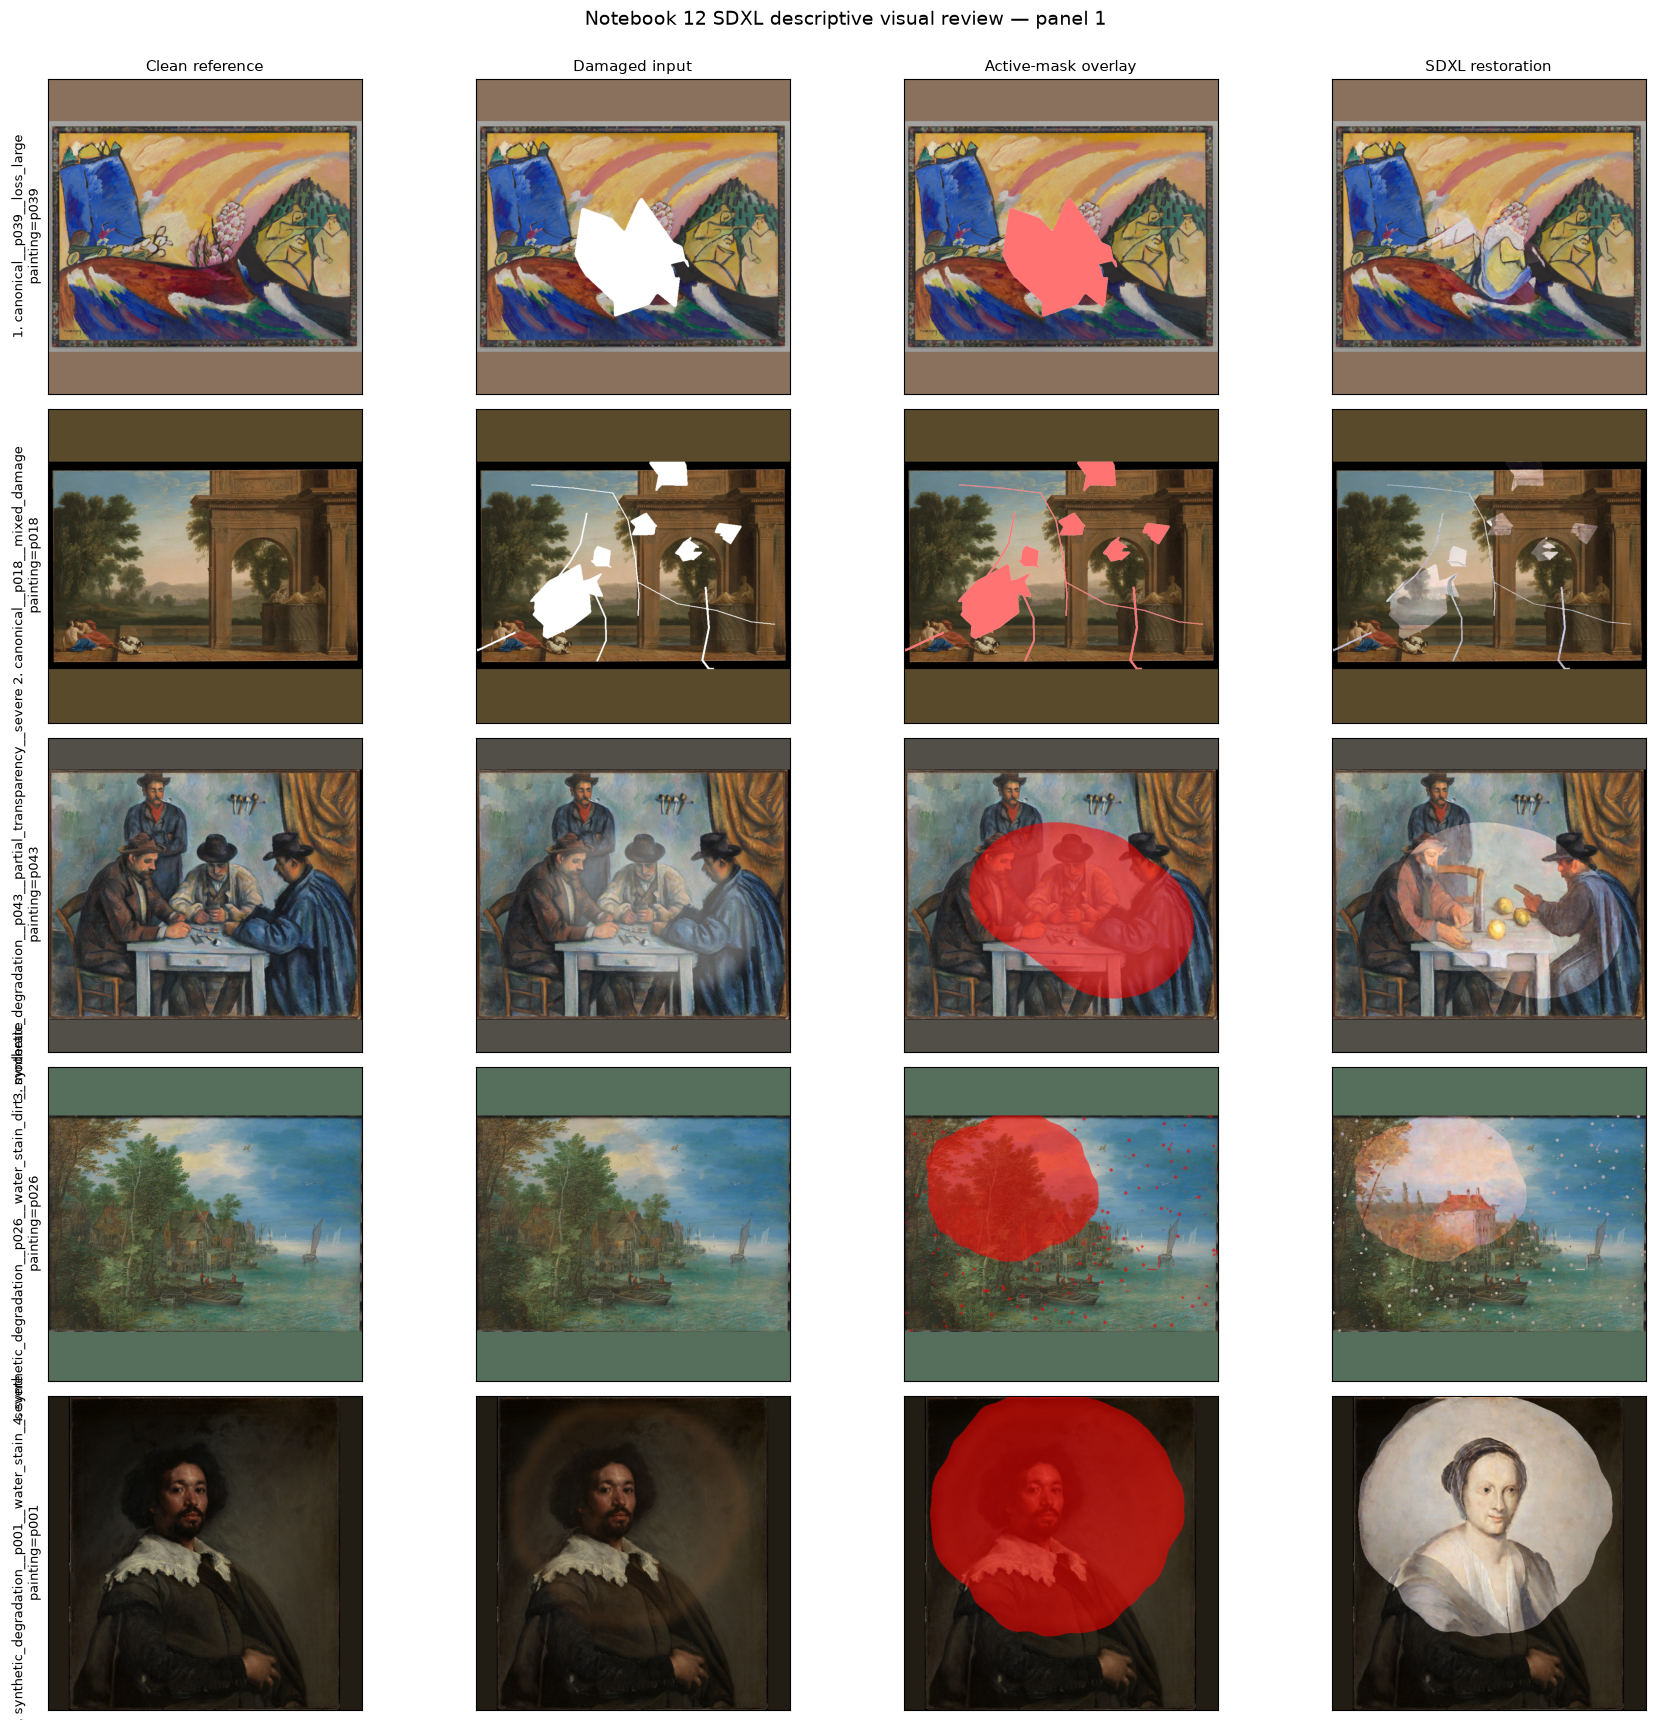

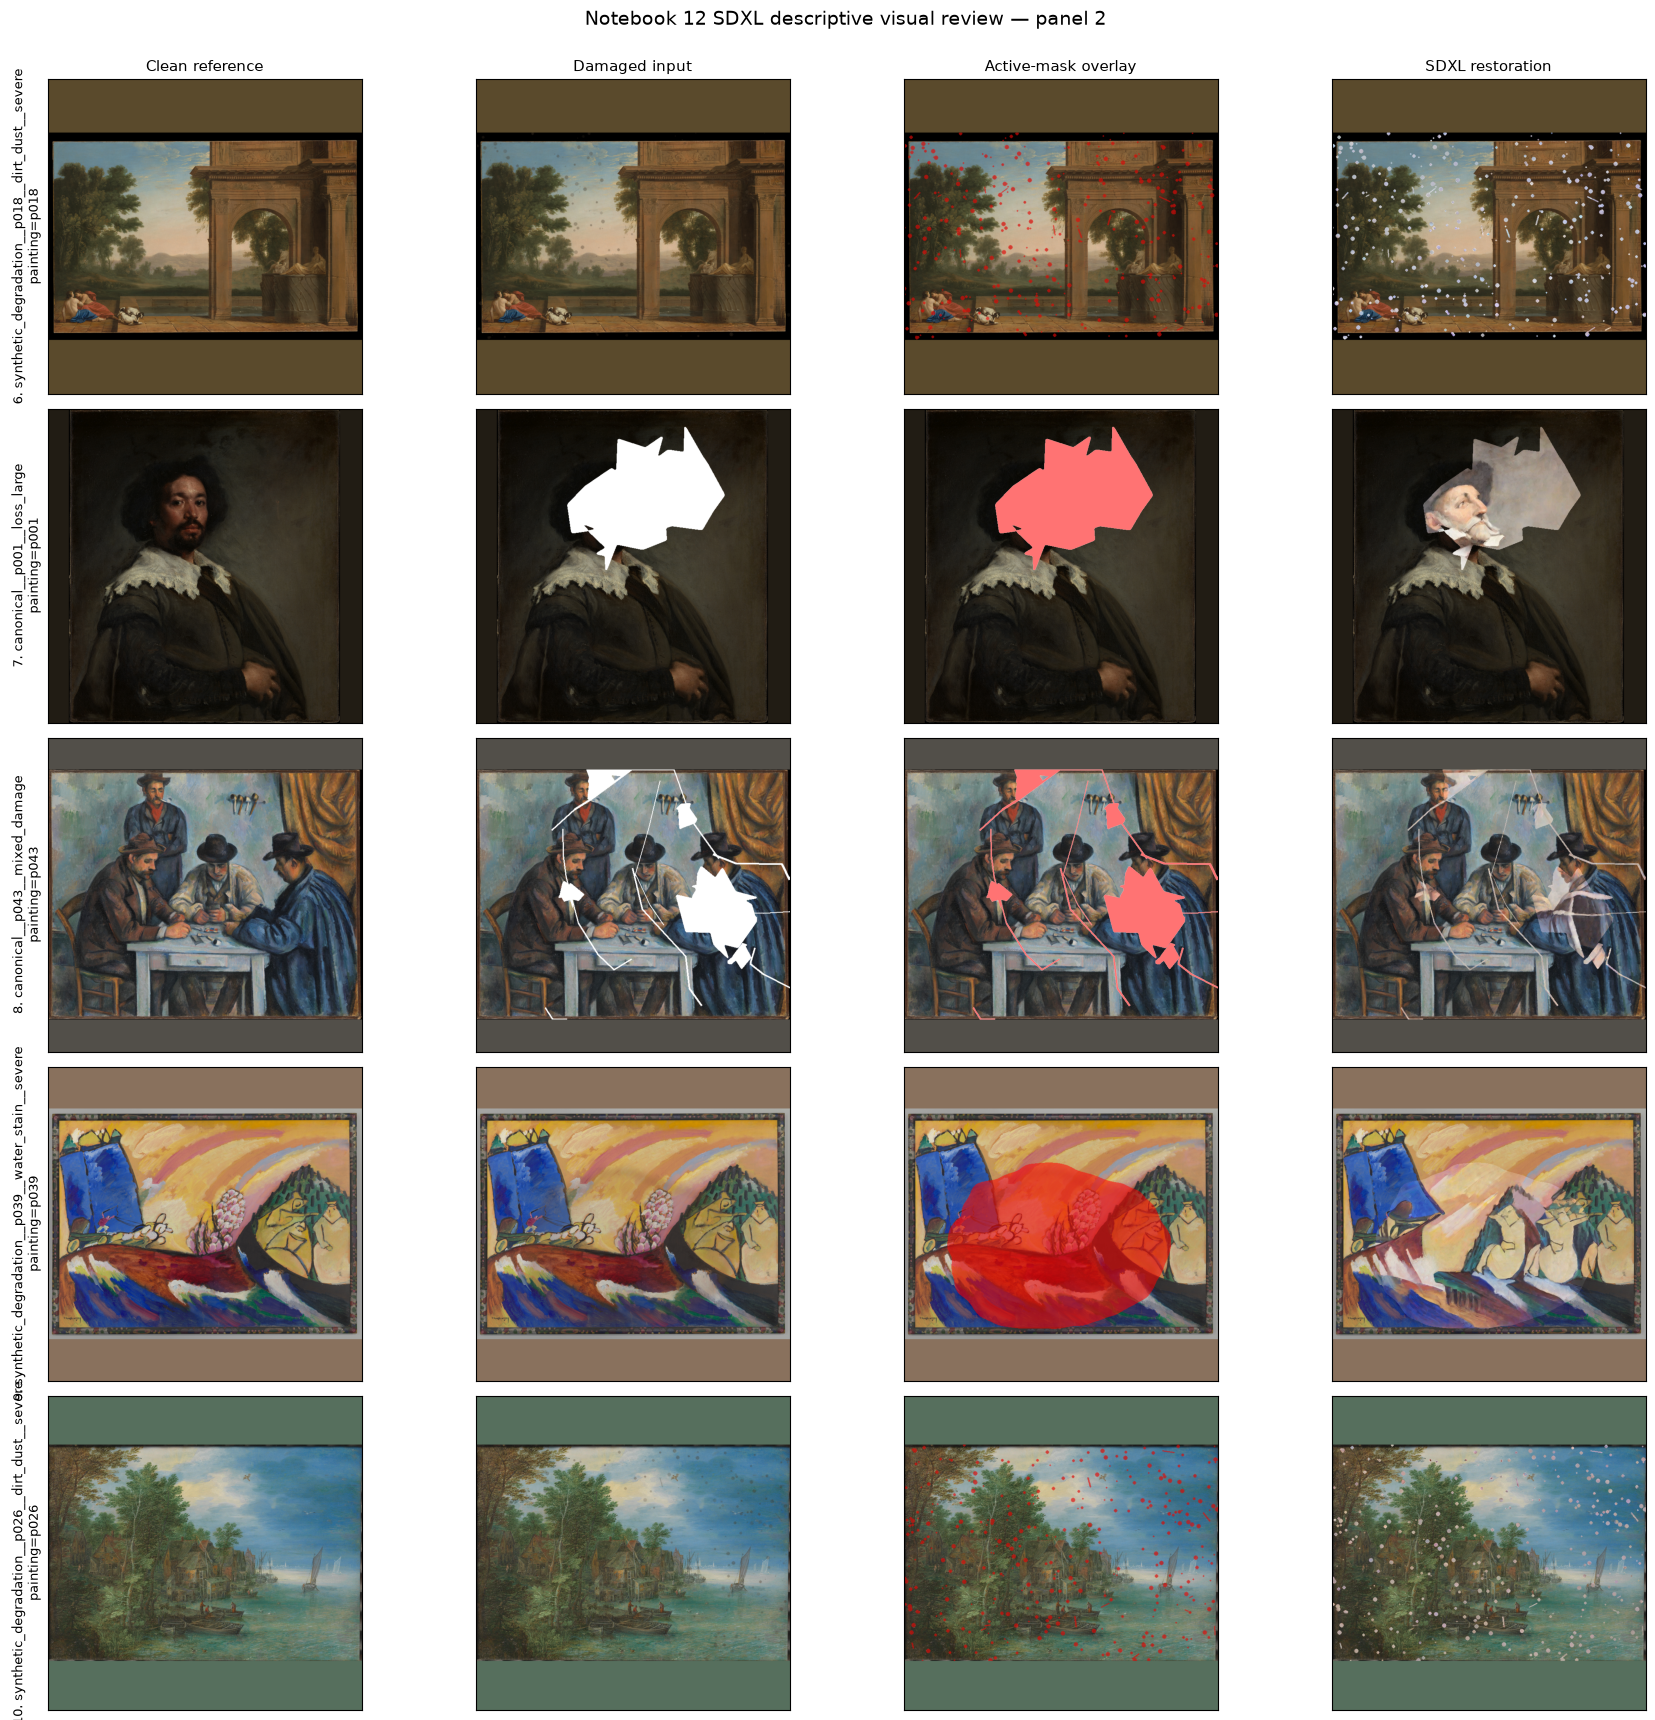

Notebook-only visual review rendered.
Rendered cases: 10
Unique rendered cases: 10
No review figure files were written to disk.


In [18]:
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Image-loading helpers for notebook-only visual review
# ---------------------------------------------------------------------------

def load_review_rgb(
    relative_path,
    output_size,
):
    with Image.open(
        PROJECT_ROOT / str(relative_path)
    ) as image_handle:
        return np.asarray(
            image_handle
            .convert("RGB")
            .resize(
                output_size,
                Image.Resampling.LANCZOS,
            ),
            dtype=np.uint8,
        )


def load_review_mask(
    relative_path,
    output_size,
    threshold,
):
    with Image.open(
        PROJECT_ROOT / str(relative_path)
    ) as mask_handle:
        mask_array = np.asarray(
            mask_handle
            .convert("L")
            .resize(
                output_size,
                Image.Resampling.NEAREST,
            ),
            dtype=np.uint8,
        )

    return (
        mask_array
        >= int(threshold)
    )


# ---------------------------------------------------------------------------
# Render every completed restoration in two five-case panels
# ---------------------------------------------------------------------------

visual_candidate_df = (
    sdxl_candidates_df.loc[
        sdxl_candidates_df[
            "status"
        ]
        .astype(str)
        .eq("completed")
    ]
    .sort_values(
        "execution_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

rendered_visual_case_ids = []

for panel_number, panel_start in enumerate(
    range(0, len(visual_candidate_df), 5),
    start=1,
):
    panel_df = (
        visual_candidate_df
        .iloc[
            panel_start:
            panel_start + 5
        ]
        .reset_index(drop=True)
    )

    figure, axes = plt.subplots(
        nrows=len(panel_df),
        ncols=4,
        figsize=(18, 3.5 * len(panel_df)),
        squeeze=False,
    )

    column_titles = (
        "Clean reference",
        "Damaged input",
        "Active-mask overlay",
        "SDXL restoration",
    )

    for row_index, candidate_row in enumerate(
        panel_df.itertuples(index=False)
    ):
        output_size = (
            int(candidate_row.output_width),
            int(candidate_row.output_height),
        )

        clean_array = load_review_rgb(
            candidate_row.clean_image_path,
            output_size,
        )

        input_array = load_review_rgb(
            candidate_row.input_image_path,
            output_size,
        )

        restored_array = load_review_rgb(
            candidate_row.restored_path,
            output_size,
        )

        active_mask = load_review_mask(
            candidate_row.mask_or_effect_path,
            output_size,
            candidate_row.mask_threshold,
        )

        mask_overlay = np.zeros(
            (
                output_size[1],
                output_size[0],
                4,
            ),
            dtype=np.float32,
        )

        mask_overlay[..., 0] = 1.0
        mask_overlay[..., 3] = (
            active_mask.astype(np.float32)
            * 0.55
        )

        axes[row_index, 0].imshow(
            clean_array
        )

        axes[row_index, 1].imshow(
            input_array
        )

        axes[row_index, 2].imshow(
            input_array
        )

        axes[row_index, 2].imshow(
            mask_overlay
        )

        axes[row_index, 3].imshow(
            restored_array
        )

        axes[row_index, 0].set_ylabel(
            (
                f"{candidate_row.execution_order}. "
                f"{candidate_row.case_id}\n"
                f"painting={candidate_row.painting_id}"
            ),
            fontsize=9,
        )

        if row_index == 0:
            for column_index, title in enumerate(
                column_titles
            ):
                axes[
                    row_index,
                    column_index,
                ].set_title(
                    title,
                    fontsize=11,
                )

        for column_index in range(4):
            axes[
                row_index,
                column_index,
            ].set_xticks([])

            axes[
                row_index,
                column_index,
            ].set_yticks([])

        rendered_visual_case_ids.append(
            str(candidate_row.case_id)
        )

    figure.suptitle(
        (
            "Notebook 12 SDXL descriptive visual review "
            f"— panel {panel_number}"
        ),
        fontsize=14,
    )

    figure.tight_layout(
        rect=(0.0, 0.0, 1.0, 0.98)
    )

    plt.show()
    plt.close(figure)

print("Notebook-only visual review rendered.")
print(
    "Rendered cases:",
    len(rendered_visual_case_ids),
)
print(
    "Unique rendered cases:",
    len(set(rendered_visual_case_ids)),
)
print(
    "No review figure files were written to disk."
)

In [19]:
# ---------------------------------------------------------------------------
# Batch 6 validation
# ---------------------------------------------------------------------------

def add_batch_6_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_6_analysis_and_visual_review"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_6_check(
    "runtime_summary_schema",
    "The runtime summary passes its exact normalized schema.",
    True,
    runtime_summary_schema_result.passed,
    runtime_summary_schema_result.passed,
    details=runtime_summary_schema_result.to_dict(),
)

add_batch_6_check(
    "runtime_summary_rows",
    "The runtime summary contains one overall and two experiment rows.",
    3,
    len(runtime_summary_df),
    len(runtime_summary_df) == 3,
)

add_batch_6_check(
    "runtime_summary_scopes",
    "The runtime summary contains the approved scopes.",
    [
        "experiment",
        "overall",
    ],
    sorted(
        runtime_summary_df[
            "summary_scope"
        ].unique().tolist()
    ),
    (
        set(
            runtime_summary_df[
                "summary_scope"
            ]
        )
        == {
            "overall",
            "experiment",
        }
    ),
)

overall_summary_df = (
    runtime_summary_df.loc[
        runtime_summary_df[
            "summary_scope"
        ].eq("overall")
    ]
)

add_batch_6_check(
    "overall_summary_unique",
    "Exactly one overall runtime-summary row exists.",
    1,
    len(overall_summary_df),
    len(overall_summary_df) == 1,
)

overall_summary_row = (
    overall_summary_df.iloc[0]
)

add_batch_6_check(
    "overall_case_count",
    "The overall summary covers all ten candidates.",
    10,
    int(overall_summary_row["case_count"]),
    int(overall_summary_row["case_count"]) == 10,
)

add_batch_6_check(
    "overall_completed_count",
    "The overall summary records ten completed candidates.",
    10,
    int(
        overall_summary_row[
            "completed_count"
        ]
    ),
    (
        int(
            overall_summary_row[
                "completed_count"
            ]
        )
        == 10
    ),
)

add_batch_6_check(
    "overall_failed_count",
    "The overall summary records no unresolved candidates.",
    0,
    int(overall_summary_row["failed_count"]),
    int(overall_summary_row["failed_count"]) == 0,
)

runtime_total_seconds = float(
    overall_summary_row[
        "total_runtime_seconds"
    ]
)

parent_runtime_seconds = float(
    batch_process_result.runtime_seconds
)

add_batch_6_check(
    "candidate_runtime_within_parent_runtime",
    (
        "Summed candidate runtime does not exceed "
        "the parent worker wall-clock runtime."
    ),
    f"<= {parent_runtime_seconds:.3f}",
    round(runtime_total_seconds, 3),
    runtime_total_seconds <= parent_runtime_seconds,
)

maximum_case_runtime_seconds = float(
    pd.to_numeric(
        sdxl_candidates_df[
            "runtime_seconds"
        ],
        errors="coerce",
    ).max()
)

add_batch_6_check(
    "maximum_case_runtime_guardrail",
    "No completed candidate exceeded the 900-second watchdog.",
    (
        f"<= "
        f"{execution['per_case_timeout_seconds']}"
    ),
    round(
        maximum_case_runtime_seconds,
        3,
    ),
    (
        maximum_case_runtime_seconds
        <= float(
            execution[
                "per_case_timeout_seconds"
            ]
        )
    ),
)

add_batch_6_check(
    "parent_runtime_global_budget",
    "Parent execution remained within the global budget allowance.",
    (
        f"<= "
        f"{execution['global_budget_seconds'] + 20}"
    ),
    round(parent_runtime_seconds, 3),
    (
        parent_runtime_seconds
        <= float(
            execution[
                "global_budget_seconds"
            ]
        )
        + 20.0
    ),
)

add_batch_6_check(
    "partial_availability_state",
    "The bounded branch remains explicitly classified as partial evaluation.",
    "partial_evaluation",
    sdxl_availability_state,
    (
        sdxl_availability_state
        == "partial_evaluation"
    ),
)

expected_visual_case_ids = set(
    sdxl_candidates_df.loc[
        sdxl_candidates_df[
            "status"
        ]
        .astype(str)
        .eq("completed"),
        "case_id",
    ]
    .astype(str)
)

observed_visual_case_ids = set(
    rendered_visual_case_ids
)

add_batch_6_check(
    "visual_review_case_coverage",
    "Every completed case appears in the rendered visual review.",
    sorted(expected_visual_case_ids),
    sorted(observed_visual_case_ids),
    (
        observed_visual_case_ids
        == expected_visual_case_ids
    ),
)

add_batch_6_check(
    "visual_review_no_duplicates",
    "Each completed case is rendered exactly once.",
    10,
    len(rendered_visual_case_ids),
    (
        len(rendered_visual_case_ids)
        == len(set(rendered_visual_case_ids))
        == 10
    ),
)

report_text_lower = (
    partial_evaluation_report_text.lower()
)

report_required_phrases = {
    "partial scope": (
        "purposive partial evaluation"
    ),
    "painting independent unit": (
        "independent unit is the painting"
    ),
    "nested cases": (
        "nested observations"
    ),
    "technical eligibility": (
        "only completed rows"
    ),
    "quality boundary": (
        "no subjective quality score"
    ),
    "conservation boundary": (
        "conservation recommendation"
    ),
}

missing_report_phrases = [
    label
    for label, phrase
    in report_required_phrases.items()
    if phrase not in report_text_lower
]

add_batch_6_check(
    "partial_report_content",
    "The draft report contains every required interpretation boundary.",
    0,
    len(missing_report_phrases),
    not missing_report_phrases,
    details={
        "missing_report_phrases": (
            missing_report_phrases
        ),
    },
)

premature_canonical_paths = [
    to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path
    in OUTPUTS.items()
    if (
        output_key != "restored_directory"
        and output_path.is_file()
    )
]

add_batch_6_check(
    "no_premature_canonical_persistence",
    (
        "Batch 6 has not yet persisted candidates, metrics, "
        "reports, manifests, or validation tables."
    ),
    0,
    len(premature_canonical_paths),
    not premature_canonical_paths,
    details=premature_canonical_paths,
)

add_batch_6_check(
    "quality_claim_boundary",
    (
        "Rendered visual review remains descriptive "
        "and separate from technical validation."
    ),
    "descriptive_human_review_required",
    sorted(
        visual_review_scope_df[
            "review_role"
        ].unique().tolist()
    ),
    (
        set(
            visual_review_scope_df[
                "review_role"
            ]
        )
        == {
            "descriptive_human_review_required"
        }
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce Batch 6 result
# ---------------------------------------------------------------------------

all_validation_df = VALIDATION.to_dataframe()

batch_6_validation_df = all_validation_df.loc[
    all_validation_df[
        "validation_stage"
    ].eq(
        "batch_6_analysis_and_visual_review"
    )
].reset_index(drop=True)

batch_6_summary = {
    "check_count": len(batch_6_validation_df),
    "passed_count": int(
        batch_6_validation_df["passed"].sum()
    ),
    "failed_count": int(
        (~batch_6_validation_df["passed"]).sum()
    ),
    "blocking_failure_count": int(
        (
            ~batch_6_validation_df["passed"]
            & batch_6_validation_df[
                "severity"
            ].eq("blocking")
        ).sum()
    ),
    "warning_failure_count": int(
        (
            ~batch_6_validation_df["passed"]
            & batch_6_validation_df[
                "severity"
            ].eq("warning")
        ).sum()
    ),
}

display(batch_6_validation_df)
display(pd.DataFrame([batch_6_summary]))

VALIDATION.raise_for_blocking()

print("Batch 6 analysis and visual review passed.")
print(
    "Batch 6 checks:",
    batch_6_summary["check_count"],
)
print(
    "Rendered cases:",
    len(rendered_visual_case_ids),
)
print(
    "Blocking failures:",
    batch_6_summary[
        "blocking_failure_count"
    ],
)
print(
    "Warning failures:",
    batch_6_summary[
        "warning_failure_count"
    ],
)
print(
    "Canonical persistence remains deferred to the next batch."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_analysis_and_visual_review,runtime_summary_schema,The runtime summary passes its exact normalize...,blocking,True,True,True,"{""column_count"": 12, ""duplicate_primary_key_ro..."
1,batch_6_analysis_and_visual_review,runtime_summary_rows,The runtime summary contains one overall and t...,blocking,3,3,True,
2,batch_6_analysis_and_visual_review,runtime_summary_scopes,The runtime summary contains the approved scopes.,blocking,"[""experiment"", ""overall""]","[""experiment"", ""overall""]",True,
3,batch_6_analysis_and_visual_review,overall_summary_unique,Exactly one overall runtime-summary row exists.,blocking,1,1,True,
4,batch_6_analysis_and_visual_review,overall_case_count,The overall summary covers all ten candidates.,blocking,10,10,True,
5,batch_6_analysis_and_visual_review,overall_completed_count,The overall summary records ten completed cand...,blocking,10,10,True,
6,batch_6_analysis_and_visual_review,overall_failed_count,The overall summary records no unresolved cand...,blocking,0,0,True,
7,batch_6_analysis_and_visual_review,candidate_runtime_within_parent_runtime,Summed candidate runtime does not exceed the p...,blocking,<= 3846.706,3784.687,True,
8,batch_6_analysis_and_visual_review,maximum_case_runtime_guardrail,No completed candidate exceeded the 900-second...,blocking,<= 900,599.522,True,
9,batch_6_analysis_and_visual_review,parent_runtime_global_budget,Parent execution remained within the global bu...,blocking,<= 7220,3846.706,True,


,check_count,passed_count,failed_count,blocking_failure_count,warning_failure_count
0,16,16,0,0,0


Batch 6 analysis and visual review passed.
Batch 6 checks: 16
Rendered cases: 10
Blocking failures: 0
Warning failures: 0
Canonical persistence remains deferred to the next batch.


## Batch 7 — Canonical Persistence and Provisional Handoff

This batch persists the complete downstream-facing Notebook 12 handoff:

- `data/candidates.csv`;
- ten technically valid restored images already under `images/restored/`;
- `metrics/runtime_summary.csv`;
- `reports/partial_evaluation_report.md`;
- `validation/checks.csv`;
- `manifests/artifacts.csv`;
- `manifests/run_manifest.json`.

The artifact manifest contains five records: candidates, restored images, runtime evidence, partial-evaluation report, and validation evidence.

The run manifest remains provisionally `running` until Batch 8 completes the roadmap audit, final completion gate, project-path registry replacement, and work-directory cleanup.

The four persistent-worker files under `work/partial_execution/` remain noncanonical checkpoint evidence during this batch.

In [21]:
import os

from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.restoration_sdxl import (
    write_partial_checkpoint,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    RUN_MANIFEST_REQUIRED_KEYS,
    VALIDATION_CHECKS_SCHEMA,
)


# ---------------------------------------------------------------------------
# Notebook and run identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "12"
NOTEBOOK_NAME = "SDXL Bounded Partial Evaluation"

ORIGIN = (
    "Existing Previous Version of Notebook 25, "
    "rebuilt from scratch as a bounded and reusable "
    "SDXL partial-evaluation branch"
)

DATASET_SCOPE = sdxl_config[
    "dataset"
][
    "dataset_scope"
]

RUN_EXPERIMENT_ID = sdxl_config[
    "dataset"
][
    "experiment_id"
]

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "restoration_sdxl": SDXL_HELPER_VERSION,
    "restoration_sdxl_worker": BATCH_WORKER_VERSION,
}


# ---------------------------------------------------------------------------
# Approved Batch 1–6 validation cardinalities
# ---------------------------------------------------------------------------

EXPECTED_VALIDATION_STAGE_COUNTS = {
    "batch_1_preflight": 86,
    "batch_2_scope_and_candidate_plan": 34,
    "batch_3_worker_and_guardrail_preflight": 24,
    "batch_4_bounded_execution": 16,
    "batch_5_independent_technical_validation": 23,
    "batch_6_analysis_and_visual_review": 16,
}

EXPECTED_PRE_PERSISTENCE_VALIDATION_ROWS = sum(
    EXPECTED_VALIDATION_STAGE_COUNTS.values()
)

pre_persistence_validation_df = (
    VALIDATION.to_dataframe()
    .drop_duplicates(
        subset=[
            "validation_stage",
            "check_id",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)

observed_validation_stage_counts = {
    str(stage): int(count)
    for stage, count in (
        pre_persistence_validation_df[
            "validation_stage"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

if (
    observed_validation_stage_counts
    != EXPECTED_VALIDATION_STAGE_COUNTS
):
    raise RuntimeError(
        "Batch 1–6 validation-stage counts disagree "
        "with the approved Notebook 12 contract. "
        f"Observed: {observed_validation_stage_counts}"
    )

pre_persistence_schema_result = (
    validate_dataframe(
        pre_persistence_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not pre_persistence_schema_result.passed:
    raise RuntimeError(
        "Batch 1–6 validation evidence does not "
        "match validation_checks.v1."
    )

if (
    len(pre_persistence_validation_df)
    != EXPECTED_PRE_PERSISTENCE_VALIDATION_ROWS
):
    raise RuntimeError(
        "Unexpected Batch 1–6 validation row count: "
        f"{len(pre_persistence_validation_df)}."
    )

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Exact canonical schemas before persistence
# ---------------------------------------------------------------------------

canonical_candidates_df = (
    sdxl_candidates_df
    .reindex(
        columns=(
            SDXL_PARTIAL_CANDIDATES_SCHEMA
            .required_columns
        )
    )
    .sort_values(
        "execution_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

canonical_runtime_summary_df = (
    runtime_summary_df
    .reindex(
        columns=(
            RESTORATION_RUNTIME_SUMMARY_SCHEMA
            .required_columns
        )
    )
    .reset_index(drop=True)
)

canonical_candidate_schema_result = (
    validate_dataframe(
        canonical_candidates_df,
        SDXL_PARTIAL_CANDIDATES_SCHEMA,
        allow_extra_columns=False,
    )
)

canonical_runtime_schema_result = (
    validate_dataframe(
        canonical_runtime_summary_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

if not canonical_candidate_schema_result.passed:
    raise RuntimeError(
        "Canonical SDXL candidates violate "
        "sdxl_partial_candidates.v1."
    )

if not canonical_runtime_schema_result.passed:
    raise RuntimeError(
        "Canonical runtime summary violates "
        "restoration_runtime_summary.v1."
    )


# ---------------------------------------------------------------------------
# Bounded Windows-safe atomic writers
# ---------------------------------------------------------------------------

def write_csv_atomic_with_retries(
    dataframe,
    destination,
    attempts=12,
    delay_seconds=0.25,
):
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    last_error = None

    for attempt_index in range(
        1,
        attempts + 1,
    ):
        temporary_path = (
            destination.parent
            / (
                f"{destination.name}.tmp."
                f"{os.getpid()}."
                f"{time.time_ns()}"
            )
        )

        try:
            dataframe.to_csv(
                temporary_path,
                index=False,
                lineterminator="\n",
            )

            os.replace(
                temporary_path,
                destination,
            )

            return destination

        except OSError as exc:
            last_error = exc

            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            if attempt_index < attempts:
                time.sleep(delay_seconds)

    raise PermissionError(
        "Could not atomically persist "
        f"{destination} after {attempts} attempts."
    ) from last_error


def write_text_atomic_with_retries(
    text,
    destination,
    attempts=12,
    delay_seconds=0.25,
):
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    last_error = None

    for attempt_index in range(
        1,
        attempts + 1,
    ):
        temporary_path = (
            destination.parent
            / (
                f"{destination.name}.tmp."
                f"{os.getpid()}."
                f"{time.time_ns()}"
            )
        )

        try:
            temporary_path.write_text(
                str(text),
                encoding="utf-8",
                newline="\n",
            )

            os.replace(
                temporary_path,
                destination,
            )

            return destination

        except OSError as exc:
            last_error = exc

            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            if attempt_index < attempts:
                time.sleep(delay_seconds)

    raise PermissionError(
        "Could not atomically persist "
        f"{destination} after {attempts} attempts."
    ) from last_error


# ---------------------------------------------------------------------------
# Persist the three previously unpersisted canonical products
# ---------------------------------------------------------------------------

write_partial_checkpoint(
    canonical_candidates_df,
    OUTPUTS["candidates"],
)

write_csv_atomic_with_retries(
    canonical_runtime_summary_df,
    OUTPUTS["runtime_summary"],
)

write_text_atomic_with_retries(
    partial_evaluation_report_text,
    OUTPUTS["partial_evaluation_report"],
)


# ---------------------------------------------------------------------------
# Reload all three products
# ---------------------------------------------------------------------------

candidates_reloaded_df = pd.read_csv(
    OUTPUTS["candidates"],
    keep_default_na=False,
)

runtime_summary_reloaded_df = pd.read_csv(
    OUTPUTS["runtime_summary"],
    keep_default_na=False,
)

partial_evaluation_report_reloaded = (
    OUTPUTS[
        "partial_evaluation_report"
    ]
    .read_text(encoding="utf-8")
)

candidate_reload_schema_result = (
    validate_dataframe(
        candidates_reloaded_df,
        SDXL_PARTIAL_CANDIDATES_SCHEMA,
        allow_extra_columns=False,
    )
)

runtime_reload_schema_result = (
    validate_dataframe(
        runtime_summary_reloaded_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

print("Canonical candidate, runtime, and report products persisted.")
print("Candidate rows:", len(candidates_reloaded_df))
print(
    "Runtime-summary rows:",
    len(runtime_summary_reloaded_df),
)
print(
    "Report characters:",
    len(partial_evaluation_report_reloaded),
)

Canonical candidate, runtime, and report products persisted.
Candidate rows: 10
Runtime-summary rows: 3
Report characters: 2877


In [23]:
# ---------------------------------------------------------------------------
# Separate canonical-persistence validation
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = ValidationCollector()


def add_persistence_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    PERSISTENCE_VALIDATION.add(
        validation_stage=(
            "batch_7_canonical_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_persistence_check(
    "candidate_reload_schema",
    "Persisted candidates.csv passes its exact schema.",
    True,
    candidate_reload_schema_result.passed,
    candidate_reload_schema_result.passed,
    details=candidate_reload_schema_result.to_dict(),
)

add_persistence_check(
    "runtime_reload_schema",
    "Persisted runtime_summary.csv passes its exact schema.",
    True,
    runtime_reload_schema_result.passed,
    runtime_reload_schema_result.passed,
    details=runtime_reload_schema_result.to_dict(),
)

expected_candidate_ids = (
    canonical_candidates_df[
        "candidate_id"
    ]
    .astype(str)
    .tolist()
)

observed_candidate_ids = (
    candidates_reloaded_df[
        "candidate_id"
    ]
    .astype(str)
    .tolist()
)

add_persistence_check(
    "candidate_identity",
    "Persisted candidate identities retain execution order.",
    expected_candidate_ids,
    observed_candidate_ids,
    observed_candidate_ids == expected_candidate_ids,
)

add_persistence_check(
    "candidate_count",
    "Persisted candidates.csv contains all ten rows.",
    10,
    len(candidates_reloaded_df),
    len(candidates_reloaded_df) == 10,
)

persisted_completed_mask = (
    candidates_reloaded_df["status"]
    .astype(str)
    .eq("completed")
)

persisted_technical_mask = (
    candidates_reloaded_df[
        "technical_validation_passed"
    ]
    .astype(str)
    .str.lower()
    .eq("true")
)

add_persistence_check(
    "eligible_candidate_count",
    (
        "All ten persisted rows are completed and "
        "technically eligible downstream."
    ),
    10,
    int(
        (
            persisted_completed_mask
            & persisted_technical_mask
        ).sum()
    ),
    bool(
        (
            persisted_completed_mask
            & persisted_technical_mask
        ).all()
    ),
)

persisted_restored_paths = {
    (
        PROJECT_ROOT
        / relative_path
    ).resolve()
    for relative_path in (
        candidates_reloaded_df[
            "restored_path"
        ]
        .astype(str)
        .tolist()
    )
}

missing_persisted_restorations = sorted(
    str(path)
    for path in persisted_restored_paths
    if not path.is_file()
)

add_persistence_check(
    "restored_paths_exist",
    "Every persisted candidate restoration exists.",
    0,
    len(missing_persisted_restorations),
    not missing_persisted_restorations,
    details=missing_persisted_restorations,
)

restored_checksum_failures = []

for candidate_row in (
    candidates_reloaded_df
    .sort_values(
        "execution_order",
        kind="stable",
    )
    .itertuples(index=False)
):
    restored_path = (
        PROJECT_ROOT
        / str(candidate_row.restored_path)
    )

    observed_checksum = sha256_file(
        restored_path
    )

    if (
        observed_checksum
        != str(candidate_row.restored_sha256)
    ):
        restored_checksum_failures.append(
            {
                "candidate_id": (
                    candidate_row.candidate_id
                ),
                "expected": (
                    candidate_row.restored_sha256
                ),
                "observed": observed_checksum,
            }
        )

add_persistence_check(
    "restored_checksums",
    "Every persisted restoration retains its recorded checksum.",
    0,
    len(restored_checksum_failures),
    not restored_checksum_failures,
    details=restored_checksum_failures,
)

runtime_identity_columns = [
    "summary_scope",
    "experiment_id",
]

expected_runtime_identity = (
    canonical_runtime_summary_df[
        runtime_identity_columns
    ]
    .astype(str)
    .to_dict("records")
)

observed_runtime_identity = (
    runtime_summary_reloaded_df[
        runtime_identity_columns
    ]
    .astype(str)
    .to_dict("records")
)

add_persistence_check(
    "runtime_summary_identity",
    "Persisted runtime-summary scopes retain their identity.",
    expected_runtime_identity,
    observed_runtime_identity,
    (
        observed_runtime_identity
        == expected_runtime_identity
    ),
)

expected_runtime_total = float(
    canonical_runtime_summary_df.loc[
        canonical_runtime_summary_df[
            "summary_scope"
        ].eq("overall"),
        "total_runtime_seconds",
    ].iloc[0]
)

observed_runtime_total = float(
    pd.to_numeric(
        runtime_summary_reloaded_df.loc[
            runtime_summary_reloaded_df[
                "summary_scope"
            ].eq("overall"),
            "total_runtime_seconds",
        ],
        errors="raise",
    ).iloc[0]
)

add_persistence_check(
    "runtime_total",
    "Persisted overall runtime retains its exact value.",
    expected_runtime_total,
    observed_runtime_total,
    bool(
        np.isclose(
            observed_runtime_total,
            expected_runtime_total,
            rtol=0.0,
            atol=1e-9,
        )
    ),
)

add_persistence_check(
    "report_round_trip",
    "The persisted report exactly matches its in-memory text.",
    True,
    (
        partial_evaluation_report_reloaded
        == partial_evaluation_report_text
    ),
    (
        partial_evaluation_report_reloaded
        == partial_evaluation_report_text
    ),
)

add_persistence_check(
    "report_nonempty",
    "The persisted partial-evaluation report is nonempty.",
    "> 1000 characters",
    len(partial_evaluation_report_reloaded),
    (
        len(
            partial_evaluation_report_reloaded
        )
        > 1000
    ),
)

base_expected_canonical_paths = (
    persisted_restored_paths
    | {
        OUTPUTS["candidates"].resolve(),
        OUTPUTS[
            "runtime_summary"
        ].resolve(),
        OUTPUTS[
            "partial_evaluation_report"
        ].resolve(),
    }
)

base_observed_canonical_paths = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and not path.resolve().is_relative_to(
            WORK_PATHS[
                "work_directory"
            ].resolve()
        )
    )
}

add_persistence_check(
    "base_canonical_file_set",
    (
        "The output root contains exactly ten images "
        "and the three newly persisted products."
    ),
    {
        "files": 13,
        "exact_set": True,
    },
    {
        "files": len(
            base_observed_canonical_paths
        ),
        "exact_set": (
            base_observed_canonical_paths
            == base_expected_canonical_paths
        ),
    },
    (
        len(base_observed_canonical_paths) == 13
        and base_observed_canonical_paths
        == base_expected_canonical_paths
    ),
)

temporary_base_outputs = sorted(
    str(path)
    for path in base_observed_canonical_paths
    if (
        ".tmp" in path.name.lower()
        or ".staging" in path.name.lower()
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

add_persistence_check(
    "no_temporary_canonical_files",
    "No temporary file leaked into the canonical output set.",
    0,
    len(temporary_base_outputs),
    not temporary_base_outputs,
    details=temporary_base_outputs,
)


# ---------------------------------------------------------------------------
# Enforce persistence checks
# ---------------------------------------------------------------------------

persistence_checks_df = (
    PERSISTENCE_VALIDATION.to_dataframe()
)

PERSISTENCE_VALIDATION.raise_for_blocking()

EXPECTED_PERSISTENCE_CHECK_COUNT = 13

if (
    len(persistence_checks_df)
    != EXPECTED_PERSISTENCE_CHECK_COUNT
):
    raise RuntimeError(
        "Unexpected Batch 7 persistence-check count: "
        f"{len(persistence_checks_df)}."
    )


# ---------------------------------------------------------------------------
# Consolidate and persist validation evidence
# ---------------------------------------------------------------------------

validation_checks_df = (
    pd.concat(
        [
            pre_persistence_validation_df,
            persistence_checks_df,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        subset=[
            "validation_stage",
            "check_id",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)

EXPECTED_CONSOLIDATED_VALIDATION_ROWS = (
    EXPECTED_PRE_PERSISTENCE_VALIDATION_ROWS
    + EXPECTED_PERSISTENCE_CHECK_COUNT
)

validation_schema_result = (
    validate_dataframe(
        validation_checks_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not validation_schema_result.passed:
    raise RuntimeError(
        "Consolidated validation evidence does not "
        "match validation_checks.v1."
    )

if (
    len(validation_checks_df)
    != EXPECTED_CONSOLIDATED_VALIDATION_ROWS
):
    raise RuntimeError(
        "Unexpected consolidated validation count: "
        f"{len(validation_checks_df)}."
    )

write_csv_atomic_with_retries(
    validation_checks_df,
    OUTPUTS["validation"],
)

validation_checks_reloaded_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

validation_reload_schema_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not validation_reload_schema_result.passed:
    raise RuntimeError(
        "Persisted validation/checks.csv does not "
        "match validation_checks.v1."
    )

reloaded_blocking_failures = (
    validation_checks_reloaded_df[
        "severity"
    ]
    .astype(str)
    .eq("blocking")
    & ~validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.lower()
    .eq("true")
)

if reloaded_blocking_failures.any():
    raise RuntimeError(
        "Persisted validation evidence contains "
        "a blocking failure."
    )

display(persistence_checks_df)
display(
    pd.DataFrame(
        [
            {
                "pre_persistence_checks": (
                    EXPECTED_PRE_PERSISTENCE_VALIDATION_ROWS
                ),
                "persistence_checks": (
                    EXPECTED_PERSISTENCE_CHECK_COUNT
                ),
                "consolidated_checks": (
                    len(
                        validation_checks_reloaded_df
                    )
                ),
                "blocking_failures": int(
                    reloaded_blocking_failures.sum()
                ),
            }
        ]
    )
)

print("Canonical persistence validation passed.")
print(
    "Consolidated validation rows:",
    len(validation_checks_reloaded_df),
)
print("Blocking failures:", 0)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_canonical_persistence,candidate_reload_schema,Persisted candidates.csv passes its exact schema.,blocking,True,True,True,"{""column_count"": 72, ""duplicate_primary_key_ro..."
1,batch_7_canonical_persistence,runtime_reload_schema,Persisted runtime_summary.csv passes its exact...,blocking,True,True,True,"{""column_count"": 12, ""duplicate_primary_key_ro..."
2,batch_7_canonical_persistence,candidate_identity,Persisted candidate identities retain executio...,blocking,"[""sdxl__37161b5099c0__p00_generic__seed2026"", ...","[""sdxl__37161b5099c0__p00_generic__seed2026"", ...",True,
3,batch_7_canonical_persistence,candidate_count,Persisted candidates.csv contains all ten rows.,blocking,10,10,True,
4,batch_7_canonical_persistence,eligible_candidate_count,All ten persisted rows are completed and techn...,blocking,10,10,True,
5,batch_7_canonical_persistence,restored_paths_exist,Every persisted candidate restoration exists.,blocking,0,0,True,[]
6,batch_7_canonical_persistence,restored_checksums,Every persisted restoration retains its record...,blocking,0,0,True,[]
7,batch_7_canonical_persistence,runtime_summary_identity,Persisted runtime-summary scopes retain their ...,blocking,"[{""experiment_id"": ""all"", ""summary_scope"": ""ov...","[{""experiment_id"": ""all"", ""summary_scope"": ""ov...",True,
8,batch_7_canonical_persistence,runtime_total,Persisted overall runtime retains its exact va...,blocking,3784.6869999999994,3784.687,True,
9,batch_7_canonical_persistence,report_round_trip,The persisted report exactly matches its in-me...,blocking,True,True,True,


,pre_persistence_checks,persistence_checks,consolidated_checks,blocking_failures
0,199,13,212,0


Canonical persistence validation passed.
Consolidated validation rows: 212
Blocking failures: 0


In [24]:
# ---------------------------------------------------------------------------
# Build the five normalized artifact records
# ---------------------------------------------------------------------------

artifact_specifications = [
    {
        "artifact_key": "sdxl.candidates",
        "path": OUTPUTS["candidates"],
        "artifact_type": "table",
        "artifact_role": (
            "partial_evaluation_candidates"
        ),
        "schema_version": (
            SDXL_PARTIAL_CANDIDATES_SCHEMA.version
        ),
        "row_count": 10,
    },
    {
        "artifact_key": "sdxl.restored_images",
        "path": OUTPUTS["restored_directory"],
        "artifact_type": "image_directory",
        "artifact_role": (
            "technically_valid_partial_restorations"
        ),
        "schema_version": sdxl_config[
            "schema_versions"
        ][
            "restored_images"
        ],
        "row_count": 10,
    },
    {
        "artifact_key": "sdxl.runtime_summary",
        "path": OUTPUTS["runtime_summary"],
        "artifact_type": "table",
        "artifact_role": "bounded_runtime_evidence",
        "schema_version": (
            RESTORATION_RUNTIME_SUMMARY_SCHEMA.version
        ),
        "row_count": 3,
    },
    {
        "artifact_key": (
            "sdxl.partial_evaluation_report"
        ),
        "path": OUTPUTS[
            "partial_evaluation_report"
        ],
        "artifact_type": "report",
        "artifact_role": (
            "partial_scope_and_limitations"
        ),
        "schema_version": sdxl_config[
            "schema_versions"
        ][
            "partial_evaluation_report"
        ],
        "row_count": 1,
    },
    {
        "artifact_key": (
            "validation."
            "12_sdxl_feasibility_or_restoration"
        ),
        "path": OUTPUTS["validation"],
        "artifact_type": "table",
        "artifact_role": "validation_evidence",
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "row_count": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
    },
]

EXPECTED_ARTIFACT_RECORD_COUNT = int(
    sdxl_config[
        "output"
    ][
        "artifact_record_count"
    ]
)

artifact_records = []

for artifact_index, specification in enumerate(
    artifact_specifications,
    start=1,
):
    print(
        (
            f"Building artifact {artifact_index}/"
            f"{len(artifact_specifications)}: "
            f"{specification['artifact_key']}"
        )
    )

    artifact_records.append(
        build_artifact_record(
            artifact_key=specification[
                "artifact_key"
            ],
            producer_notebook=NOTEBOOK_STEM,
            path=specification["path"],
            artifact_type=specification[
                "artifact_type"
            ],
            artifact_role=specification[
                "artifact_role"
            ],
            schema_version=specification[
                "schema_version"
            ],
            dataset_scope=DATASET_SCOPE,
            experiment_id=RUN_EXPERIMENT_ID,
            validation_status="passed",
            row_count=specification[
                "row_count"
            ],
            project_root=PROJECT_ROOT,
        )
    )

artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

if (
    len(artifact_manifest_df)
    != EXPECTED_ARTIFACT_RECORD_COUNT
):
    raise RuntimeError(
        "Notebook 12 artifact manifest must "
        "contain exactly five records."
    )

write_artifact_manifest(
    OUTPUTS["artifacts"],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Normalized input/output contracts for the run manifest
# ---------------------------------------------------------------------------

def to_json_safe(value):
    def convert_value(item):
        if isinstance(item, np.generic):
            return item.item()

        if isinstance(item, Path):
            return str(item)

        return str(item)

    return json.loads(
        json.dumps(
            value,
            ensure_ascii=False,
            default=convert_value,
        )
    )


output_contract_records = [
    {
        "artifact_key": (
            specification["artifact_key"]
        ),
        "relative_path": to_repo_relative(
            specification["path"],
            PROJECT_ROOT,
        ),
        "artifact_type": (
            specification["artifact_type"]
        ),
        "artifact_role": (
            specification["artifact_role"]
        ),
        "schema_version": (
            specification["schema_version"]
        ),
        "expected_row_count": (
            specification["row_count"]
        ),
        "canonical": True,
    }
    for specification in artifact_specifications
]

output_contract_records.extend(
    [
        {
            "artifact_key": (
                "sdxl.artifact_manifest"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["artifacts"],
                PROJECT_ROOT,
            ),
            "artifact_type": "manifest",
            "artifact_role": "artifact_discovery",
            "schema_version": (
                ARTIFACT_MANIFEST_SCHEMA.version
            ),
            "expected_row_count": 5,
            "canonical": True,
        },
        {
            "artifact_key": "sdxl.run_manifest",
            "relative_path": to_repo_relative(
                OUTPUTS["run_manifest"],
                PROJECT_ROOT,
            ),
            "artifact_type": "manifest",
            "artifact_role": "run_provenance",
            "schema_version": (
                RUN_MANIFEST_SCHEMA_VERSION
            ),
            "expected_row_count": 1,
            "canonical": True,
        },
    ]
)

output_contract_df = pd.DataFrame(
    output_contract_records
)


# ---------------------------------------------------------------------------
# Configuration provenance
# ---------------------------------------------------------------------------

configuration_path_objects = [
    CONFIG_PATH,
    INPUTS[
        "evaluation_contract_config"
    ],
    INPUTS[
        "stable_diffusion_config"
    ],
    INPUTS[
        "synthetic_degradation_config"
    ],
]

configuration_paths = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in configuration_path_objects
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_path_objects,
        PROJECT_ROOT,
    )
)

run_inputs = to_json_safe(
    input_contract_df.to_dict(
        orient="records"
    )
)

run_outputs = to_json_safe(
    output_contract_df.to_dict(
        orient="records"
    )
)


# ---------------------------------------------------------------------------
# Expected and observed run counts
# ---------------------------------------------------------------------------

expected_run_counts = {
    "scheduled_candidate_count": 10,
    "painting_count": 5,
    "canonical_case_count": 4,
    "synthetic_case_count": 6,
    "completed_candidate_count": 10,
    "technically_valid_candidate_count": 10,
    "restored_file_count": 10,
    "runtime_summary_row_count": 3,
    "validation_row_count": (
        EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    ),
    "artifact_record_count": 5,
    "canonical_output_file_count": 16,
    "temporary_work_file_count": 4,
    "blocking_validation_failures": 0,
}

observed_work_files = {
    path.resolve()
    for path in (
        WORK_PATHS[
            "work_directory"
        ].rglob("*")
    )
    if path.is_file()
}

observed_run_counts = {
    "scheduled_candidate_count": int(
        len(candidates_reloaded_df)
    ),
    "painting_count": int(
        candidates_reloaded_df[
            "painting_id"
        ].nunique()
    ),
    "canonical_case_count": int(
        candidates_reloaded_df[
            "experiment_id"
        ]
        .astype(str)
        .eq("canonical_missing_region")
        .sum()
    ),
    "synthetic_case_count": int(
        candidates_reloaded_df[
            "experiment_id"
        ]
        .astype(str)
        .eq("synthetic_degradation")
        .sum()
    ),
    "completed_candidate_count": int(
        persisted_completed_mask.sum()
    ),
    "technically_valid_candidate_count": int(
        (
            persisted_completed_mask
            & persisted_technical_mask
        ).sum()
    ),
    "restored_file_count": int(
        len(persisted_restored_paths)
    ),
    "runtime_summary_row_count": int(
        len(runtime_summary_reloaded_df)
    ),
    "validation_row_count": int(
        len(validation_checks_reloaded_df)
    ),
    "artifact_record_count": int(
        len(artifact_manifest_df)
    ),
    "canonical_output_file_count": 16,
    "temporary_work_file_count": int(
        len(observed_work_files)
    ),
    "blocking_validation_failures": int(
        reloaded_blocking_failures.sum()
    ),
}


# ---------------------------------------------------------------------------
# Provisional run manifest
# ---------------------------------------------------------------------------

provisional_run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": sdxl_config[
            "dataset"
        ][
            "dataset_id"
        ],
        "dataset_version": sdxl_config[
            "dataset"
        ][
            "dataset_version"
        ],
        "dataset_scope": DATASET_SCOPE,
        "experiment_id": RUN_EXPERIMENT_ID,
        "configuration_schema": (
            sdxl_config[
                "config_schema_version"
            ]
        ),
        "configuration_version": (
            sdxl_config["config_version"]
        ),
        "configuration_fingerprint": (
            CONFIGURATION_FINGERPRINT
        ),
        "candidate_schema": (
            SDXL_PARTIAL_CANDIDATES_SCHEMA.version
        ),
        "runtime_summary_schema": (
            RESTORATION_RUNTIME_SUMMARY_SCHEMA.version
        ),
        "model_id": model["model_id"],
        "hf_model_id": model["hf_model_id"],
        "model_revision": (
            model["model_revision"]
        ),
        "configuration_id": (
            model["configuration_id"]
        ),
        "methodological_role": (
            model["methodological_role"]
        ),
        "requested_device": (
            model["requested_device"]
        ),
        "effective_device": "cuda",
        "precision": model["precision"],
        "inference_width": (
            model["inference_width"]
        ),
        "inference_height": (
            model["inference_height"]
        ),
        "num_inference_steps": (
            model["num_inference_steps"]
        ),
        "seed": model["seed"],
        "prompt_policy_id": (
            sdxl_config[
                "prompt_policy"
            ][
                "policy_id"
            ]
        ),
        "candidate_selection_policy": (
            selection["policy_id"]
        ),
        "independent_unit": (
            selection["independent_unit"]
        ),
        "repeated_unit": (
            selection["repeated_unit"]
        ),
        "availability_state": (
            sdxl_availability_state
        ),
        "restoration_quality_metric_authority": (
            "downstream_notebooks_13_onward"
        ),
        "inventory_checksum": (
            inventory_run[
                "inventory_sha256"
            ]
        ),
        "restoration_helper_sha256": (
            sha256_file(HELPER_PATH)
        ),
        "worker_helper_sha256": (
            sha256_file(WORKER_PATH)
        ),
        "schemas_helper_sha256": (
            sha256_file(SCHEMAS_PATH)
        ),
    },
    configuration_paths=configuration_paths,
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=expected_run_counts,
    observed_counts=observed_run_counts,
    validation_summary={
        "scientific_validation": (
            VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION.summary()
        ),
        "manifest_handoff": {
            "status": "pending",
            "passed": False,
        },
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=sdxl_config[
        "known_limitations"
    ],
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
        "torch",
        "diffusers",
        "transformers",
        "accelerate",
        "safetensors",
    ),
    hardware={
        "execution_device": "cuda",
        "gpu_required": True,
        "cuda_available": (
            torch.cuda.is_available()
        ),
        "cuda_device_name": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else "unavailable"
        ),
        "cuda_runtime_version": (
            torch.version.cuda
        ),
        "torch_version": (
            torch.__version__
        ),
        "maximum_gpu_peak_bytes": int(
            pd.to_numeric(
                candidates_reloaded_df[
                    "gpu_peak_memory_bytes"
                ],
                errors="coerce",
            ).max()
        ),
        "parent_runtime_seconds": float(
            batch_process_result.runtime_seconds
        ),
    },
)

provisional_run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            "dataset.artworks",
            "experiment_contracts.case_registry",
            "experiment_contracts.model_eligibility",
            "opencv_telea.restorations",
            "lama.restorations",
            "stable_diffusion.candidates",
            "current_inventory",
            "project_paths_registry",
        ],
        "applicable_dataset_scopes": [
            DATASET_SCOPE,
        ],
        "applicable_experiment_scopes": [
            "canonical_missing_region",
            "synthetic_degradation",
            RUN_EXPERIMENT_ID,
        ],
        "expensive_execution": True,
        "completion_gate_passed": False,
    }
)

RUN_ID = str(
    provisional_run_manifest["run_id"]
)

write_run_manifest(
    OUTPUTS["run_manifest"],
    provisional_run_manifest,
)

print("Artifact and provisional run manifests written.")
print(
    "Artifact records:",
    len(artifact_manifest_df),
)
print("Run ID:", RUN_ID)
print(
    "Run status:",
    provisional_run_manifest[
        "run_status"
    ],
)
print(
    "Completion gate passed:",
    provisional_run_manifest[
        "completion_gate_passed"
    ],
)

Building artifact 1/5: sdxl.candidates
Building artifact 2/5: sdxl.restored_images
Building artifact 3/5: sdxl.runtime_summary
Building artifact 4/5: sdxl.partial_evaluation_report
Building artifact 5/5: validation.12_sdxl_feasibility_or_restoration
Artifact and provisional run manifests written.
Artifact records: 5
Run ID: run_1daaf4a3dcb34b5599b0ff89bb7034d3
Run status: running
Completion gate passed: False


In [25]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as run_manifest_file:
    run_manifest_reloaded = json.load(
        run_manifest_file
    )

artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

expected_artifact_keys = {
    "sdxl.candidates",
    "sdxl.restored_images",
    "sdxl.runtime_summary",
    "sdxl.partial_evaluation_report",
    (
        "validation."
        "12_sdxl_feasibility_or_restoration"
    ),
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)


# ---------------------------------------------------------------------------
# Verify every artifact path and checksum
# ---------------------------------------------------------------------------

artifact_path_failures = []
artifact_checksum_failures = []

for artifact_index, artifact_row in enumerate(
    artifact_manifest_reloaded_df
    .itertuples(index=False),
    start=1,
):
    print(
        (
            f"Verifying artifact {artifact_index}/"
            f"{len(artifact_manifest_reloaded_df)}: "
            f"{artifact_row.artifact_key}"
        )
    )

    artifact_path = (
        PROJECT_ROOT
        / str(artifact_row.relative_path)
    ).resolve()

    if not artifact_path.exists():
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": "missing_path",
            }
        )

        continue

    if not artifact_path.is_relative_to(
        NOTEBOOK_OUTPUT_ROOT.resolve()
    ):
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    "outside_notebook_output_root"
                ),
            }
        )

        continue

    observed_checksum = sha256_path(
        artifact_path
    )

    if (
        observed_checksum
        != str(artifact_row.checksum)
    ):
        artifact_checksum_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected": (
                    artifact_row.checksum
                ),
                "observed": observed_checksum,
            }
        )


# ---------------------------------------------------------------------------
# Provisional run-manifest contract
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(run_manifest_reloaded)
)

run_manifest_matches_memory = bool(
    run_manifest_reloaded
    == to_json_safe(
        provisional_run_manifest
    )
)

run_manifest_state_valid = bool(
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and run_manifest_reloaded[
        "completed_at_utc"
    ]
    == ""
    and run_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and run_manifest_reloaded[
        "inventory_run_id"
    ]
    == str(
        inventory_run[
            "inventory_run_id"
        ]
    )
    and run_manifest_reloaded[
        "completion_gate_passed"
    ]
    is False
)


# ---------------------------------------------------------------------------
# Exact canonical 16-file output contract
# ---------------------------------------------------------------------------

expected_canonical_output_paths = (
    persisted_restored_paths
    | {
        OUTPUTS["candidates"].resolve(),
        OUTPUTS[
            "runtime_summary"
        ].resolve(),
        OUTPUTS[
            "partial_evaluation_report"
        ].resolve(),
        OUTPUTS["validation"].resolve(),
        OUTPUTS["artifacts"].resolve(),
        OUTPUTS["run_manifest"].resolve(),
    }
)

observed_canonical_output_paths = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and not path.resolve().is_relative_to(
            WORK_PATHS[
                "work_directory"
            ].resolve()
        )
    )
}

missing_canonical_output_paths = (
    expected_canonical_output_paths
    - observed_canonical_output_paths
)

undeclared_canonical_output_paths = (
    observed_canonical_output_paths
    - expected_canonical_output_paths
)

temporary_canonical_output_paths = {
    path
    for path in observed_canonical_output_paths
    if (
        ".tmp" in path.name.lower()
        or ".staging" in path.name.lower()
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
}

exact_canonical_output_set_valid = bool(
    len(observed_canonical_output_paths) == 16
    and (
        observed_canonical_output_paths
        == expected_canonical_output_paths
    )
    and not temporary_canonical_output_paths
)

observed_work_files = {
    path.resolve()
    for path in (
        WORK_PATHS[
            "work_directory"
        ].rglob("*")
    )
    if path.is_file()
}

expected_work_file_names = {
    "batch_job.json",
    "batch_result.json",
    "candidate_checkpoint.csv",
    "progress.json",
}

observed_work_file_names = {
    path.name
    for path in observed_work_files
}

work_files_valid = bool(
    len(observed_work_files) == 4
    and (
        observed_work_file_names
        == expected_work_file_names
    )
    and not (
        observed_work_files
        & observed_canonical_output_paths
    )
)


# ---------------------------------------------------------------------------
# Separate provisional manifest-handoff validation
# ---------------------------------------------------------------------------

MANIFEST_HANDOFF_VALIDATION = ValidationCollector()


def add_manifest_handoff_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    MANIFEST_HANDOFF_VALIDATION.add(
        validation_stage=(
            "batch_7_manifest_handoff"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


artifact_manifest_contract_valid = bool(
    artifact_manifest_reload_result.passed
    and (
        len(artifact_manifest_reloaded_df)
        == EXPECTED_ARTIFACT_RECORD_COUNT
    )
    and observed_artifact_keys
    == expected_artifact_keys
    and artifact_manifest_reloaded_df[
        "validation_status"
    ]
    .astype(str)
    .eq("passed")
    .all()
)

add_manifest_handoff_check(
    "artifact_manifest_contract",
    (
        "artifacts.csv satisfies its schema and "
        "contains the five declared artifacts."
    ),
    {
        "records": 5,
        "schema_valid": True,
        "keys": sorted(
            expected_artifact_keys
        ),
    },
    {
        "records": len(
            artifact_manifest_reloaded_df
        ),
        "schema_valid": (
            artifact_manifest_reload_result
            .passed
        ),
        "keys": sorted(
            observed_artifact_keys
        ),
    },
    artifact_manifest_contract_valid,
)

add_manifest_handoff_check(
    "artifact_paths_and_checksums",
    (
        "Every artifact exists inside Notebook 12 "
        "and matches its checksum."
    ),
    {
        "path_failures": 0,
        "checksum_failures": 0,
    },
    {
        "path_failures": len(
            artifact_path_failures
        ),
        "checksum_failures": len(
            artifact_checksum_failures
        ),
    },
    (
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
    details={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
)

add_manifest_handoff_check(
    "provisional_run_manifest",
    (
        "run_manifest.json reloads in its stable "
        "provisional state."
    ),
    {
        "missing_required_keys": 0,
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_memory": True,
    },
    {
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_memory": (
            run_manifest_matches_memory
        ),
    },
    run_manifest_state_valid,
)

add_manifest_handoff_check(
    "exact_canonical_output_set",
    (
        "The Notebook 12 output root contains "
        "exactly sixteen declared canonical files."
    ),
    {
        "canonical_files": 16,
        "missing_files": 0,
        "undeclared_files": 0,
        "temporary_files": 0,
    },
    {
        "canonical_files": len(
            observed_canonical_output_paths
        ),
        "missing_files": len(
            missing_canonical_output_paths
        ),
        "undeclared_files": len(
            undeclared_canonical_output_paths
        ),
        "temporary_files": len(
            temporary_canonical_output_paths
        ),
    },
    exact_canonical_output_set_valid,
    details={
        "missing_files": sorted(
            str(path)
            for path in (
                missing_canonical_output_paths
            )
        ),
        "undeclared_files": sorted(
            str(path)
            for path in (
                undeclared_canonical_output_paths
            )
        ),
        "temporary_files": sorted(
            str(path)
            for path in (
                temporary_canonical_output_paths
            )
        ),
    },
)

add_manifest_handoff_check(
    "work_files_remain_noncanonical",
    (
        "The four worker files remain isolated "
        "under work/ and outside canonical outputs."
    ),
    {
        "work_files": 4,
        "file_names": sorted(
            expected_work_file_names
        ),
        "canonical_overlap": 0,
    },
    {
        "work_files": len(
            observed_work_files
        ),
        "file_names": sorted(
            observed_work_file_names
        ),
        "canonical_overlap": len(
            observed_work_files
            & observed_canonical_output_paths
        ),
    },
    work_files_valid,
)

manifest_handoff_checks_df = (
    MANIFEST_HANDOFF_VALIDATION
    .to_dataframe()
)

MANIFEST_HANDOFF_VALIDATION.raise_for_blocking()

display(manifest_handoff_checks_df)
display(artifact_manifest_reloaded_df)

print("Batch 7 canonical persistence and handoff passed.")
print(
    "Scientific checks:",
    len(pre_persistence_validation_df),
)
print(
    "Persistence checks:",
    len(persistence_checks_df),
)
print(
    "Manifest-handoff checks:",
    len(manifest_handoff_checks_df),
)
print(
    "Artifact records:",
    len(artifact_manifest_reloaded_df),
)
print(
    "Canonical output files:",
    len(observed_canonical_output_paths),
)
print(
    "Temporary work files:",
    len(observed_work_files),
)
print(
    "Provisional run status:",
    run_manifest_reloaded["run_status"],
)
print(
    "Next approved stage: Batch 8 final completion, "
    "registry replacement, and work cleanup."
)

Verifying artifact 1/5: sdxl.candidates
Verifying artifact 2/5: sdxl.restored_images
Verifying artifact 3/5: sdxl.runtime_summary
Verifying artifact 4/5: sdxl.partial_evaluation_report
Verifying artifact 5/5: validation.12_sdxl_feasibility_or_restoration


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_manifest_handoff,artifact_manifest_contract,artifacts.csv satisfies its schema and contain...,blocking,"{""keys"": [""sdxl.candidates"", ""sdxl.partial_eva...","{""keys"": [""sdxl.candidates"", ""sdxl.partial_eva...",True,
1,batch_7_manifest_handoff,artifact_paths_and_checksums,Every artifact exists inside Notebook 12 and m...,blocking,"{""checksum_failures"": 0, ""path_failures"": 0}","{""checksum_failures"": 0, ""path_failures"": 0}",True,"{""checksum_failures"": [], ""path_failures"": []}"
2,batch_7_manifest_handoff,provisional_run_manifest,run_manifest.json reloads in its stable provis...,blocking,"{""completion_gate_passed"": false, ""matches_mem...","{""completion_gate_passed"": false, ""matches_mem...",True,
3,batch_7_manifest_handoff,exact_canonical_output_set,The Notebook 12 output root contains exactly s...,blocking,"{""canonical_files"": 16, ""missing_files"": 0, ""t...","{""canonical_files"": 16, ""missing_files"": 0, ""t...",True,"{""missing_files"": [], ""temporary_files"": [], ""..."
4,batch_7_manifest_handoff,work_files_remain_noncanonical,The four worker files remain isolated under wo...,blocking,"{""canonical_overlap"": 0, ""file_names"": [""batch...","{""canonical_overlap"": 0, ""file_names"": [""batch...",True,


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_5db66d6795acd52bbf48,sdxl.candidates,12_sdxl_feasibility_or_restoration,table,partial_evaluation_candidates,outputs/12_sdxl_feasibility_or_restoration/dat...,csv,controlled_50,cross_experiment_sdxl_partial_evaluation,sdxl_partial_candidates.v1,10,1,20267,987f13a42a1fbd59eefae630e6e74614d36a410cadb94e...,passed
1,artifact_8d87ef211aa8cb418dd4,sdxl.restored_images,12_sdxl_feasibility_or_restoration,image_directory,technically_valid_partial_restorations,outputs/12_sdxl_feasibility_or_restoration/ima...,directory,controlled_50,cross_experiment_sdxl_partial_evaluation,restored_images.sdxl_partial.v1,10,10,7091251,d64ad227f49f93d8801f82742c3b5864cb2a3adf9b56bb...,passed
2,artifact_f1b005ac1854fe81c3ad,sdxl.runtime_summary,12_sdxl_feasibility_or_restoration,table,bounded_runtime_evidence,outputs/12_sdxl_feasibility_or_restoration/met...,csv,controlled_50,cross_experiment_sdxl_partial_evaluation,restoration_runtime_summary.v1,3,1,595,7dcba00801acc11c809dc89f7e20615bc02467fe56f101...,passed
3,artifact_671d0625f7067047365e,sdxl.partial_evaluation_report,12_sdxl_feasibility_or_restoration,report,partial_scope_and_limitations,outputs/12_sdxl_feasibility_or_restoration/rep...,md,controlled_50,cross_experiment_sdxl_partial_evaluation,report.sdxl_partial_evaluation.v1,1,1,2877,155b1181fe38a41622528bf2a52c44eedd6657da1e3f37...,passed
4,artifact_44abb08b4ac0147ad22b,validation.12_sdxl_feasibility_or_restoration,12_sdxl_feasibility_or_restoration,table,validation_evidence,outputs/12_sdxl_feasibility_or_restoration/val...,csv,controlled_50,cross_experiment_sdxl_partial_evaluation,validation_checks.v1,212,1,53240,515b5a7461589d588c933be5f2b9e7b46dea1acb4203b9...,passed


Batch 7 canonical persistence and handoff passed.
Scientific checks: 199
Persistence checks: 13
Manifest-handoff checks: 5
Artifact records: 5
Canonical output files: 16
Temporary work files: 4
Provisional run status: running
Next approved stage: Batch 8 final completion, registry replacement, and work cleanup.


## Batch 8 — Completion Gate, Registry Replacement, Work Cleanup, and Final Audit

This final batch:

- maps the notebook against every approved roadmap and supplemental-contract requirement;
- consolidates final validation evidence;
- refreshes artifact checksums after final validation persistence;
- removes obsolete Notebook 12 feasibility records from the project-path registry;
- registers the five new partial-evaluation artifacts;
- removes only the four validated noncanonical worker files;
- completes and reloads the final run manifest;
- performs one final canonical-output, checksum, registry, and completion audit.

The restored images, candidates, runtime summary, report, validation table, artifact manifest, and run manifest are never removed during work cleanup.

In [26]:
# ---------------------------------------------------------------------------
# Explicit roadmap and supplemental-contract completion gate
# ---------------------------------------------------------------------------

completed_candidates_df = (
    candidates_reloaded_df.loc[
        candidates_reloaded_df[
            "status"
        ]
        .astype(str)
        .eq("completed")
    ]
    .copy()
)

observed_execution_case_order = (
    candidates_reloaded_df
    .sort_values(
        "execution_order",
        kind="stable",
    )
    ["case_id"]
    .astype(str)
    .tolist()
)

expected_execution_case_order = [
    declaration["case_id"]
    for declaration in sorted(
        selection["cases"],
        key=lambda item: item[
            "execution_order"
        ],
    )
]

observed_painting_case_counts = (
    candidates_reloaded_df
    .groupby("painting_id")
    .size()
    .to_dict()
)

canonical_candidate_mask = (
    candidates_reloaded_df[
        "experiment_id"
    ]
    .astype(str)
    .eq("canonical_missing_region")
)

synthetic_candidate_mask = (
    candidates_reloaded_df[
        "experiment_id"
    ]
    .astype(str)
    .eq("synthetic_degradation")
)

cross_method_coverage_passed = bool(
    len(cross_method_comparability_df) == 30
    and cross_method_comparability_df[
        "coverage_passed"
    ]
    .astype(bool)
    .all()
)

cross_method_checksum_passed = bool(
    len(checksum_comparability_df) == 30
    and checksum_comparability_df[
        "matching_rows"
    ]
    .eq(1)
    .all()
    and checksum_comparability_df[
        "input_sha256_matches"
    ]
    .astype(bool)
    .all()
    and checksum_comparability_df[
        "mask_sha256_matches"
    ]
    .astype(bool)
    .all()
)

technical_output_contract_passed = bool(
    len(technical_audit_df) == 10
    and technical_audit_df[
        "independent_technical_validation_passed"
    ]
    .astype(bool)
    .all()
    and technical_audit_df[
        "changed_outside_mask_pixels"
    ]
    .eq(0)
    .all()
    and technical_audit_df[
        "restored_format"
    ]
    .eq("PNG")
    .all()
    and technical_audit_df[
        "restored_mode"
    ]
    .eq("RGB")
    .all()
    and technical_audit_df[
        "restored_width"
    ]
    .eq(768)
    .all()
    and technical_audit_df[
        "restored_height"
    ]
    .eq(768)
    .all()
)

report_boundary_passed = all(
    phrase
    in partial_evaluation_report_reloaded.lower()
    for phrase in (
        "purposive partial evaluation",
        "independent unit is the painting",
        "nested observations",
        "no subjective quality score",
        "conservation recommendation",
    )
)

completion_requirement_records = [
    {
        "requirement_id": "bounded_scope",
        "description": (
            "Exactly ten predeclared candidates "
            "are retained."
        ),
        "passed": len(
            candidates_reloaded_df
        ) == 10,
        "evidence": {
            "candidate_rows": len(
                candidates_reloaded_df
            ),
        },
    },
    {
        "requirement_id": "independent_paintings",
        "description": (
            "The scope contains five independent "
            "paintings with two nested cases each."
        ),
        "passed": (
            candidates_reloaded_df[
                "painting_id"
            ].nunique()
            == 5
            and observed_painting_case_counts
            == {
                "p001": 2,
                "p018": 2,
                "p026": 2,
                "p039": 2,
                "p043": 2,
            }
        ),
        "evidence": {
            "painting_count": (
                candidates_reloaded_df[
                    "painting_id"
                ].nunique()
            ),
            "case_counts": (
                observed_painting_case_counts
            ),
        },
    },
    {
        "requirement_id": "experiment_split",
        "description": (
            "The scope contains four canonical "
            "and six synthetic cases."
        ),
        "passed": (
            int(canonical_candidate_mask.sum())
            == 4
            and int(
                synthetic_candidate_mask.sum()
            )
            == 6
        ),
        "evidence": {
            "canonical": int(
                canonical_candidate_mask.sum()
            ),
            "synthetic": int(
                synthetic_candidate_mask.sum()
            ),
        },
    },
    {
        "requirement_id": "execution_order",
        "description": (
            "The diversity-first execution order "
            "matches the frozen contract."
        ),
        "passed": (
            observed_execution_case_order
            == expected_execution_case_order
        ),
        "evidence": (
            observed_execution_case_order
        ),
    },
    {
        "requirement_id": "cross_method_coverage",
        "description": (
            "Every selected case has exactly one "
            "matched Telea, LaMa, and primary "
            "Stable Diffusion result."
        ),
        "passed": (
            cross_method_coverage_passed
        ),
        "evidence": {
            "comparison_rows": len(
                cross_method_comparability_df
            ),
        },
    },
    {
        "requirement_id": "cross_method_checksums",
        "description": (
            "Matched cross-method inputs and masks "
            "retain identical checksums."
        ),
        "passed": (
            cross_method_checksum_passed
        ),
        "evidence": {
            "checksum_rows": len(
                checksum_comparability_df
            ),
        },
    },
    {
        "requirement_id": "prompt_and_seed",
        "description": (
            "Every candidate uses the generic prompt "
            "variant and seed 2026."
        ),
        "passed": (
            set(
                candidates_reloaded_df[
                    "prompt_variant_id"
                ].astype(str)
            )
            == {"p00_generic"}
            and set(
                pd.to_numeric(
                    candidates_reloaded_df[
                        "seed"
                    ],
                    errors="raise",
                )
            )
            == {2026}
        ),
        "evidence": {
            "prompt_variants": sorted(
                candidates_reloaded_df[
                    "prompt_variant_id"
                ]
                .astype(str)
                .unique()
                .tolist()
            ),
            "seeds": sorted(
                pd.to_numeric(
                    candidates_reloaded_df[
                        "seed"
                    ],
                    errors="raise",
                )
                .unique()
                .tolist()
            ),
        },
    },
    {
        "requirement_id": "quality_preserving_geometry",
        "description": (
            "Every candidate retains 768 × 768 "
            "inference and 30 denoising steps."
        ),
        "passed": (
            pd.to_numeric(
                candidates_reloaded_df[
                    "inference_width"
                ],
                errors="raise",
            )
            .eq(768)
            .all()
            and pd.to_numeric(
                candidates_reloaded_df[
                    "inference_height"
                ],
                errors="raise",
            )
            .eq(768)
            .all()
            and pd.to_numeric(
                candidates_reloaded_df[
                    "num_inference_steps"
                ],
                errors="raise",
            )
            .eq(30)
            .all()
        ),
        "evidence": {
            "geometry": "768x768",
            "steps": 30,
        },
    },
    {
        "requirement_id": "mask_threshold_policy",
        "description": (
            "Canonical masks use threshold 128 and "
            "synthetic effect masks use threshold 13."
        ),
        "passed": (
            set(
                pd.to_numeric(
                    candidates_reloaded_df.loc[
                        canonical_candidate_mask,
                        "mask_threshold",
                    ],
                    errors="raise",
                )
            )
            == {128}
            and set(
                pd.to_numeric(
                    candidates_reloaded_df.loc[
                        synthetic_candidate_mask,
                        "mask_threshold",
                    ],
                    errors="raise",
                )
            )
            == {13}
        ),
        "evidence": {
            "canonical_thresholds": sorted(
                pd.to_numeric(
                    candidates_reloaded_df.loc[
                        canonical_candidate_mask,
                        "mask_threshold",
                    ],
                    errors="raise",
                )
                .unique()
                .tolist()
            ),
            "synthetic_thresholds": sorted(
                pd.to_numeric(
                    candidates_reloaded_df.loc[
                        synthetic_candidate_mask,
                        "mask_threshold",
                    ],
                    errors="raise",
                )
                .unique()
                .tolist()
            ),
        },
    },
    {
        "requirement_id": "bounded_execution_policy",
        "description": (
            "The execution retains the global budget, "
            "per-case watchdog, minimum-start budget, "
            "persistent worker, and no retries."
        ),
        "passed": (
            execution[
                "global_budget_seconds"
            ]
            == 7200
            and execution[
                "per_case_timeout_seconds"
            ]
            == 900
            and execution[
                "minimum_seconds_to_start_case"
            ]
            == 660
            and memory[
                "persistent_pipeline"
            ]
            is True
            and execution[
                "retry_failed_attempts"
            ]
            is False
        ),
        "evidence": {
            "global_budget": 7200,
            "per_case_timeout": 900,
            "minimum_start_budget": 660,
            "persistent_pipeline": True,
            "automatic_retries": False,
        },
    },
    {
        "requirement_id": "single_attempt_policy",
        "description": (
            "Every candidate used one attempt and "
            "zero automatic retries."
        ),
        "passed": (
            pd.to_numeric(
                candidates_reloaded_df[
                    "attempt_count"
                ],
                errors="raise",
            )
            .eq(1)
            .all()
            and pd.to_numeric(
                candidates_reloaded_df[
                    "retry_count"
                ],
                errors="raise",
            )
            .eq(0)
            .all()
        ),
        "evidence": {
            "maximum_attempts": int(
                pd.to_numeric(
                    candidates_reloaded_df[
                        "attempt_count"
                    ],
                    errors="raise",
                ).max()
            ),
            "maximum_retries": int(
                pd.to_numeric(
                    candidates_reloaded_df[
                        "retry_count"
                    ],
                    errors="raise",
                ).max()
            ),
        },
    },
    {
        "requirement_id": "completed_availability",
        "description": (
            "All ten scheduled candidates completed "
            "under partial-evaluation availability."
        ),
        "passed": (
            len(completed_candidates_df) == 10
            and sdxl_availability_state
            == "partial_evaluation"
        ),
        "evidence": {
            "completed": len(
                completed_candidates_df
            ),
            "availability": (
                sdxl_availability_state
            ),
        },
    },
    {
        "requirement_id": "technical_output_contract",
        "description": (
            "All ten restorations pass independent "
            "geometry, checksum, ownership, and exact "
            "outside-mask preservation checks."
        ),
        "passed": (
            technical_output_contract_passed
        ),
        "evidence": {
            "independently_valid": int(
                technical_audit_df[
                    "independent_technical_validation_passed"
                ].sum()
            ),
            "maximum_outside_changes": int(
                technical_audit_df[
                    "changed_outside_mask_pixels"
                ].max()
            ),
        },
    },
    {
        "requirement_id": "runtime_guardrails",
        "description": (
            "The parent and every case remained within "
            "the approved runtime guardrails."
        ),
        "passed": (
            float(
                batch_process_result.runtime_seconds
            )
            <= 7220.0
            and pd.to_numeric(
                candidates_reloaded_df[
                    "runtime_seconds"
                ],
                errors="raise",
            )
            .le(900.0)
            .all()
        ),
        "evidence": {
            "parent_runtime_seconds": float(
                batch_process_result.runtime_seconds
            ),
            "maximum_case_runtime_seconds": float(
                pd.to_numeric(
                    candidates_reloaded_df[
                        "runtime_seconds"
                    ],
                    errors="raise",
                ).max()
            ),
        },
    },
    {
        "requirement_id": "rendered_visual_review",
        "description": (
            "Every completed candidate appears exactly "
            "once in the descriptive visual review."
        ),
        "passed": (
            len(rendered_visual_case_ids) == 10
            and len(
                set(rendered_visual_case_ids)
            )
            == 10
            and set(
                rendered_visual_case_ids
            )
            == set(
                candidates_reloaded_df[
                    "case_id"
                ].astype(str)
            )
        ),
        "evidence": {
            "rendered_cases": len(
                rendered_visual_case_ids
            ),
        },
    },
    {
        "requirement_id": "report_boundaries",
        "description": (
            "The report preserves partial-scope, "
            "statistical, quality, and conservation "
            "interpretation boundaries."
        ),
        "passed": report_boundary_passed,
        "evidence": {
            "report_characters": len(
                partial_evaluation_report_reloaded
            ),
        },
    },
    {
        "requirement_id": "canonical_output_contract",
        "description": (
            "The output root contains exactly sixteen "
            "declared canonical files outside work/."
        ),
        "passed": (
            exact_canonical_output_set_valid
            and len(
                observed_canonical_output_paths
            )
            == 16
        ),
        "evidence": {
            "canonical_files": len(
                observed_canonical_output_paths
            ),
            "missing_files": len(
                missing_canonical_output_paths
            ),
            "undeclared_files": len(
                undeclared_canonical_output_paths
            ),
        },
    },
    {
        "requirement_id": "artifact_handoff",
        "description": (
            "The five-record artifact handoff and every "
            "recorded checksum pass."
        ),
        "passed": (
            MANIFEST_HANDOFF_VALIDATION
            .overall_passed
            and len(
                artifact_manifest_reloaded_df
            )
            == 5
            and not artifact_path_failures
            and not artifact_checksum_failures
        ),
        "evidence": {
            "artifact_records": len(
                artifact_manifest_reloaded_df
            ),
            "path_failures": len(
                artifact_path_failures
            ),
            "checksum_failures": len(
                artifact_checksum_failures
            ),
        },
    },
    {
        "requirement_id": "downstream_eligibility_boundary",
        "description": (
            "Downstream use is restricted to technically "
            "valid completed rows and painting-level "
            "independence."
        ),
        "passed": (
            report_boundary_passed
            and set(
                candidates_reloaded_df[
                    "availability_state"
                ].astype(str)
            )
            == {"partial_evaluation"}
            and set(
                candidates_reloaded_df[
                    "candidate_selection_policy"
                ].astype(str)
            )
            == {
                selection["policy_id"]
            }
        ),
        "evidence": {
            "availability_states": sorted(
                candidates_reloaded_df[
                    "availability_state"
                ]
                .astype(str)
                .unique()
                .tolist()
            ),
            "independent_unit": "painting",
        },
    },
]

completion_gate_df = pd.DataFrame(
    completion_requirement_records
)

completion_gate_df["status"] = np.where(
    completion_gate_df["passed"],
    "passed",
    "failed",
)

failed_completion_requirements = (
    completion_gate_df.loc[
        ~completion_gate_df["passed"]
    ]
)

if not failed_completion_requirements.empty:
    display(failed_completion_requirements)

    raise RuntimeError(
        "One or more Notebook 12 roadmap requirements "
        "failed before final persistence."
    )


# ---------------------------------------------------------------------------
# Convert completion requirements to normalized validation evidence
# ---------------------------------------------------------------------------

ROADMAP_COMPLETION_VALIDATION = (
    ValidationCollector()
)

for requirement in completion_requirement_records:
    ROADMAP_COMPLETION_VALIDATION.add(
        validation_stage=(
            "batch_8_roadmap_completion"
        ),
        check_id=requirement[
            "requirement_id"
        ],
        check_description=requirement[
            "description"
        ],
        severity="blocking",
        expected="passed",
        observed=(
            "passed"
            if requirement["passed"]
            else "failed"
        ),
        passed=bool(requirement["passed"]),
        details=requirement["evidence"],
    )

roadmap_completion_checks_df = (
    ROADMAP_COMPLETION_VALIDATION
    .to_dataframe()
)

ROADMAP_COMPLETION_VALIDATION.raise_for_blocking()

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)

print("Notebook 12 roadmap-completion gate passed.")
print(
    "Requirements:",
    len(completion_gate_df),
)
print(
    "Failed requirements:",
    len(failed_completion_requirements),
)
print(
    "Work cleanup remains deferred until the final audit."
)

,requirement_id,description,status,evidence
0,bounded_scope,Exactly ten predeclared candidates are retained.,passed,{'candidate_rows': 10}
1,independent_paintings,The scope contains five independent paintings ...,passed,"{'painting_count': 5, 'case_counts': {'p001': ..."
2,experiment_split,The scope contains four canonical and six synt...,passed,"{'canonical': 4, 'synthetic': 6}"
3,execution_order,The diversity-first execution order matches th...,passed,"[canonical__p039__loss_large, canonical__p018_..."
4,cross_method_coverage,Every selected case has exactly one matched Te...,passed,{'comparison_rows': 30}
5,cross_method_checksums,Matched cross-method inputs and masks retain i...,passed,{'checksum_rows': 30}
6,prompt_and_seed,Every candidate uses the generic prompt varian...,passed,"{'prompt_variants': ['p00_generic'], 'seeds': ..."
7,quality_preserving_geometry,Every candidate retains 768 × 768 inference an...,passed,"{'geometry': '768x768', 'steps': 30}"
8,mask_threshold_policy,Canonical masks use threshold 128 and syntheti...,passed,"{'canonical_thresholds': [128], 'synthetic_thr..."
9,bounded_execution_policy,"The execution retains the global budget, per-c...",passed,"{'global_budget': 7200, 'per_case_timeout': 90..."


Notebook 12 roadmap-completion gate passed.
Requirements: 19
Failed requirements: 0
Work cleanup remains deferred until the final audit.


In [27]:
# ---------------------------------------------------------------------------
# Consolidate final canonical validation evidence
# ---------------------------------------------------------------------------

final_validation_df = (
    pd.concat(
        [
            validation_checks_reloaded_df,
            manifest_handoff_checks_df,
            roadmap_completion_checks_df,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        subset=[
            "validation_stage",
            "check_id",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)

expected_final_validation_rows = (
    len(validation_checks_reloaded_df)
    + len(manifest_handoff_checks_df)
    + len(roadmap_completion_checks_df)
)

final_validation_schema_result = (
    validate_dataframe(
        final_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not final_validation_schema_result.passed:
    raise RuntimeError(
        "Final consolidated validation evidence "
        "violates validation_checks.v1."
    )

if (
    len(final_validation_df)
    != expected_final_validation_rows
):
    raise RuntimeError(
        "Unexpected final validation row count: "
        f"{len(final_validation_df)}."
    )

final_blocking_failure_mask = (
    final_validation_df[
        "severity"
    ]
    .astype(str)
    .eq("blocking")
    & ~final_validation_df[
        "passed"
    ]
    .astype(bool)
)

if final_blocking_failure_mask.any():
    raise RuntimeError(
        "Final validation evidence contains "
        "a blocking failure."
    )

write_csv_atomic_with_retries(
    final_validation_df,
    OUTPUTS["validation"],
)

final_validation_reloaded_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

final_validation_reload_result = (
    validate_dataframe(
        final_validation_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not final_validation_reload_result.passed:
    raise RuntimeError(
        "Reloaded final checks.csv violates "
        "validation_checks.v1."
    )


# ---------------------------------------------------------------------------
# Rebuild artifact records after validation changed
# ---------------------------------------------------------------------------

final_artifact_specifications = [
    dict(specification)
    for specification in artifact_specifications
]

for specification in (
    final_artifact_specifications
):
    if (
        specification["artifact_key"]
        == (
            "validation."
            "12_sdxl_feasibility_or_restoration"
        )
    ):
        specification["row_count"] = (
            len(final_validation_reloaded_df)
        )

final_artifact_records = []

for artifact_index, specification in enumerate(
    final_artifact_specifications,
    start=1,
):
    print(
        (
            f"Refreshing artifact {artifact_index}/"
            f"{len(final_artifact_specifications)}: "
            f"{specification['artifact_key']}"
        )
    )

    final_artifact_records.append(
        build_artifact_record(
            artifact_key=specification[
                "artifact_key"
            ],
            producer_notebook=NOTEBOOK_STEM,
            path=specification["path"],
            artifact_type=specification[
                "artifact_type"
            ],
            artifact_role=specification[
                "artifact_role"
            ],
            schema_version=specification[
                "schema_version"
            ],
            dataset_scope=DATASET_SCOPE,
            experiment_id=RUN_EXPERIMENT_ID,
            validation_status="passed",
            row_count=specification[
                "row_count"
            ],
            project_root=PROJECT_ROOT,
        )
    )

artifact_manifest_final_df = (
    artifact_records_dataframe(
        final_artifact_records
    )
)

write_artifact_manifest(
    OUTPUTS["artifacts"],
    final_artifact_records,
)

artifact_manifest_final_reloaded_df = (
    pd.read_csv(
        OUTPUTS["artifacts"],
        keep_default_na=False,
    )
)

artifact_manifest_final_schema_result = (
    validate_dataframe(
        artifact_manifest_final_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

if not (
    artifact_manifest_final_schema_result
    .passed
):
    raise RuntimeError(
        "Reloaded final artifacts.csv violates "
        "artifact_manifest.v1."
    )

final_artifact_checksum_failures = []

for artifact_row in (
    artifact_manifest_final_reloaded_df
    .itertuples(index=False)
):
    artifact_path = (
        PROJECT_ROOT
        / str(artifact_row.relative_path)
    ).resolve()

    observed_checksum = sha256_path(
        artifact_path
    )

    if (
        observed_checksum
        != str(artifact_row.checksum)
    ):
        final_artifact_checksum_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected": (
                    artifact_row.checksum
                ),
                "observed": observed_checksum,
            }
        )

if final_artifact_checksum_failures:
    raise RuntimeError(
        "One or more refreshed artifacts failed "
        "checksum validation."
    )


# ---------------------------------------------------------------------------
# Refresh the still-provisional run manifest
# ---------------------------------------------------------------------------

run_manifest_after_final_persistence = (
    to_json_safe(run_manifest_reloaded)
)

run_manifest_after_final_persistence[
    "expected_counts"
][
    "validation_row_count"
] = len(final_validation_reloaded_df)

run_manifest_after_final_persistence[
    "observed_counts"
][
    "validation_row_count"
] = len(final_validation_reloaded_df)

run_manifest_after_final_persistence[
    "observed_counts"
][
    "artifact_record_count"
] = len(
    artifact_manifest_final_reloaded_df
)

run_manifest_after_final_persistence[
    "validation_summary"
][
    "manifest_handoff"
] = MANIFEST_HANDOFF_VALIDATION.summary()

run_manifest_after_final_persistence[
    "validation_summary"
][
    "roadmap_completion"
] = ROADMAP_COMPLETION_VALIDATION.summary()

run_manifest_after_final_persistence[
    "validation_summary"
][
    "registry_update"
] = {
    "status": "pending",
    "passed": False,
}

run_manifest_after_final_persistence[
    "validation_summary"
][
    "work_cleanup"
] = {
    "status": "pending",
    "passed": False,
}

run_manifest_after_final_persistence[
    "validation_summary"
][
    "completion_gate"
] = {
    "status": "pending",
    "passed": False,
}

run_manifest_after_final_persistence[
    "refactor_status"
] = (
    "refactored_pending_registry_and_cleanup"
)

run_manifest_after_final_persistence[
    "validation_status"
] = (
    "passed_pending_registry_and_cleanup"
)

run_manifest_after_final_persistence[
    "run_status"
] = "running"

run_manifest_after_final_persistence[
    "completed_at_utc"
] = ""

run_manifest_after_final_persistence[
    "completion_gate_passed"
] = False

write_run_manifest(
    OUTPUTS["run_manifest"],
    run_manifest_after_final_persistence,
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as run_manifest_file:
    run_manifest_after_final_persistence_reloaded = (
        json.load(run_manifest_file)
    )

provisional_identity_preserved = bool(
    run_manifest_after_final_persistence_reloaded[
        "run_id"
    ]
    == RUN_ID
    and run_manifest_after_final_persistence_reloaded[
        "run_status"
    ]
    == "running"
    and run_manifest_after_final_persistence_reloaded[
        "completion_gate_passed"
    ]
    is False
)

if not provisional_identity_preserved:
    raise RuntimeError(
        "The refreshed provisional run manifest "
        "did not preserve its stable identity."
    )

display(
    artifact_manifest_final_reloaded_df
)

print("Final canonical validation and artifact refresh passed.")
print(
    "Final validation rows:",
    len(final_validation_reloaded_df),
)
print(
    "Artifact records:",
    len(
        artifact_manifest_final_reloaded_df
    ),
)
print(
    "Artifact checksum failures:",
    len(final_artifact_checksum_failures),
)
print(
    "Run ID preserved:",
    RUN_ID,
)
print(
    "Run remains provisional until registry "
    "replacement and work cleanup."
)

Refreshing artifact 1/5: sdxl.candidates
Refreshing artifact 2/5: sdxl.restored_images
Refreshing artifact 3/5: sdxl.runtime_summary
Refreshing artifact 4/5: sdxl.partial_evaluation_report
Refreshing artifact 5/5: validation.12_sdxl_feasibility_or_restoration


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_5db66d6795acd52bbf48,sdxl.candidates,12_sdxl_feasibility_or_restoration,table,partial_evaluation_candidates,outputs/12_sdxl_feasibility_or_restoration/dat...,csv,controlled_50,cross_experiment_sdxl_partial_evaluation,sdxl_partial_candidates.v1,10,1,20267,987f13a42a1fbd59eefae630e6e74614d36a410cadb94e...,passed
1,artifact_8d87ef211aa8cb418dd4,sdxl.restored_images,12_sdxl_feasibility_or_restoration,image_directory,technically_valid_partial_restorations,outputs/12_sdxl_feasibility_or_restoration/ima...,directory,controlled_50,cross_experiment_sdxl_partial_evaluation,restored_images.sdxl_partial.v1,10,10,7091251,d64ad227f49f93d8801f82742c3b5864cb2a3adf9b56bb...,passed
2,artifact_f1b005ac1854fe81c3ad,sdxl.runtime_summary,12_sdxl_feasibility_or_restoration,table,bounded_runtime_evidence,outputs/12_sdxl_feasibility_or_restoration/met...,csv,controlled_50,cross_experiment_sdxl_partial_evaluation,restoration_runtime_summary.v1,3,1,595,7dcba00801acc11c809dc89f7e20615bc02467fe56f101...,passed
3,artifact_671d0625f7067047365e,sdxl.partial_evaluation_report,12_sdxl_feasibility_or_restoration,report,partial_scope_and_limitations,outputs/12_sdxl_feasibility_or_restoration/rep...,md,controlled_50,cross_experiment_sdxl_partial_evaluation,report.sdxl_partial_evaluation.v1,1,1,2877,155b1181fe38a41622528bf2a52c44eedd6657da1e3f37...,passed
4,artifact_401e4dbe0dab039db8c8,validation.12_sdxl_feasibility_or_restoration,12_sdxl_feasibility_or_restoration,table,validation_evidence,outputs/12_sdxl_feasibility_or_restoration/val...,csv,controlled_50,cross_experiment_sdxl_partial_evaluation,validation_checks.v1,236,1,59909,e66e86c844aa9721811bb3c00abc183d27340faa2d7604...,passed


Final canonical validation and artifact refresh passed.
Final validation rows: 236
Artifact records: 5
Artifact checksum failures: 0
Run ID preserved: run_1daaf4a3dcb34b5599b0ff89bb7034d3
Run remains provisional until registry replacement and work cleanup.


In [28]:
from restoration_eval.paths import (
    PROJECT_PATHS_MARKDOWN_PATH,
    load_project_paths_registry,
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Convert final artifact rows into project-registry records
# ---------------------------------------------------------------------------

registry_artifact_records = []

for artifact_row in (
    artifact_manifest_final_reloaded_df
    .itertuples(index=False)
):
    row_count_text = str(
        artifact_row.row_count
    ).strip()

    normalized_row_count = (
        ""
        if not row_count_text
        else int(float(row_count_text))
    )

    registry_artifact_records.append(
        {
            "artifact_key": str(
                artifact_row.artifact_key
            ),
            "producer_notebook": (
                NOTEBOOK_STEM
            ),
            "relative_path": str(
                artifact_row.relative_path
            ),
            "artifact_type": str(
                artifact_row.artifact_type
            ),
            "artifact_role": str(
                artifact_row.artifact_role
            ),
            "schema_version": str(
                artifact_row.schema_version
            ),
            "dataset_scope": str(
                artifact_row.dataset_scope
            ),
            "experiment_scope": str(
                artifact_row.experiment_id
            ),
            "validation_status": "passed",
            "row_count": normalized_row_count,
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )


# ---------------------------------------------------------------------------
# Remove only the two obsolete Notebook 12 feasibility records
# ---------------------------------------------------------------------------

obsolete_registry_keys = {
    "sdxl.feasibility_attempts",
    "sdxl.feasibility_report",
}

project_paths_registry_before = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_keys_before = {
    str(record["artifact_key"])
    for record in (
        project_paths_registry_before[
            "artifacts"
        ]
    )
}

obsolete_keys_present_before = (
    obsolete_registry_keys
    & registry_keys_before
)

filtered_project_paths_registry = dict(
    project_paths_registry_before
)

filtered_project_paths_registry[
    "artifacts"
] = [
    record
    for record in (
        project_paths_registry_before[
            "artifacts"
        ]
    )
    if str(record["artifact_key"])
    not in obsolete_registry_keys
]

filtered_registry_keys = {
    str(record["artifact_key"])
    for record in (
        filtered_project_paths_registry[
            "artifacts"
        ]
    )
}

expected_registry_keys = {
    str(record["artifact_key"])
    for record in registry_artifact_records
}

new_registry_keys = (
    expected_registry_keys
    - filtered_registry_keys
)

expected_registry_count_after = (
    len(
        filtered_project_paths_registry[
            "artifacts"
        ]
    )
    + len(new_registry_keys)
)


# ---------------------------------------------------------------------------
# Idempotent registry upsert and generated Markdown refresh
# ---------------------------------------------------------------------------

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        filtered_project_paths_registry,
        registry_artifact_records,
    )
)

(
    written_registry_json_path,
    written_registry_markdown_path,
) = write_project_paths_registry(
    updated_project_paths_registry,
    PROJECT_ROOT,
)

project_paths_registry_after = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_validation_errors = (
    validate_project_paths_registry(
        project_paths_registry_after
    )
)

registry_artifacts_by_key = {
    str(record["artifact_key"]): record
    for record in (
        project_paths_registry_after[
            "artifacts"
        ]
    )
}

registry_keys_after = set(
    registry_artifacts_by_key
)

missing_registry_keys = sorted(
    expected_registry_keys
    - registry_keys_after
)

remaining_obsolete_registry_keys = sorted(
    obsolete_registry_keys
    & registry_keys_after
)

registry_record_failures = []

for expected_record in registry_artifact_records:
    artifact_key = expected_record[
        "artifact_key"
    ]

    observed_record = (
        registry_artifacts_by_key.get(
            artifact_key
        )
    )

    if observed_record is None:
        continue

    fields_to_compare = [
        "producer_notebook",
        "relative_path",
        "artifact_type",
        "artifact_role",
        "schema_version",
        "dataset_scope",
        "experiment_scope",
        "validation_status",
        "row_count",
        "file_count",
        "checksum",
    ]

    mismatched_fields = {
        field: {
            "expected": expected_record[
                field
            ],
            "observed": observed_record.get(
                field
            ),
        }
        for field in fields_to_compare
        if observed_record.get(field)
        != expected_record[field]
    }

    if mismatched_fields:
        registry_record_failures.append(
            {
                "artifact_key": artifact_key,
                "mismatched_fields": (
                    mismatched_fields
                ),
            }
        )

registry_markdown_text = (
    PROJECT_PATHS_MARKDOWN_PATH
    .read_text(encoding="utf-8")
)

missing_markdown_registry_keys = sorted(
    artifact_key
    for artifact_key in expected_registry_keys
    if artifact_key
    not in registry_markdown_text
)

obsolete_markdown_registry_keys = sorted(
    artifact_key
    for artifact_key
    in obsolete_registry_keys
    if artifact_key
    in registry_markdown_text
)


# ---------------------------------------------------------------------------
# Registry replacement validation
# ---------------------------------------------------------------------------

REGISTRY_UPDATE_VALIDATION = (
    ValidationCollector()
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "batch_8_registry_update"
    ),
    check_id="registry_schema",
    check_description=(
        "The updated project-path registry reloads "
        "without schema errors."
    ),
    severity="blocking",
    expected={"errors": 0},
    observed={
        "errors": len(
            registry_validation_errors
        )
    },
    passed=not registry_validation_errors,
    details=registry_validation_errors,
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "batch_8_registry_update"
    ),
    check_id="obsolete_records_removed",
    check_description=(
        "The two obsolete Notebook 12 feasibility "
        "records are absent."
    ),
    severity="blocking",
    expected={
        "obsolete_keys": [],
    },
    observed={
        "obsolete_keys": (
            remaining_obsolete_registry_keys
        ),
    },
    passed=(
        not remaining_obsolete_registry_keys
    ),
    details={
        "present_before": sorted(
            obsolete_keys_present_before
        ),
    },
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "batch_8_registry_update"
    ),
    check_id="partial_artifact_keys",
    check_description=(
        "All five new Notebook 12 artifact keys "
        "are registered exactly once."
    ),
    severity="blocking",
    expected={
        "records": 5,
        "missing_keys": [],
    },
    observed={
        "records": len(
            expected_registry_keys
        ),
        "missing_keys": (
            missing_registry_keys
        ),
    },
    passed=(
        len(expected_registry_keys) == 5
        and not missing_registry_keys
    ),
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "batch_8_registry_update"
    ),
    check_id="partial_artifact_records",
    check_description=(
        "Every Notebook 12 registry record matches "
        "its final artifact-manifest metadata."
    ),
    severity="blocking",
    expected={"record_failures": 0},
    observed={
        "record_failures": len(
            registry_record_failures
        )
    },
    passed=not registry_record_failures,
    details=registry_record_failures,
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "batch_8_registry_update"
    ),
    check_id="registry_markdown_view",
    check_description=(
        "The generated Markdown registry contains "
        "the five new keys and no obsolete keys."
    ),
    severity="blocking",
    expected={
        "missing_new_keys": [],
        "obsolete_keys": [],
        "registry_count": (
            expected_registry_count_after
        ),
    },
    observed={
        "missing_new_keys": (
            missing_markdown_registry_keys
        ),
        "obsolete_keys": (
            obsolete_markdown_registry_keys
        ),
        "registry_count": len(
            project_paths_registry_after[
                "artifacts"
            ]
        ),
    },
    passed=(
        not missing_markdown_registry_keys
        and not obsolete_markdown_registry_keys
        and len(
            project_paths_registry_after[
                "artifacts"
            ]
        )
        == expected_registry_count_after
    ),
)

registry_update_checks_df = (
    REGISTRY_UPDATE_VALIDATION
    .to_dataframe()
)

REGISTRY_UPDATE_VALIDATION.raise_for_blocking()

display(registry_update_checks_df)

print("Project-path registry replacement passed.")
print(
    "Removed obsolete keys:",
    sorted(obsolete_keys_present_before),
)
print(
    "Registered Notebook 12 artifacts:",
    len(expected_registry_keys),
)
print(
    "Registry JSON:",
    to_repo_relative(
        written_registry_json_path,
        PROJECT_ROOT,
    ),
)
print(
    "Registry Markdown:",
    to_repo_relative(
        written_registry_markdown_path,
        PROJECT_ROOT,
    ),
)
print(
    "Total registered project artifacts:",
    len(
        project_paths_registry_after[
            "artifacts"
        ]
    ),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_registry_update,registry_schema,The updated project-path registry reloads with...,blocking,"{""errors"": 0}","{""errors"": 0}",True,[]
1,batch_8_registry_update,obsolete_records_removed,The two obsolete Notebook 12 feasibility recor...,blocking,"{""obsolete_keys"": []}","{""obsolete_keys"": []}",True,"{""present_before"": [""sdxl.feasibility_attempts..."
2,batch_8_registry_update,partial_artifact_keys,All five new Notebook 12 artifact keys are reg...,blocking,"{""missing_keys"": [], ""records"": 5}","{""missing_keys"": [], ""records"": 5}",True,
3,batch_8_registry_update,partial_artifact_records,Every Notebook 12 registry record matches its ...,blocking,"{""record_failures"": 0}","{""record_failures"": 0}",True,[]
4,batch_8_registry_update,registry_markdown_view,The generated Markdown registry contains the f...,blocking,"{""missing_new_keys"": [], ""obsolete_keys"": [], ...","{""missing_new_keys"": [], ""obsolete_keys"": [], ...",True,


Project-path registry replacement passed.
Removed obsolete keys: ['sdxl.feasibility_attempts', 'sdxl.feasibility_report']
Registered Notebook 12 artifacts: 5
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md
Total registered project artifacts: 72


In [29]:
# ---------------------------------------------------------------------------
# Validate the exact temporary work set before removal
# ---------------------------------------------------------------------------

WORK_CLEANUP_VALIDATION = (
    ValidationCollector()
)

work_directory_resolved = (
    WORK_PATHS[
        "work_directory"
    ].resolve()
)

work_files_before_cleanup = {
    path.resolve()
    for path in (
        work_directory_resolved.rglob("*")
    )
    if path.is_file()
}

expected_work_file_names = {
    "batch_job.json",
    "batch_result.json",
    "candidate_checkpoint.csv",
    "progress.json",
}

observed_work_file_names_before = {
    path.name
    for path in work_files_before_cleanup
}

work_paths_owned = all(
    path.is_relative_to(
        work_directory_resolved
    )
    and path.is_relative_to(
        NOTEBOOK_OUTPUT_ROOT.resolve()
    )
    for path in work_files_before_cleanup
)

pre_cleanup_contract_passed = bool(
    len(work_files_before_cleanup) == 4
    and (
        observed_work_file_names_before
        == expected_work_file_names
    )
    and work_paths_owned
)

WORK_CLEANUP_VALIDATION.add(
    validation_stage=(
        "batch_8_work_cleanup"
    ),
    check_id="pre_cleanup_contract",
    check_description=(
        "Exactly the four declared noncanonical worker "
        "files are authorized for cleanup."
    ),
    severity="blocking",
    expected={
        "files": 4,
        "file_names": sorted(
            expected_work_file_names
        ),
        "owned": True,
    },
    observed={
        "files": len(
            work_files_before_cleanup
        ),
        "file_names": sorted(
            observed_work_file_names_before
        ),
        "owned": work_paths_owned,
    },
    passed=pre_cleanup_contract_passed,
)

WORK_CLEANUP_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Remove only the four validated noncanonical worker files
# ---------------------------------------------------------------------------

for work_index, work_path in enumerate(
    sorted(work_files_before_cleanup),
    start=1,
):
    print(
        (
            f"Removing work file {work_index}/"
            f"{len(work_files_before_cleanup)}: "
            f"{work_path.name}"
        )
    )

    last_cleanup_error = None

    for cleanup_attempt in range(1, 13):
        try:
            work_path.unlink()
            last_cleanup_error = None
            break

        except OSError as exc:
            last_cleanup_error = exc

            if cleanup_attempt < 12:
                time.sleep(0.25)

    if last_cleanup_error is not None:
        raise PermissionError(
            "Could not remove validated work file "
            f"{work_path}."
        ) from last_cleanup_error

work_files_after_cleanup = {
    path.resolve()
    for path in (
        work_directory_resolved.rglob("*")
    )
    if path.is_file()
}

WORK_CLEANUP_VALIDATION.add(
    validation_stage=(
        "batch_8_work_cleanup"
    ),
    check_id="cleanup_complete",
    check_description=(
        "The Notebook 12 work directory contains "
        "no remaining files."
    ),
    severity="blocking",
    expected={"work_files": 0},
    observed={
        "work_files": len(
            work_files_after_cleanup
        )
    },
    passed=not work_files_after_cleanup,
)

WORK_CLEANUP_VALIDATION.raise_for_blocking()

work_cleanup_checks_df = (
    WORK_CLEANUP_VALIDATION
    .to_dataframe()
)


# ---------------------------------------------------------------------------
# Reload every final canonical handoff
# ---------------------------------------------------------------------------

final_candidates_df = pd.read_csv(
    OUTPUTS["candidates"],
    keep_default_na=False,
)

final_runtime_summary_df = pd.read_csv(
    OUTPUTS["runtime_summary"],
    keep_default_na=False,
)

final_validation_audit_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

final_artifact_audit_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as finalizing_manifest_file:
    finalizing_run_manifest = json.load(
        finalizing_manifest_file
    )

final_candidate_schema_result = (
    validate_dataframe(
        final_candidates_df,
        SDXL_PARTIAL_CANDIDATES_SCHEMA,
        allow_extra_columns=False,
    )
)

final_runtime_schema_result = (
    validate_dataframe(
        final_runtime_summary_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

final_validation_schema_result = (
    validate_dataframe(
        final_validation_audit_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_artifact_schema_result = (
    validate_dataframe(
        final_artifact_audit_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Recheck artifact checksums and exact canonical output set
# ---------------------------------------------------------------------------

post_registry_artifact_failures = []

for artifact_row in (
    final_artifact_audit_df
    .itertuples(index=False)
):
    artifact_path = (
        PROJECT_ROOT
        / str(artifact_row.relative_path)
    ).resolve()

    observed_checksum = sha256_path(
        artifact_path
    )

    if (
        observed_checksum
        != str(artifact_row.checksum)
    ):
        post_registry_artifact_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected": (
                    artifact_row.checksum
                ),
                "observed": observed_checksum,
            }
        )

final_expected_canonical_paths = (
    {
        (
            PROJECT_ROOT
            / relative_path
        ).resolve()
        for relative_path in (
            final_candidates_df[
                "restored_path"
            ]
            .astype(str)
            .tolist()
        )
    }
    | {
        OUTPUTS["candidates"].resolve(),
        OUTPUTS[
            "runtime_summary"
        ].resolve(),
        OUTPUTS[
            "partial_evaluation_report"
        ].resolve(),
        OUTPUTS["validation"].resolve(),
        OUTPUTS["artifacts"].resolve(),
        OUTPUTS["run_manifest"].resolve(),
    }
)

final_observed_canonical_paths = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and not path.resolve().is_relative_to(
            work_directory_resolved
        )
    )
}

final_canonical_set_passed = bool(
    len(final_observed_canonical_paths) == 16
    and (
        final_observed_canonical_paths
        == final_expected_canonical_paths
    )
)


# ---------------------------------------------------------------------------
# Recheck final registry records
# ---------------------------------------------------------------------------

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_registry_by_key = {
    str(record["artifact_key"]): record
    for record in (
        final_project_paths_registry[
            "artifacts"
        ]
    )
}

final_missing_registry_keys = sorted(
    expected_registry_keys
    - set(final_registry_by_key)
)

final_obsolete_registry_keys = sorted(
    obsolete_registry_keys
    & set(final_registry_by_key)
)

final_registry_checksum_failures = []

for artifact_key in expected_registry_keys:
    registry_record = (
        final_registry_by_key.get(
            artifact_key
        )
    )

    if registry_record is None:
        continue

    manifest_record = (
        final_artifact_audit_df.loc[
            final_artifact_audit_df[
                "artifact_key"
            ]
            .astype(str)
            .eq(artifact_key)
        ]
        .iloc[0]
    )

    if (
        str(registry_record["checksum"])
        != str(manifest_record["checksum"])
    ):
        final_registry_checksum_failures.append(
            {
                "artifact_key": artifact_key,
                "registry_checksum": (
                    registry_record[
                        "checksum"
                    ]
                ),
                "manifest_checksum": (
                    manifest_record[
                        "checksum"
                    ]
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final completion validation
# ---------------------------------------------------------------------------

FINAL_COMPLETION_VALIDATION = (
    ValidationCollector()
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion",
    check_id="canonical_schemas",
    check_description=(
        "Every canonical table and artifact manifest "
        "retains its normalized schema."
    ),
    severity="blocking",
    expected=True,
    observed=all(
        (
            final_candidate_schema_result.passed,
            final_runtime_schema_result.passed,
            final_validation_schema_result.passed,
            final_artifact_schema_result.passed,
        )
    ),
    passed=all(
        (
            final_candidate_schema_result.passed,
            final_runtime_schema_result.passed,
            final_validation_schema_result.passed,
            final_artifact_schema_result.passed,
        )
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion",
    check_id="roadmap_requirements",
    check_description=(
        "Every approved Notebook 12 roadmap and "
        "supplemental-contract requirement passes."
    ),
    severity="blocking",
    expected={
        "failed_requirements": 0,
    },
    observed={
        "failed_requirements": int(
            (
                ~completion_gate_df[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=bool(
        completion_gate_df[
            "passed"
        ].all()
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion",
    check_id="artifact_integrity",
    check_description=(
        "All five artifact records retain their "
        "final checksums."
    ),
    severity="blocking",
    expected={"checksum_failures": 0},
    observed={
        "checksum_failures": len(
            post_registry_artifact_failures
        )
    },
    passed=not post_registry_artifact_failures,
    details=post_registry_artifact_failures,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion",
    check_id="exact_canonical_output_set",
    check_description=(
        "The completed Notebook 12 output root "
        "contains exactly sixteen canonical files."
    ),
    severity="blocking",
    expected={
        "canonical_files": 16,
        "exact_set": True,
    },
    observed={
        "canonical_files": len(
            final_observed_canonical_paths
        ),
        "exact_set": (
            final_observed_canonical_paths
            == final_expected_canonical_paths
        ),
    },
    passed=final_canonical_set_passed,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion",
    check_id="registry_handoff",
    check_description=(
        "All five new registry records retain their "
        "artifact checksums and obsolete records "
        "remain absent."
    ),
    severity="blocking",
    expected={
        "missing_keys": [],
        "obsolete_keys": [],
        "checksum_failures": 0,
    },
    observed={
        "missing_keys": (
            final_missing_registry_keys
        ),
        "obsolete_keys": (
            final_obsolete_registry_keys
        ),
        "checksum_failures": len(
            final_registry_checksum_failures
        ),
    },
    passed=(
        not final_missing_registry_keys
        and not final_obsolete_registry_keys
        and not final_registry_checksum_failures
    ),
    details={
        "checksum_failures": (
            final_registry_checksum_failures
        ),
    },
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion",
    check_id="registry_update_layer",
    check_description=(
        "The registry replacement validation "
        "layer passed."
    ),
    severity="blocking",
    expected=True,
    observed=(
        REGISTRY_UPDATE_VALIDATION
        .overall_passed
    ),
    passed=(
        REGISTRY_UPDATE_VALIDATION
        .overall_passed
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion",
    check_id="temporary_work_cleanup",
    check_description=(
        "No noncanonical worker files remain."
    ),
    severity="blocking",
    expected={"work_files": 0},
    observed={
        "work_files": len(
            work_files_after_cleanup
        )
    },
    passed=not work_files_after_cleanup,
)

final_completion_checks_df = (
    FINAL_COMPLETION_VALIDATION
    .to_dataframe()
)

FINAL_COMPLETION_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Complete and persist the stable run manifest
# ---------------------------------------------------------------------------

completed_run_manifest = to_json_safe(
    finalizing_run_manifest
)

completed_run_manifest[
    "run_status"
] = "completed"

completed_run_manifest[
    "completed_at_utc"
] = utc_now_iso()

completed_run_manifest[
    "refactor_status"
] = "refactored"

completed_run_manifest[
    "validation_status"
] = "passed"

completed_run_manifest[
    "completion_gate_passed"
] = True

completed_run_manifest[
    "expected_counts"
][
    "temporary_work_file_count"
] = 0

completed_run_manifest[
    "observed_counts"
][
    "temporary_work_file_count"
] = 0

completed_run_manifest[
    "validation_summary"
][
    "registry_update"
] = REGISTRY_UPDATE_VALIDATION.summary()

completed_run_manifest[
    "validation_summary"
][
    "work_cleanup"
] = WORK_CLEANUP_VALIDATION.summary()

completed_run_manifest[
    "validation_summary"
][
    "completion_gate"
] = FINAL_COMPLETION_VALIDATION.summary()

write_run_manifest(
    OUTPUTS["run_manifest"],
    completed_run_manifest,
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as completed_manifest_file:
    final_run_manifest = json.load(
        completed_manifest_file
    )

completed_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(final_run_manifest)
)

completed_manifest_state_valid = bool(
    not completed_manifest_missing_keys
    and final_run_manifest[
        "run_id"
    ]
    == RUN_ID
    and final_run_manifest[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and final_run_manifest[
        "run_status"
    ]
    == "completed"
    and final_run_manifest[
        "validation_status"
    ]
    == "passed"
    and final_run_manifest[
        "completion_gate_passed"
    ]
    is True
    and bool(
        final_run_manifest[
            "completed_at_utc"
        ]
    )
)

if not completed_manifest_state_valid:
    raise RuntimeError(
        "The final completed run manifest failed "
        "its state validation."
    )

post_manifest_canonical_paths = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and not path.resolve().is_relative_to(
            work_directory_resolved
        )
    )
}

FINAL_NOTEBOOK_COMPLETION_PASSED = bool(
    completed_manifest_state_valid
    and FINAL_COMPLETION_VALIDATION
    .overall_passed
    and REGISTRY_UPDATE_VALIDATION
    .overall_passed
    and WORK_CLEANUP_VALIDATION
    .overall_passed
    and post_manifest_canonical_paths
    == final_expected_canonical_paths
    and len(
        post_manifest_canonical_paths
    )
    == 16
    and not work_files_after_cleanup
)

if not FINAL_NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 12 final completion gate failed."
    )


# ---------------------------------------------------------------------------
# Final rendered completion summary
# ---------------------------------------------------------------------------

display(work_cleanup_checks_df)
display(final_completion_checks_df)

print("\nFinal roadmap-completion table:")

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)

print(
    "\nNotebook 12 completion gate passed:",
    FINAL_NOTEBOOK_COMPLETION_PASSED,
)
print(
    "Run status:",
    final_run_manifest["run_status"],
)
print(
    "Validation status:",
    final_run_manifest[
        "validation_status"
    ],
)
print(
    "Availability state:",
    sdxl_availability_state,
)
print("Run ID:", final_run_manifest["run_id"])
print(
    "Canonical validation rows:",
    len(final_validation_audit_df),
)
print(
    "Artifact records:",
    len(final_artifact_audit_df),
)
print(
    "Registered Notebook 12 artifacts:",
    len(expected_registry_keys),
)
print(
    "Final canonical output files:",
    len(post_manifest_canonical_paths),
)
print(
    "Remaining work files:",
    len(work_files_after_cleanup),
)
print(
    "\nNotebook 12 is ready for final inspection, "
    "header-status update, inventory refresh, "
    "and commit."
)

Removing work file 1/4: batch_job.json
Removing work file 2/4: batch_result.json
Removing work file 3/4: candidate_checkpoint.csv
Removing work file 4/4: progress.json


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_work_cleanup,pre_cleanup_contract,Exactly the four declared noncanonical worker ...,blocking,"{""file_names"": [""batch_job.json"", ""batch_resul...","{""file_names"": [""batch_job.json"", ""batch_resul...",True,
1,batch_8_work_cleanup,cleanup_complete,The Notebook 12 work directory contains no rem...,blocking,"{""work_files"": 0}","{""work_files"": 0}",True,


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,final_completion,canonical_schemas,Every canonical table and artifact manifest re...,blocking,True,True,True,
1,final_completion,roadmap_requirements,Every approved Notebook 12 roadmap and supplem...,blocking,"{""failed_requirements"": 0}","{""failed_requirements"": 0}",True,
2,final_completion,artifact_integrity,All five artifact records retain their final c...,blocking,"{""checksum_failures"": 0}","{""checksum_failures"": 0}",True,[]
3,final_completion,exact_canonical_output_set,The completed Notebook 12 output root contains...,blocking,"{""canonical_files"": 16, ""exact_set"": true}","{""canonical_files"": 16, ""exact_set"": true}",True,
4,final_completion,registry_handoff,All five new registry records retain their art...,blocking,"{""checksum_failures"": 0, ""missing_keys"": [], ""...","{""checksum_failures"": 0, ""missing_keys"": [], ""...",True,"{""checksum_failures"": []}"
5,final_completion,registry_update_layer,The registry replacement validation layer passed.,blocking,True,True,True,
6,final_completion,temporary_work_cleanup,No noncanonical worker files remain.,blocking,"{""work_files"": 0}","{""work_files"": 0}",True,



Final roadmap-completion table:


,requirement_id,description,status,evidence
0,bounded_scope,Exactly ten predeclared candidates are retained.,passed,{'candidate_rows': 10}
1,independent_paintings,The scope contains five independent paintings ...,passed,"{'painting_count': 5, 'case_counts': {'p001': ..."
2,experiment_split,The scope contains four canonical and six synt...,passed,"{'canonical': 4, 'synthetic': 6}"
3,execution_order,The diversity-first execution order matches th...,passed,"[canonical__p039__loss_large, canonical__p018_..."
4,cross_method_coverage,Every selected case has exactly one matched Te...,passed,{'comparison_rows': 30}
5,cross_method_checksums,Matched cross-method inputs and masks retain i...,passed,{'checksum_rows': 30}
6,prompt_and_seed,Every candidate uses the generic prompt varian...,passed,"{'prompt_variants': ['p00_generic'], 'seeds': ..."
7,quality_preserving_geometry,Every candidate retains 768 × 768 inference an...,passed,"{'geometry': '768x768', 'steps': 30}"
8,mask_threshold_policy,Canonical masks use threshold 128 and syntheti...,passed,"{'canonical_thresholds': [128], 'synthetic_thr..."
9,bounded_execution_policy,"The execution retains the global budget, per-c...",passed,"{'global_budget': 7200, 'per_case_timeout': 90..."



Notebook 12 completion gate passed: True
Run status: completed
Validation status: passed
Availability state: partial_evaluation
Run ID: run_1daaf4a3dcb34b5599b0ff89bb7034d3
Canonical validation rows: 236
Artifact records: 5
Registered Notebook 12 artifacts: 5
Final canonical output files: 16
Remaining work files: 0

Notebook 12 is ready for final inspection, header-status update, inventory refresh, and commit.
